# **Global Feature Importance (FI)**

In [1]:
%cd /scratch/project_2006687/hoangph/_thesis/ppm_v4/source_tracing

/scratch/project_2006687/hoangph/_thesis/ppm_v4/source_tracing


In [2]:
!ls

abc.png		  data_utils.py
AttackAttr_embds  evaluate_deepfake_detection.py
AttackCls_embds   evaluate.py
backbones	  extracted_embds
config		  feature_extraction.py
core.1803143	  FI_utils.py
core.1804538	  get_shap_FIscores.py
core.1820090	  ID_OOD_distribution.png
core.1834255	  kan_figures
core.1834274	  kan_simplify
core.1842687	  logs
core.1853508	  model.py
core.1856550	  plots
core.1862306	  __pycache__
core.1862325	  RawBoost.py
core.1872401	  shap_values
core.1877436	  train.py
core.1878995	  train.sh
core.1886469	  TSNE_df_ID_OOD.png
core.1886491	  TSNE_features_visualization.py
core.2212903	  utils.py
core.2619368	  weights
data


**Utils**

In [3]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from data_utils import fetch_protocol, Dataset_ASVspoof2019_attr17, ASVSpoof2019_Attr17_attack_attribute_structure
from model import CMMTLKAN
from FI_utils import *


In [4]:
in_vars=["Text (inputs)", "Speech_human (inputs)", "Speech_TTS (inputs)",
         "NLP (processor)", "WORLD (processor)", "LPCC/MFCC (processor)", "CNN+bi-RNN (processor)", "ASR (processor)", "MFCC/i-vector (processor)",
         "HMM (duration)", "FF (duration)", "RNN (duration)", "Attention (duration)", "DTW (duration)", "None (duration)", 
         "AR-RNN (conversion)", "FF (conversion)", "CART (conversion)", "VAE (conversion)", "GMM-UBM (conversion)", "RNN (conversion)", "AR-RNN+CNN (conversion)", "Moment-match (conversion)", "linear (conversion)",
         "VAE (speaker)", "one-hot (speaker)", "d-vector_RNN (speaker)", "PLDA (speaker)", "None (speaker)", 
         "MCC-F0 (outputs)", "MCC-F0-BAP (outputs)", "MFCC-F0 (outputs)", "MCC-F0-AP (outputs)", "LPC (outputs)", "MCC-F0-BA (outputs)", "mel-spec (outputs)", "F0+ling (outputs)", "MCC (outputs)", "MFCC (outputs)",
         "WaveNet (waveform)", "WORLD (waveform)", "Concat (waveform)", "SpecFiltOLA (waveform)", "NeuralFilt (waveform)", "Vocaine (waveform)", "WaveRNN (waveform)", "GriffinLim (waveform)", "WaveFilt (waveform)", "STRAIGHT (waveform)", "MFCCvoc (waveform)"
        ]
out_vars=['A01', 'A02', 'A03', 'A04-16', 'A05', 'A06-19', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A17', 'A18']

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


**Evaluating**

In [6]:
embds_folder = "./extracted_embds"
exp_name = "ST_RB_AASIST_MTL_KANaux_trainingScratch"
exp_folder = os.path.join(embds_folder, exp_name)

eval_attackAttr_embeddings_file = "ASVspoof2019_attr17_eval_attackAttr_embeddings.npy"

In [7]:
eval_attackAttr_embeddings_path = os.path.join(exp_folder, eval_attackAttr_embeddings_file)

In [8]:
eval_attackAttr_embeddings = np.load(eval_attackAttr_embeddings_path)
eval_attackAttr_embeddings.shape

(47880, 50)

In [9]:
eval_protocols_path = './data/ASVspoof2019_attr17_cm_protocols/Eval_ASVspoof19_attr17.txt'
eval_attack_labels = load_attack_labels(eval_protocols_path)

In [10]:
eval_dataset = AttClsDataset(eval_attackAttr_embeddings, eval_attack_labels)

In [11]:
eval_loader = DataLoader(eval_dataset,
                             batch_size=len(eval_dataset),
                             shuffle=False,
                             drop_last=False,
                             pin_memory=True,
                             collate_fn=None,
                             num_workers=4)
print("Number of batches in eval loader: ", len(eval_loader))

Number of batches in eval loader:  1


In [12]:
pretrained_path = "./weights/best_ST_RB_AASIST_MTL_KANaux_trainingScratch.pt"
    
model = CMMTLKAN(
                backbone="AASIST",
                use_pretrained_backbone=False,
                freeze_backbone=False,
                device=device, 
                kan_auxiliary_structure=ASVSpoof2019_Attr17_attack_attribute_structure,
                seed=42
            ).to(device)
model.load_state_dict(torch.load(pretrained_path, map_location=device))
# model.kan_module.module_inFeatures(structure)

nb_params = sum([param.view(-1).size()[0] for param in model.parameters()])
print("no. model params:{}".format(nb_params))

Adding modular structure for KAN
no. model params:492444


In [13]:
kan_module = model.kan_module
# kan_module.module_inFeatures(structure)
kan_module.to(device)

MultKAN(
  (act_fun): ModuleList(
    (0): KANLayer(
      (base_fun): SiLU()
    )
  )
  (base_fun): SiLU()
)

In [14]:
eval_avg_acc, eval_avg_balanced_acc, attCls_cfsMatrix, attCls_clsReport = eval_AttackCls(eval_loader, kan_module, device)

  0%|          | 0/1 [00:00<?, ?it/s]

In [15]:
print("\nEvaluation Results:")
print("Average Accuracy:", eval_avg_acc)
print("Average Balanced Accuracy:", eval_avg_balanced_acc)
# print("\nAttack Classification Confusion Matrix:")
# plot_cfm(attCls_cfsMatrix, out_vars)
# print("\nAttack Classification Report:")
# print(attCls_clsReport)


Evaluation Results:
Average Accuracy: 0.9959899749373433
Average Balanced Accuracy: 0.9952779692968117


In [16]:
feature_scores = kan_module.feature_score.detach().cpu().numpy()
feature_scores

array([0.20562686, 0.03405593, 0.04245324, 0.03617182, 0.02231999,
       0.0103405 , 0.02076587, 0.03514146, 0.01164321, 0.03897751,
       0.01164634, 0.02355151, 0.00633507, 0.01404929, 0.03701304,
       0.02465292, 0.0250267 , 0.01152082, 0.0292038 , 0.01229984,
       0.05129093, 0.01184083, 0.01361861, 0.01171748, 0.04847642,
       0.04377294, 0.00864215, 0.01590724, 0.04545281, 0.05985686,
       0.0512073 , 0.01531271, 0.02655103, 0.01547225, 0.02456337,
       0.01789828, 0.0160277 , 0.01757327, 0.01736732, 0.0495399 ,
       0.05634766, 0.01560541, 0.01595636, 0.03417489, 0.02999453,
       0.01270396, 0.02717767, 0.04080744, 0.0257196 , 0.01014895],
      dtype=float32)

**Model-level FI**

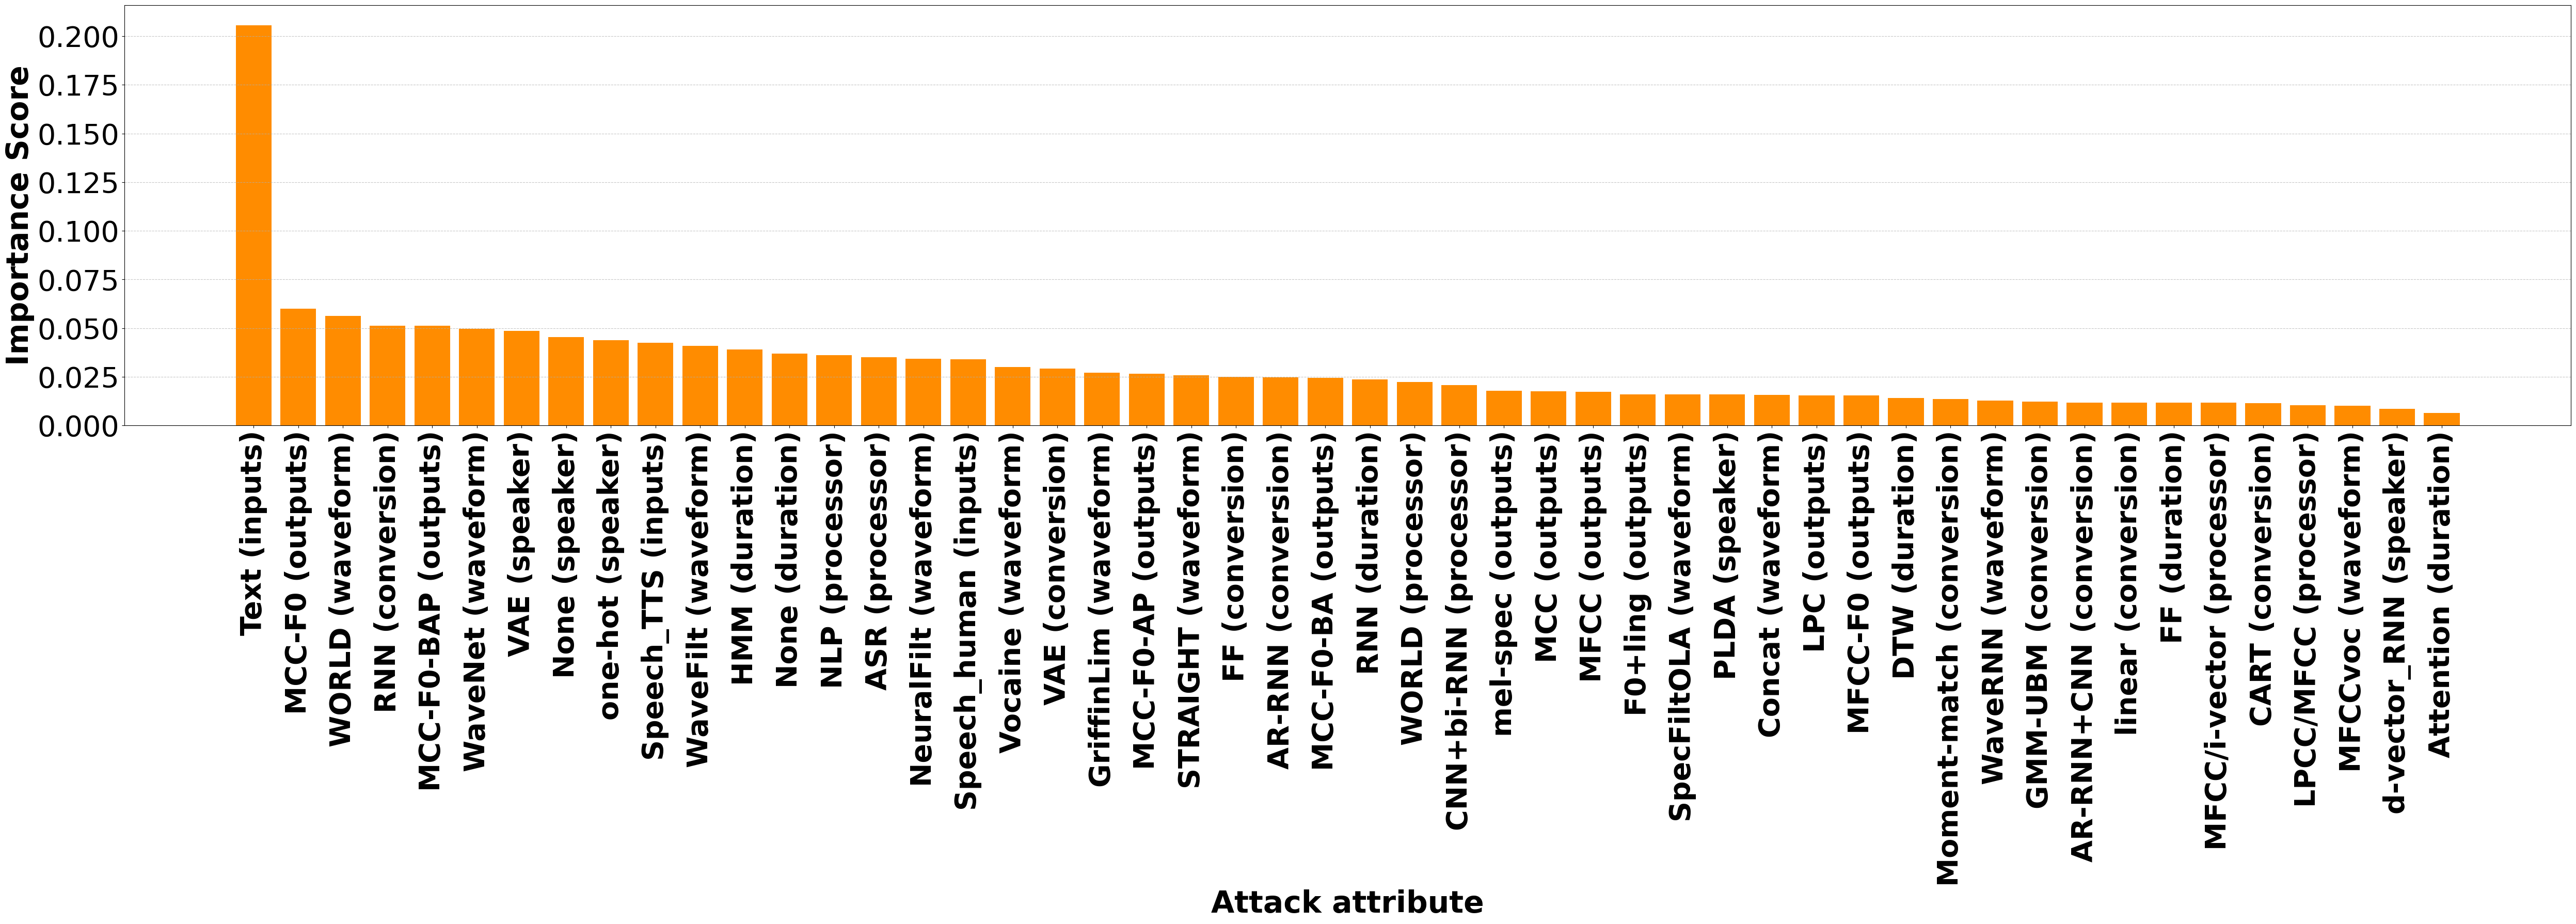

In [18]:
# Create a DataFrame for sorting
df = pd.DataFrame({'Feature': np.array(in_vars), 'Score': feature_scores})
df_sorted = df.sort_values(by='Score', ascending=False)

# Plot
plt.figure(figsize=(50, 18))
plt.bar(df_sorted['Feature'], df_sorted['Score'], color='darkorange')
plt.yticks(fontsize=40)
plt.xticks(rotation=90, fontsize=40, fontweight='bold')
plt.ylabel('Importance Score', fontsize=42, fontweight='bold')
plt.xlabel('Attack attribute', fontsize=42, fontweight='bold')
# plt.title('Feature Scores')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
kan_module.plot(beta=3, scale=3.0, varscale=0.2, in_vars=in_vars, out_vars=out_vars)

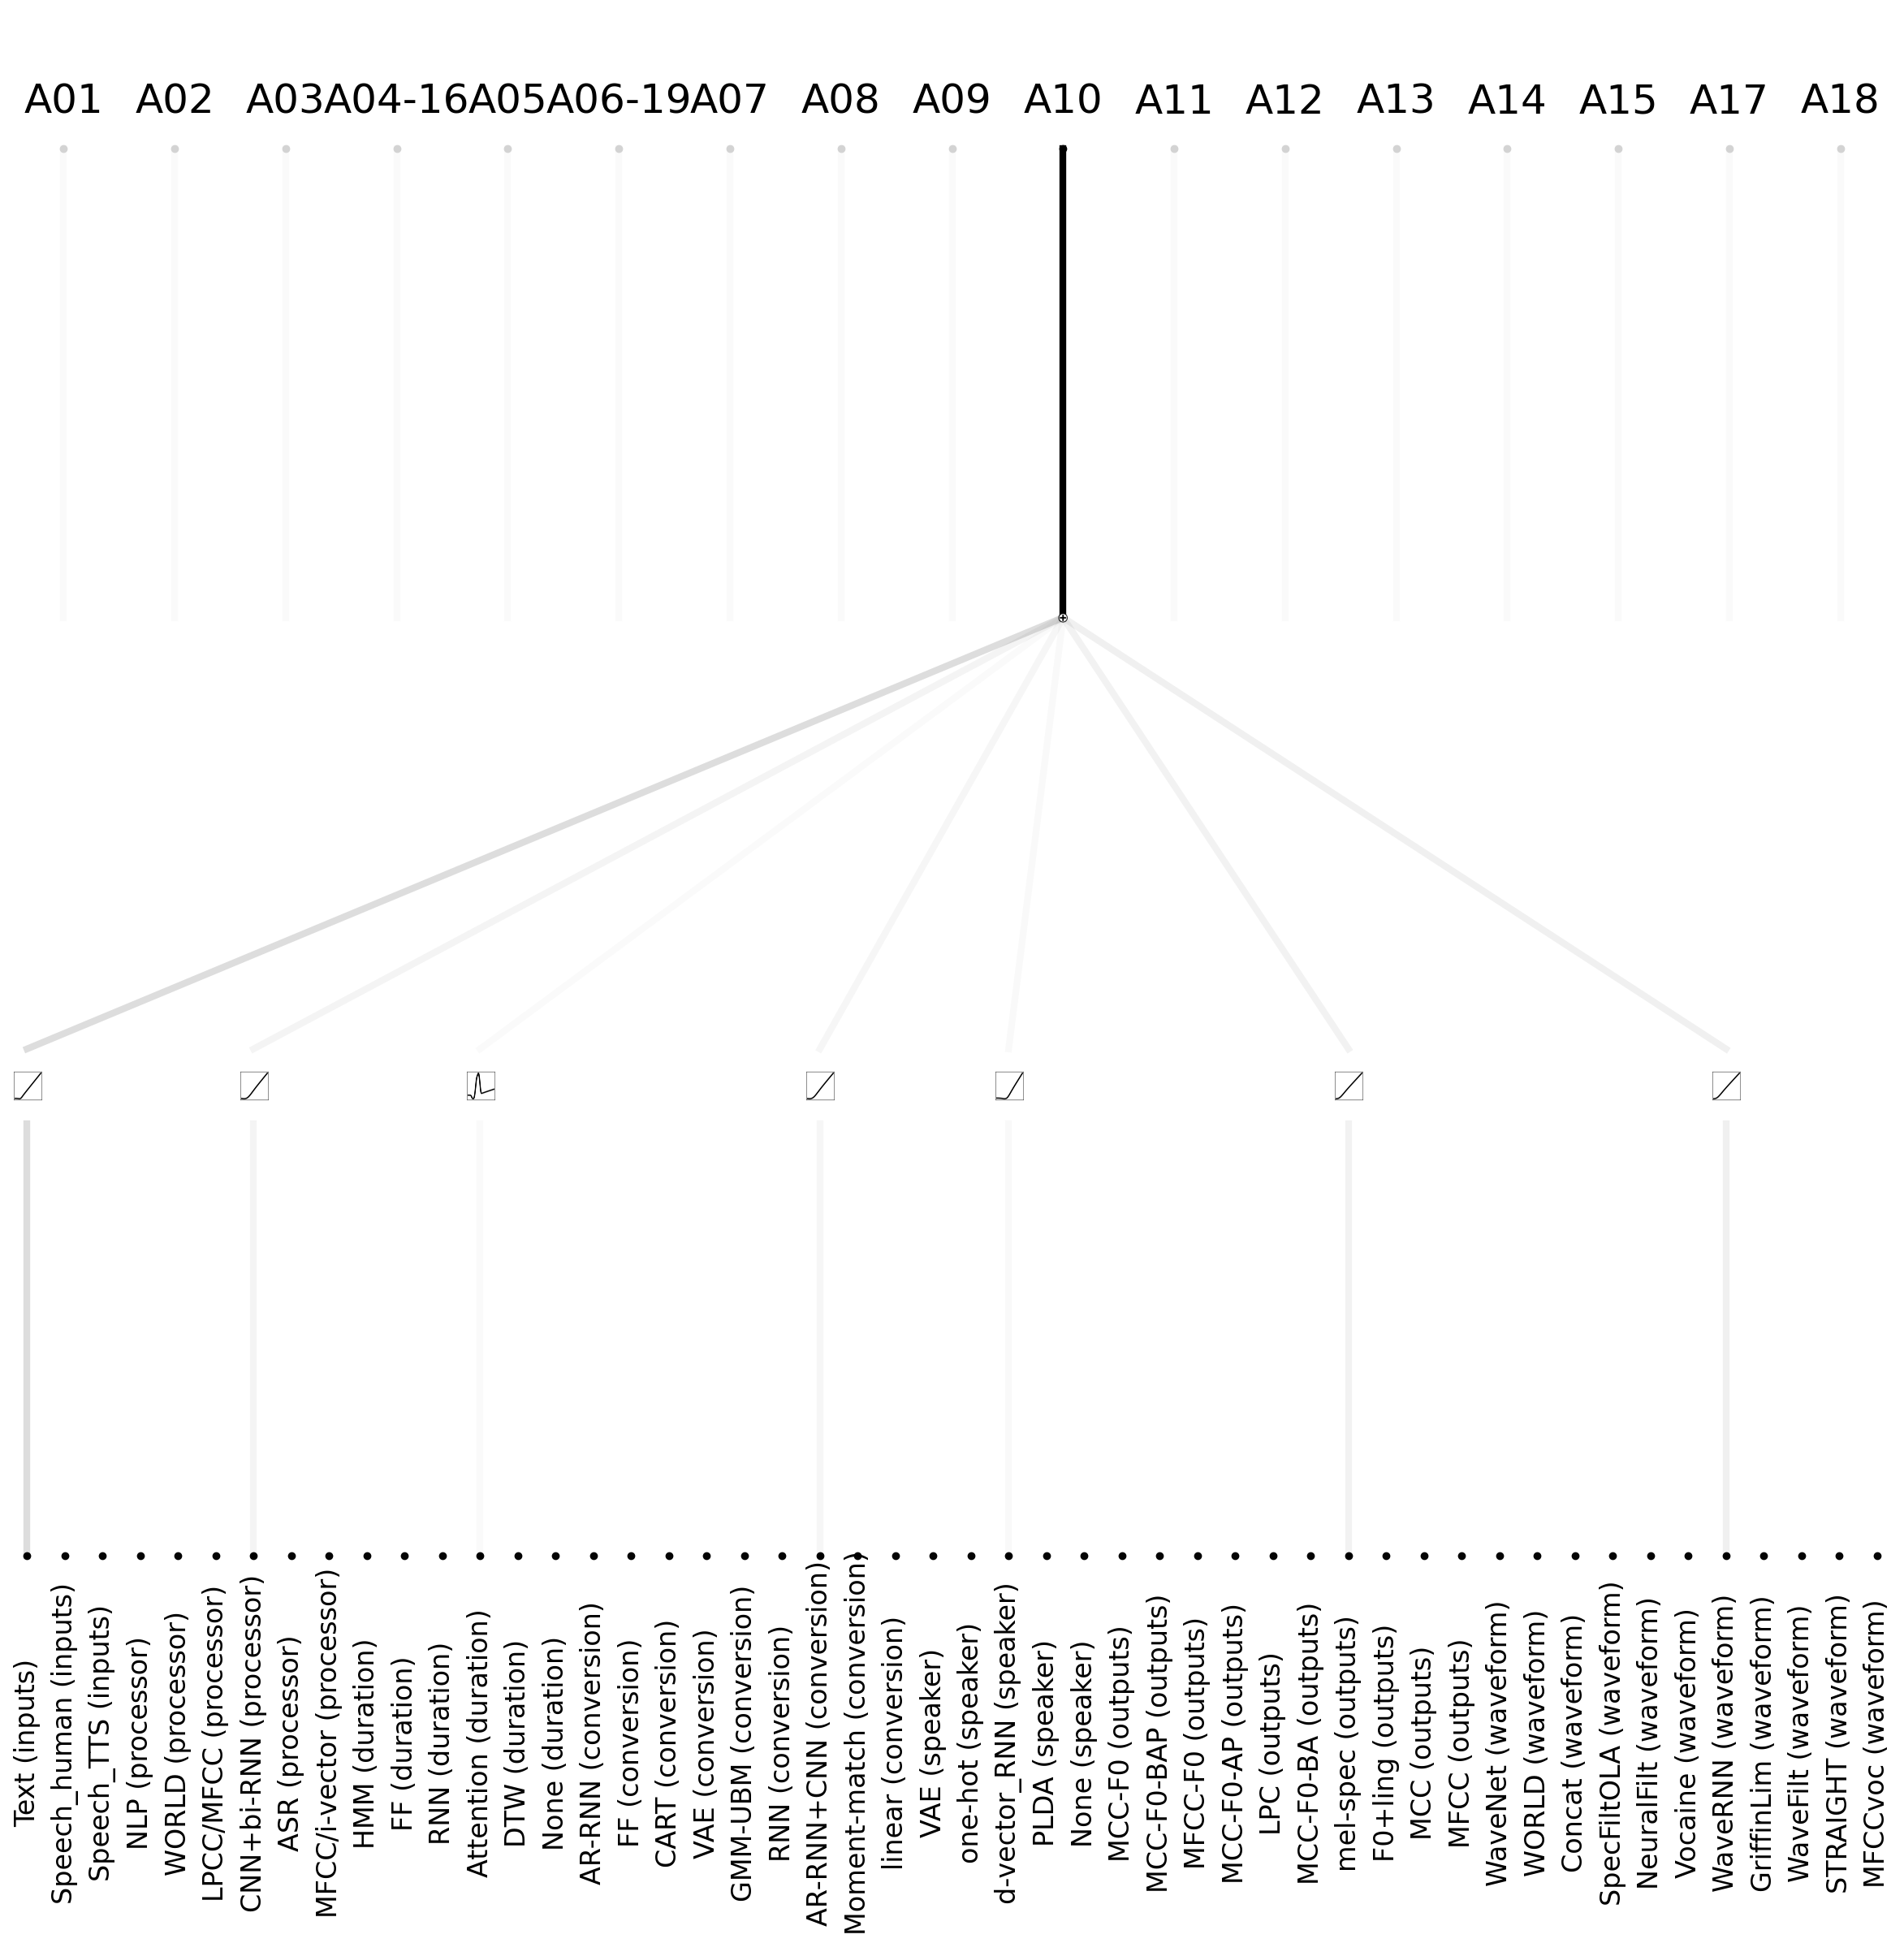

In [19]:
kan_module.plot2(beta=3, scale=3.0, varscale=0.2, in_vars=in_vars, out_vars=out_vars, target_output=9, spline_scale=1.0)

**Per-class level FI**

In [21]:
def plot_inFeature_importance(kan_model, outNode_id):
    scores = kan_model.attribute(1, outNode_id)

    # Create a DataFrame for sorting
    df = pd.DataFrame({'Feature': np.array(in_vars), 'Score': scores.detach().cpu().numpy()})
    df_sorted = df.sort_values(by='Score', ascending=False)
    
    # Plot
    plt.figure(figsize=(50, 18))
    
    plt.bar(df_sorted['Feature'], df_sorted['Score'])
    plt.yticks(fontsize=40)
    plt.xticks(rotation=90, fontsize=40, fontweight='bold')
    plt.ylabel('Importance Score', fontsize=42, fontweight='bold')
    plt.xlabel('Attack attribute', fontsize=42, fontweight='bold')
    plt.title(''.format(outNode_id+1))
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

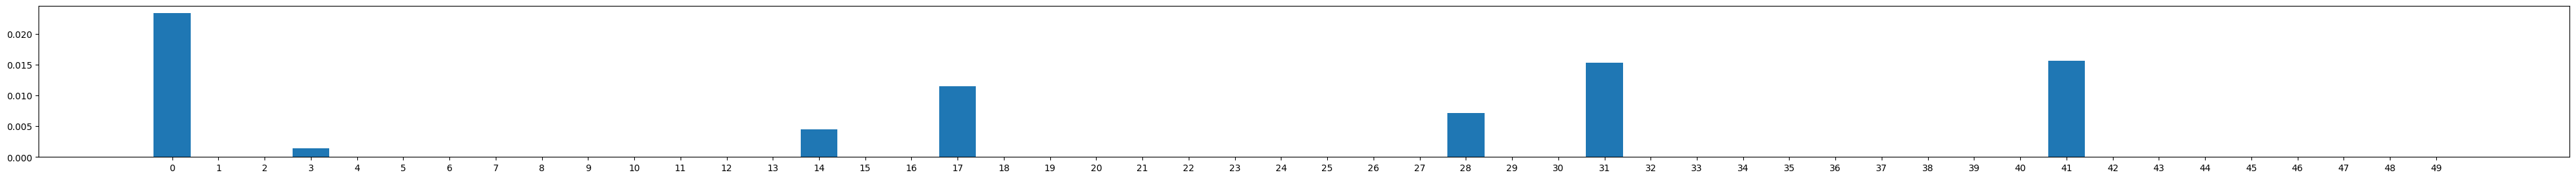

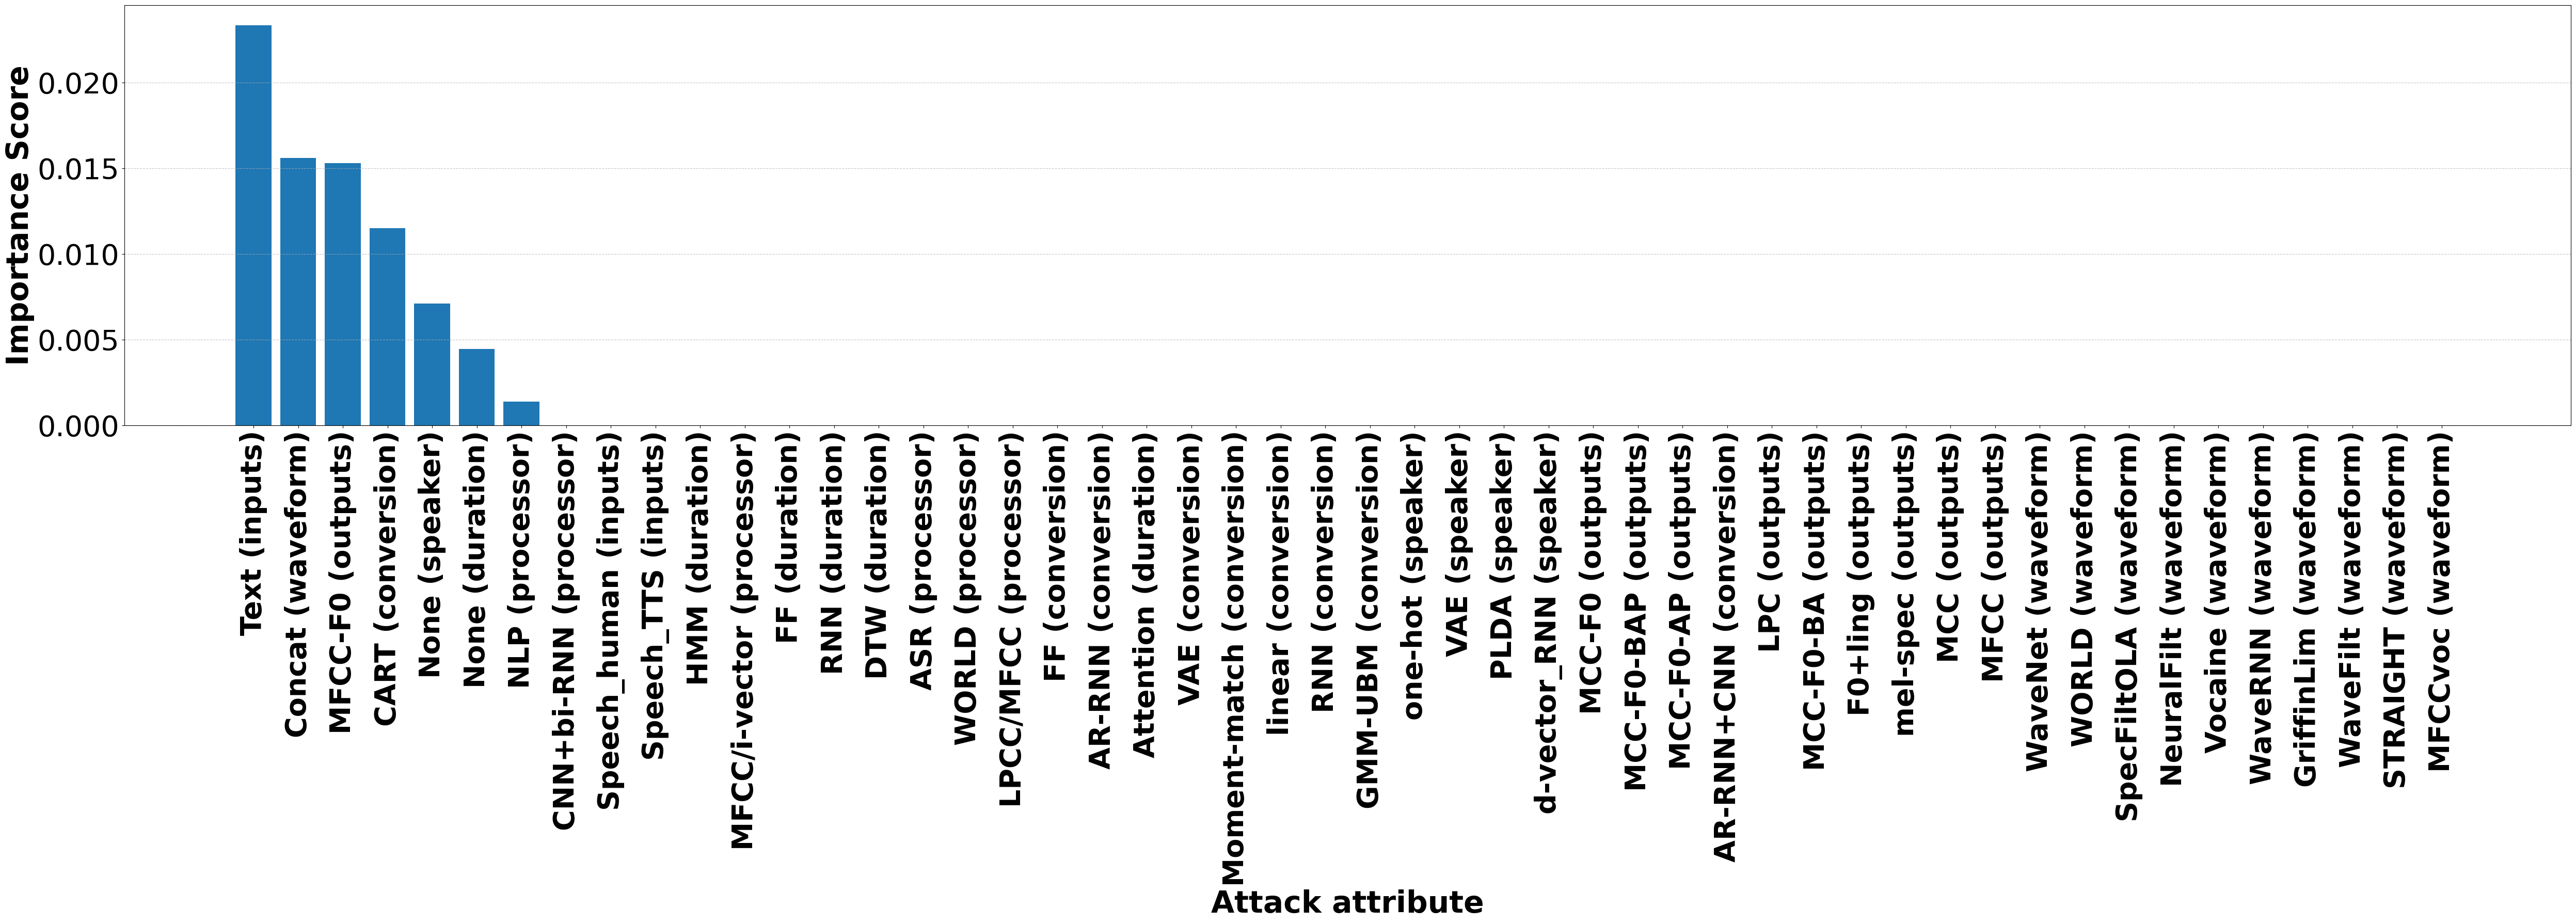

In [24]:
plot_inFeature_importance(kan_module, 3)

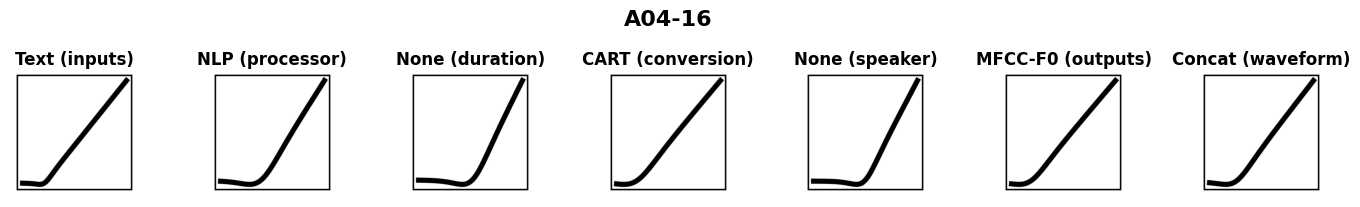

In [20]:
kan_module.plot_activation_grid(target_output=3, in_vars=in_vars, out_vars=out_vars)

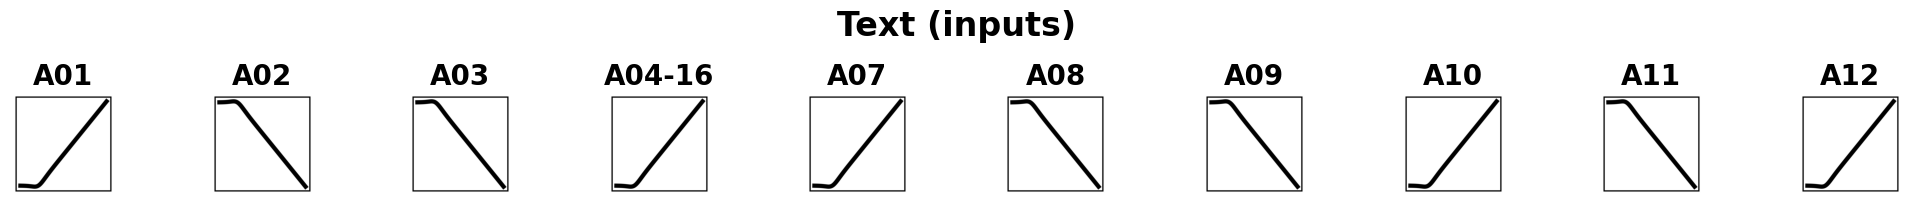

In [21]:
kan_module.plot_activation_grid_by_input(target_input=0, in_vars=in_vars, out_vars=out_vars)

# **Feature Importance (FI) evaluation**

## **Criteria 1: Consistency**

### **Scenario 1: Different model weights trained with different initialization seed**

In [1]:
%cd /scratch/project_2006687/hoangph/_thesis/ppm_v4/source_tracing

/scratch/project_2006687/hoangph/_thesis/ppm_v4/source_tracing


In [2]:
!ls

AttackAttr_embds  evaluate_deepfake_detection.py
AttackCls_embds   evaluate.py
backbones	  extracted_embds
config		  feature_extraction.py
core.1803143	  FI_utils.py
core.1804538	  get_shap_FIscores.py
core.1820090	  ID_OOD_distribution.png
core.1834255	  kan_figures
core.1834274	  kan_simplify
core.1842687	  logs
core.1853508	  model.py
core.1856550	  plots
core.1862306	  __pycache__
core.1862325	  RawBoost.py
core.1872401	  shap_values
core.1877436	  train.py
core.1878995	  train.sh
core.1886469	  TSNE_df_ID_OOD.png
core.1886491	  TSNE_features_visualization.py
data		  utils.py
data_utils.py	  weights


In [3]:
import os
import math
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.cm import ScalarMappable

from tqdm.auto import tqdm

import torch
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from data_utils import fetch_protocol, Dataset_ASVspoof2019_attr17, ASVSpoof2019_Attr17_attack_attribute_structure
from model import CMMTLKAN
from FI_utils import *

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import balanced_accuracy_score

from itertools import combinations

**Utils**

In [4]:
in_vars=["Text (inputs)", "Speech_human (inputs)", "Speech_TTS (inputs)",
         "NLP (processor)", "WORLD (processor)", "LPCC/MFCC (processor)", "CNN+bi-RNN (processor)", "ASR (processor)", "MFCC/i-vector (processor)",
         "HMM (duration)", "FF (duration)", "RNN (duration)", "Attention (duration)", "DTW (duration)", "None (duration)", 
         "AR-RNN (conversion)", "FF (conversion)", "CART (conversion)", "VAE (conversion)", "GMM-UBM (conversion)", "RNN (conversion)", "AR-RNN+CNN (conversion)", "Moment-match (conversion)", "linear (conversion)",
         "VAE (speaker)", "one-hot (speaker)", "d-vector_RNN (speaker)", "PLDA (speaker)", "None (speaker)", 
         "MCC-F0 (outputs)", "MCC-F0-BAP (outputs)", "MFCC-F0 (outputs)", "MCC-F0-AP (outputs)", "LPC (outputs)", "MCC-F0-BA (outputs)", "mel-spec (outputs)", "F0+ling (outputs)", "MCC (outputs)", "MFCC (outputs)",
         "WaveNet (waveform)", "WORLD (waveform)", "Concat (waveform)", "SpecFiltOLA (waveform)", "NeuralFilt (waveform)", "Vocaine (waveform)", "WaveRNN (waveform)", "GriffinLim (waveform)", "WaveFilt (waveform)", "STRAIGHT (waveform)", "MFCCvoc (waveform)"
        ]
out_vars=['A01', 'A02', 'A03', 'A04-16', 'A05', 'A06-19', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A17', 'A18']

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


**Evaluating**

In [47]:
embds_folder = "./extracted_embds"
exp_name = "ST_RB_AASIST_MTL_KANaux_trainingScratch_seed4321"
exp_folder = os.path.join(embds_folder, exp_name)

eval_attackAttr_embeddings_file = "ASVspoof2019_attr17_eval_attackAttr_embeddings.npy"

In [48]:
eval_attackAttr_embeddings_path = os.path.join(exp_folder, eval_attackAttr_embeddings_file)

In [49]:
eval_attackAttr_embeddings = np.load(eval_attackAttr_embeddings_path)
eval_attackAttr_embeddings.shape

(47880, 50)

In [50]:
eval_protocols_path = './data/ASVspoof2019_attr17_cm_protocols/Eval_ASVspoof19_attr17.txt'
eval_attack_labels = load_attack_labels(eval_protocols_path)

In [51]:
eval_dataset = AttClsDataset(eval_attackAttr_embeddings, eval_attack_labels)

In [52]:
eval_loader = DataLoader(eval_dataset,
                             batch_size=len(eval_dataset),
                             shuffle=False,
                             drop_last=False,
                             pin_memory=True,
                             collate_fn=None)
print("Number of batches in eval loader: ", len(eval_loader))

Number of batches in eval loader:  1


In [53]:
pretrained_path = "./weights/best_ST_RB_AASIST_MTL_KANaux_trainingScratch_seed4321.pt"
    
model = CMMTLKAN(
                backbone="AASIST",
                use_pretrained_backbone=False,
                freeze_backbone=False,
                device=device, 
                kan_auxiliary_structure=ASVSpoof2019_Attr17_attack_attribute_structure,
                seed=42
            ).to(device)
model.load_state_dict(torch.load(pretrained_path, map_location=device))
# model.kan_module.module_inFeatures(structure)

nb_params = sum([param.view(-1).size()[0] for param in model.parameters()])
print("no. model params:{}".format(nb_params))

Adding modular structure for KAN
no. model params:492444


In [54]:
kan_module = model.kan_module
# kan_module.module_inFeatures(structure)
kan_module.to(device)

MultKAN(
  (act_fun): ModuleList(
    (0): KANLayer(
      (base_fun): SiLU()
    )
  )
  (base_fun): SiLU()
)

In [55]:
eval_avg_acc, eval_avg_balanced_acc, attCls_cfsMatrix, attCls_clsReport = eval_AttackCls(eval_loader, kan_module, device)

  0%|          | 0/1 [00:00<?, ?it/s]

In [56]:
print("\nEvaluation Results:")
print("Average Accuracy:", eval_avg_acc)
print("Average Balanced Accuracy:", eval_avg_balanced_acc)
# print("\nAttack Classification Confusion Matrix:")
# plot_cfm(attCls_cfsMatrix, out_vars)
# print("\nAttack Classification Report:")
# print(attCls_clsReport)


Evaluation Results:
Average Accuracy: 0.9959482038429407
Average Balanced Accuracy: 0.9953409163437416


#### Whole model's FI

In [57]:
feature_scores = kan_module.feature_score.detach().cpu().numpy()
feature_scores

array([0.18253441, 0.04153369, 0.02895401, 0.03247824, 0.02847147,
       0.01343635, 0.01350343, 0.0407427 , 0.01244158, 0.02955857,
       0.01633012, 0.03647596, 0.01709592, 0.01185738, 0.02419281,
       0.03700736, 0.01689859, 0.01488475, 0.03286954, 0.01071379,
       0.04997308, 0.01546187, 0.01655702, 0.01415114, 0.04187078,
       0.05828444, 0.01412384, 0.0071792 , 0.03408142, 0.06831967,
       0.05539113, 0.01393391, 0.02365677, 0.01354242, 0.02458843,
       0.01348243, 0.0152939 , 0.01672952, 0.01271673, 0.0535581 ,
       0.06808367, 0.01376025, 0.01049767, 0.0293703 , 0.0284112 ,
       0.01535414, 0.02896049, 0.03127539, 0.02095802, 0.01044894],
      dtype=float32)

In [21]:
rank_FI_seed42= rank_feature_scores(feature_scores)
rank_FI_seed42

array([ 1, 17, 10, 14, 27, 47, 28, 15, 45, 12, 44, 26, 50, 38, 13, 24, 23,
       46, 19, 41,  4, 42, 39, 43,  7,  9, 49, 34,  8,  2,  5, 37, 21, 36,
       25, 29, 32, 30, 31,  6,  3, 35, 33, 16, 18, 40, 20, 11, 22, 48])

In [33]:
rank_FI_seed123= rank_feature_scores(feature_scores)
rank_FI_seed123

array([ 1, 17, 14, 11, 27, 47, 28, 15, 40, 13, 43, 21, 46, 34,  8, 19, 26,
       42, 18, 44,  5, 49, 39, 45,  7,  9, 48, 31, 10,  2,  4, 38, 23, 36,
       22, 32, 35, 29, 37,  6,  3, 33, 30, 16, 25, 41, 20, 12, 24, 50])

In [46]:
rank_FI_seed200= rank_feature_scores(feature_scores)
rank_FI_seed200

array([ 1,  9, 10, 15, 24, 42, 35, 18, 46, 22, 29, 14, 36, 45, 16, 19, 40,
       47, 13, 41,  5, 44, 39, 50,  2,  6, 48, 38, 17, 11,  3, 34, 20, 33,
       25, 23, 30, 28, 31,  8,  4, 37, 43, 12, 27, 49, 26,  7, 21, 32])

In [58]:
rank_FI_seed4321= rank_feature_scores(feature_scores)
rank_FI_seed4321

array([ 1,  9, 20, 15, 21, 43, 41, 10, 45, 17, 31, 12, 27, 46, 24, 11, 28,
       35, 14, 47,  7, 32, 30, 36,  8,  4, 37, 50, 13,  2,  5, 38, 25, 40,
       23, 42, 34, 29, 44,  6,  3, 39, 48, 18, 22, 33, 19, 16, 26, 49])

In [59]:
list_ranks = np.array([rank_FI_seed42, rank_FI_seed123, rank_FI_seed200, rank_FI_seed4321])
M = spearman_pairwise(list_ranks)
M

array([[1.        , 0.98060024, 0.89618247, 0.84086435],
       [0.98060024, 1.        , 0.89397359, 0.8495078 ],
       [0.89618247, 0.89397359, 1.        , 0.85373349],
       [0.84086435, 0.8495078 , 0.85373349, 1.        ]])

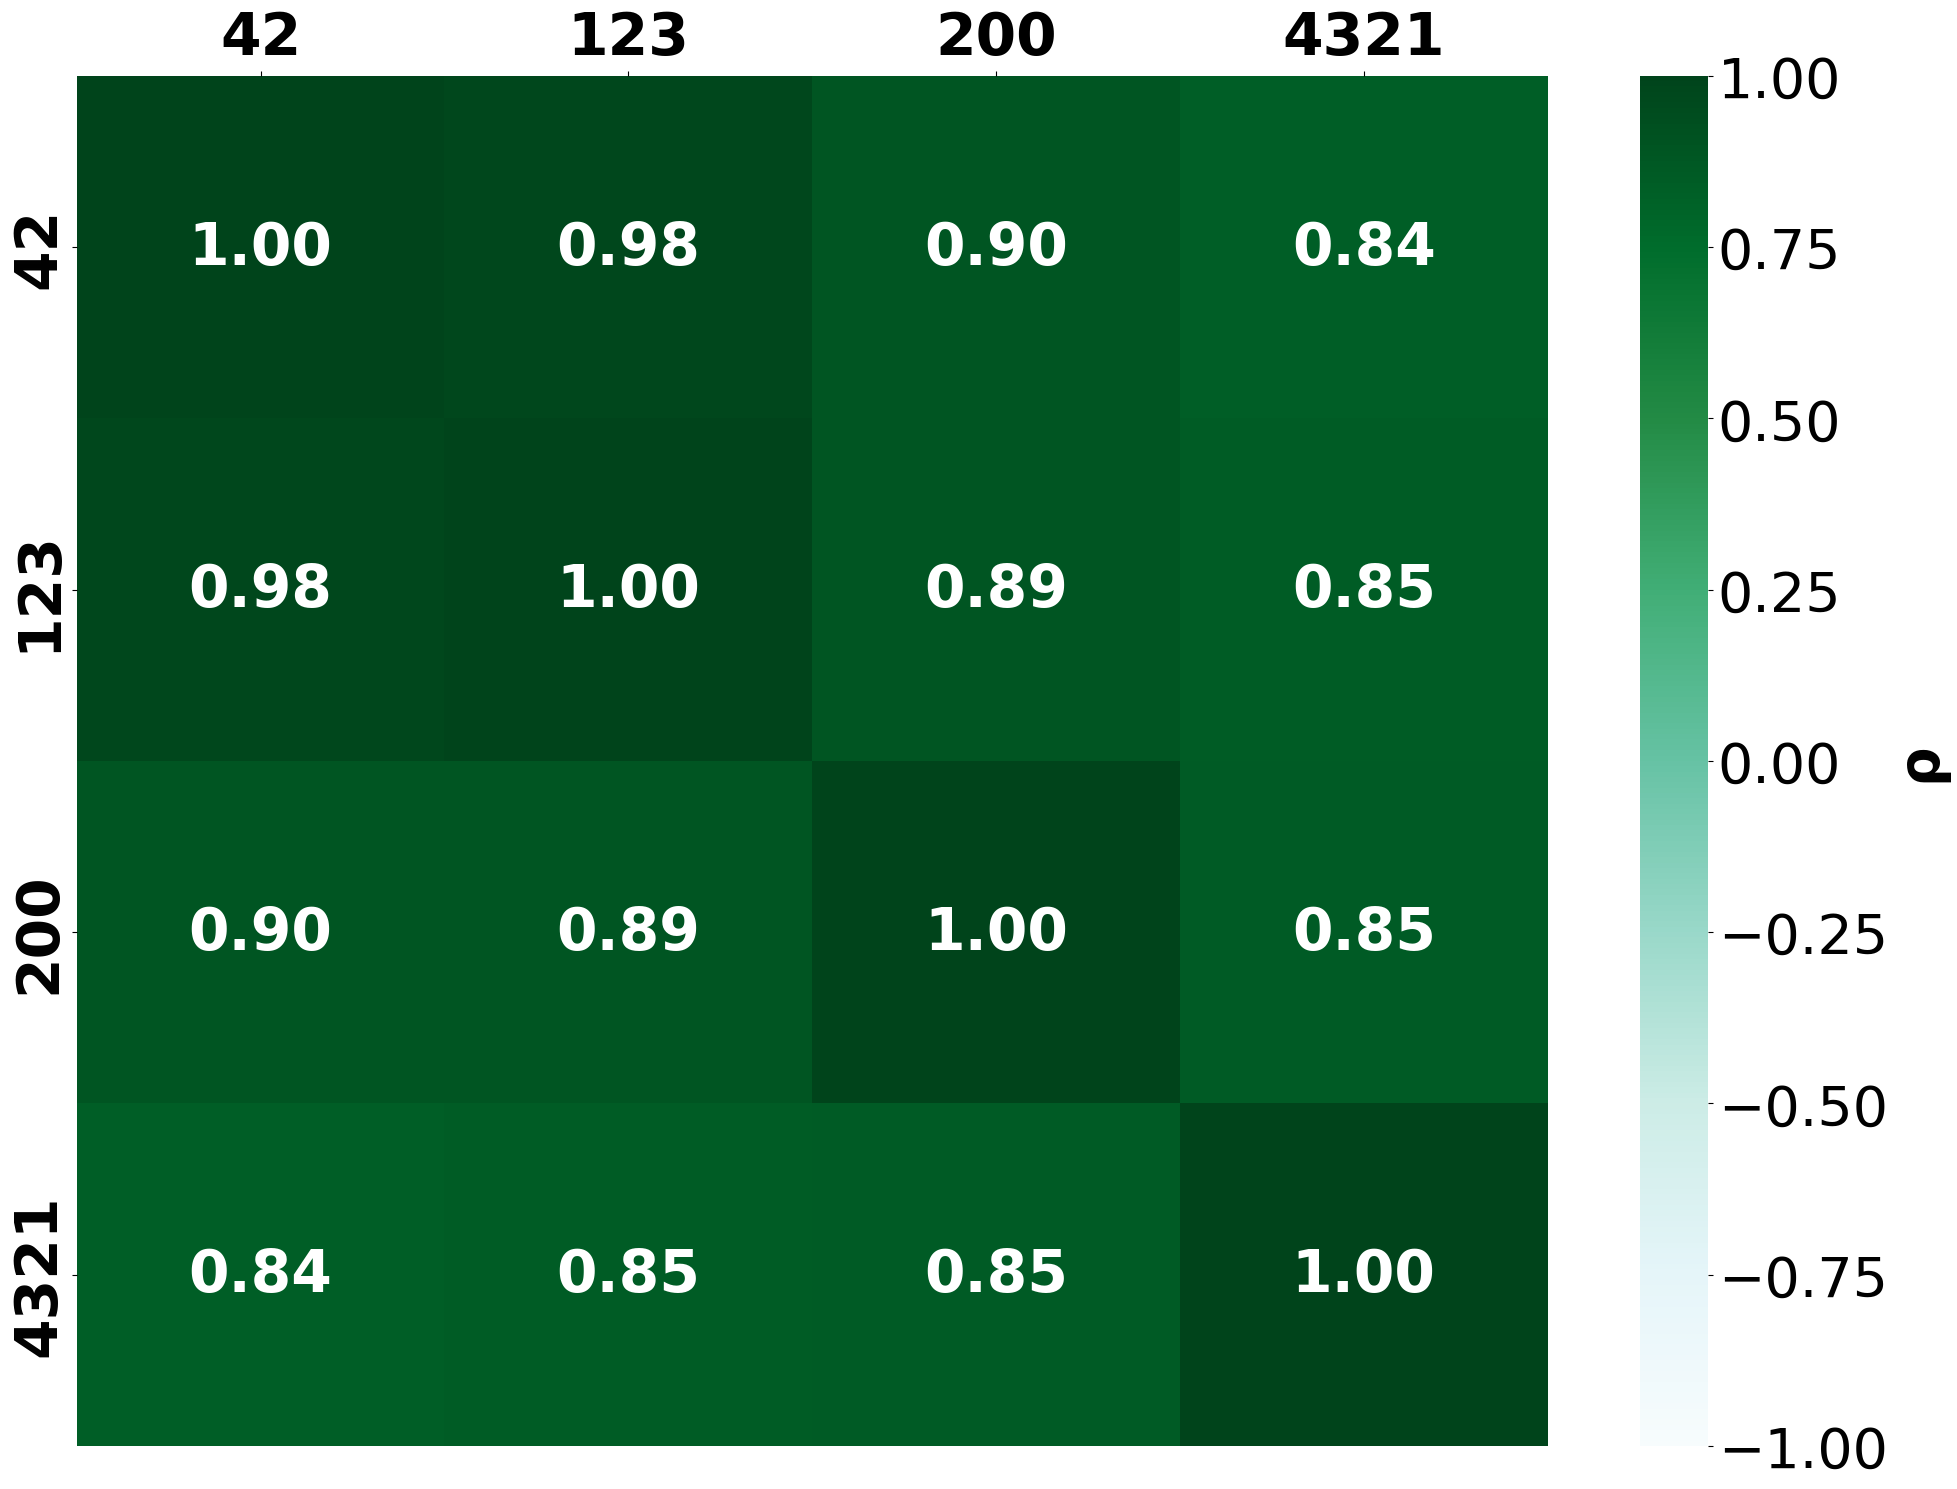

In [82]:
plot_corr_matrix(M, names=["42", "123", "200", "4321"], title="")

#### Per attack's FI

In [18]:
FI_perAtk_seed42 = get_FI_per_attack(kan_module)

In [29]:
FI_perAtk_seed123 = get_FI_per_attack(kan_module)

In [40]:
FI_perAtk_seed200 = get_FI_per_attack(kan_module)

In [51]:
FI_perAtk_seed4321 = get_FI_per_attack(kan_module)

In [52]:
list_runs = [FI_perAtk_seed42, FI_perAtk_seed123, FI_perAtk_seed200, FI_perAtk_seed4321]

In [53]:
list_M = []
for i in range(17):
    list_M.append(get_rank_perAtk_multi_runs(attack=i, list_runs=list_runs))
list_M = np.array(list_M)

In [54]:
list_M.shape

(17, 4, 4)

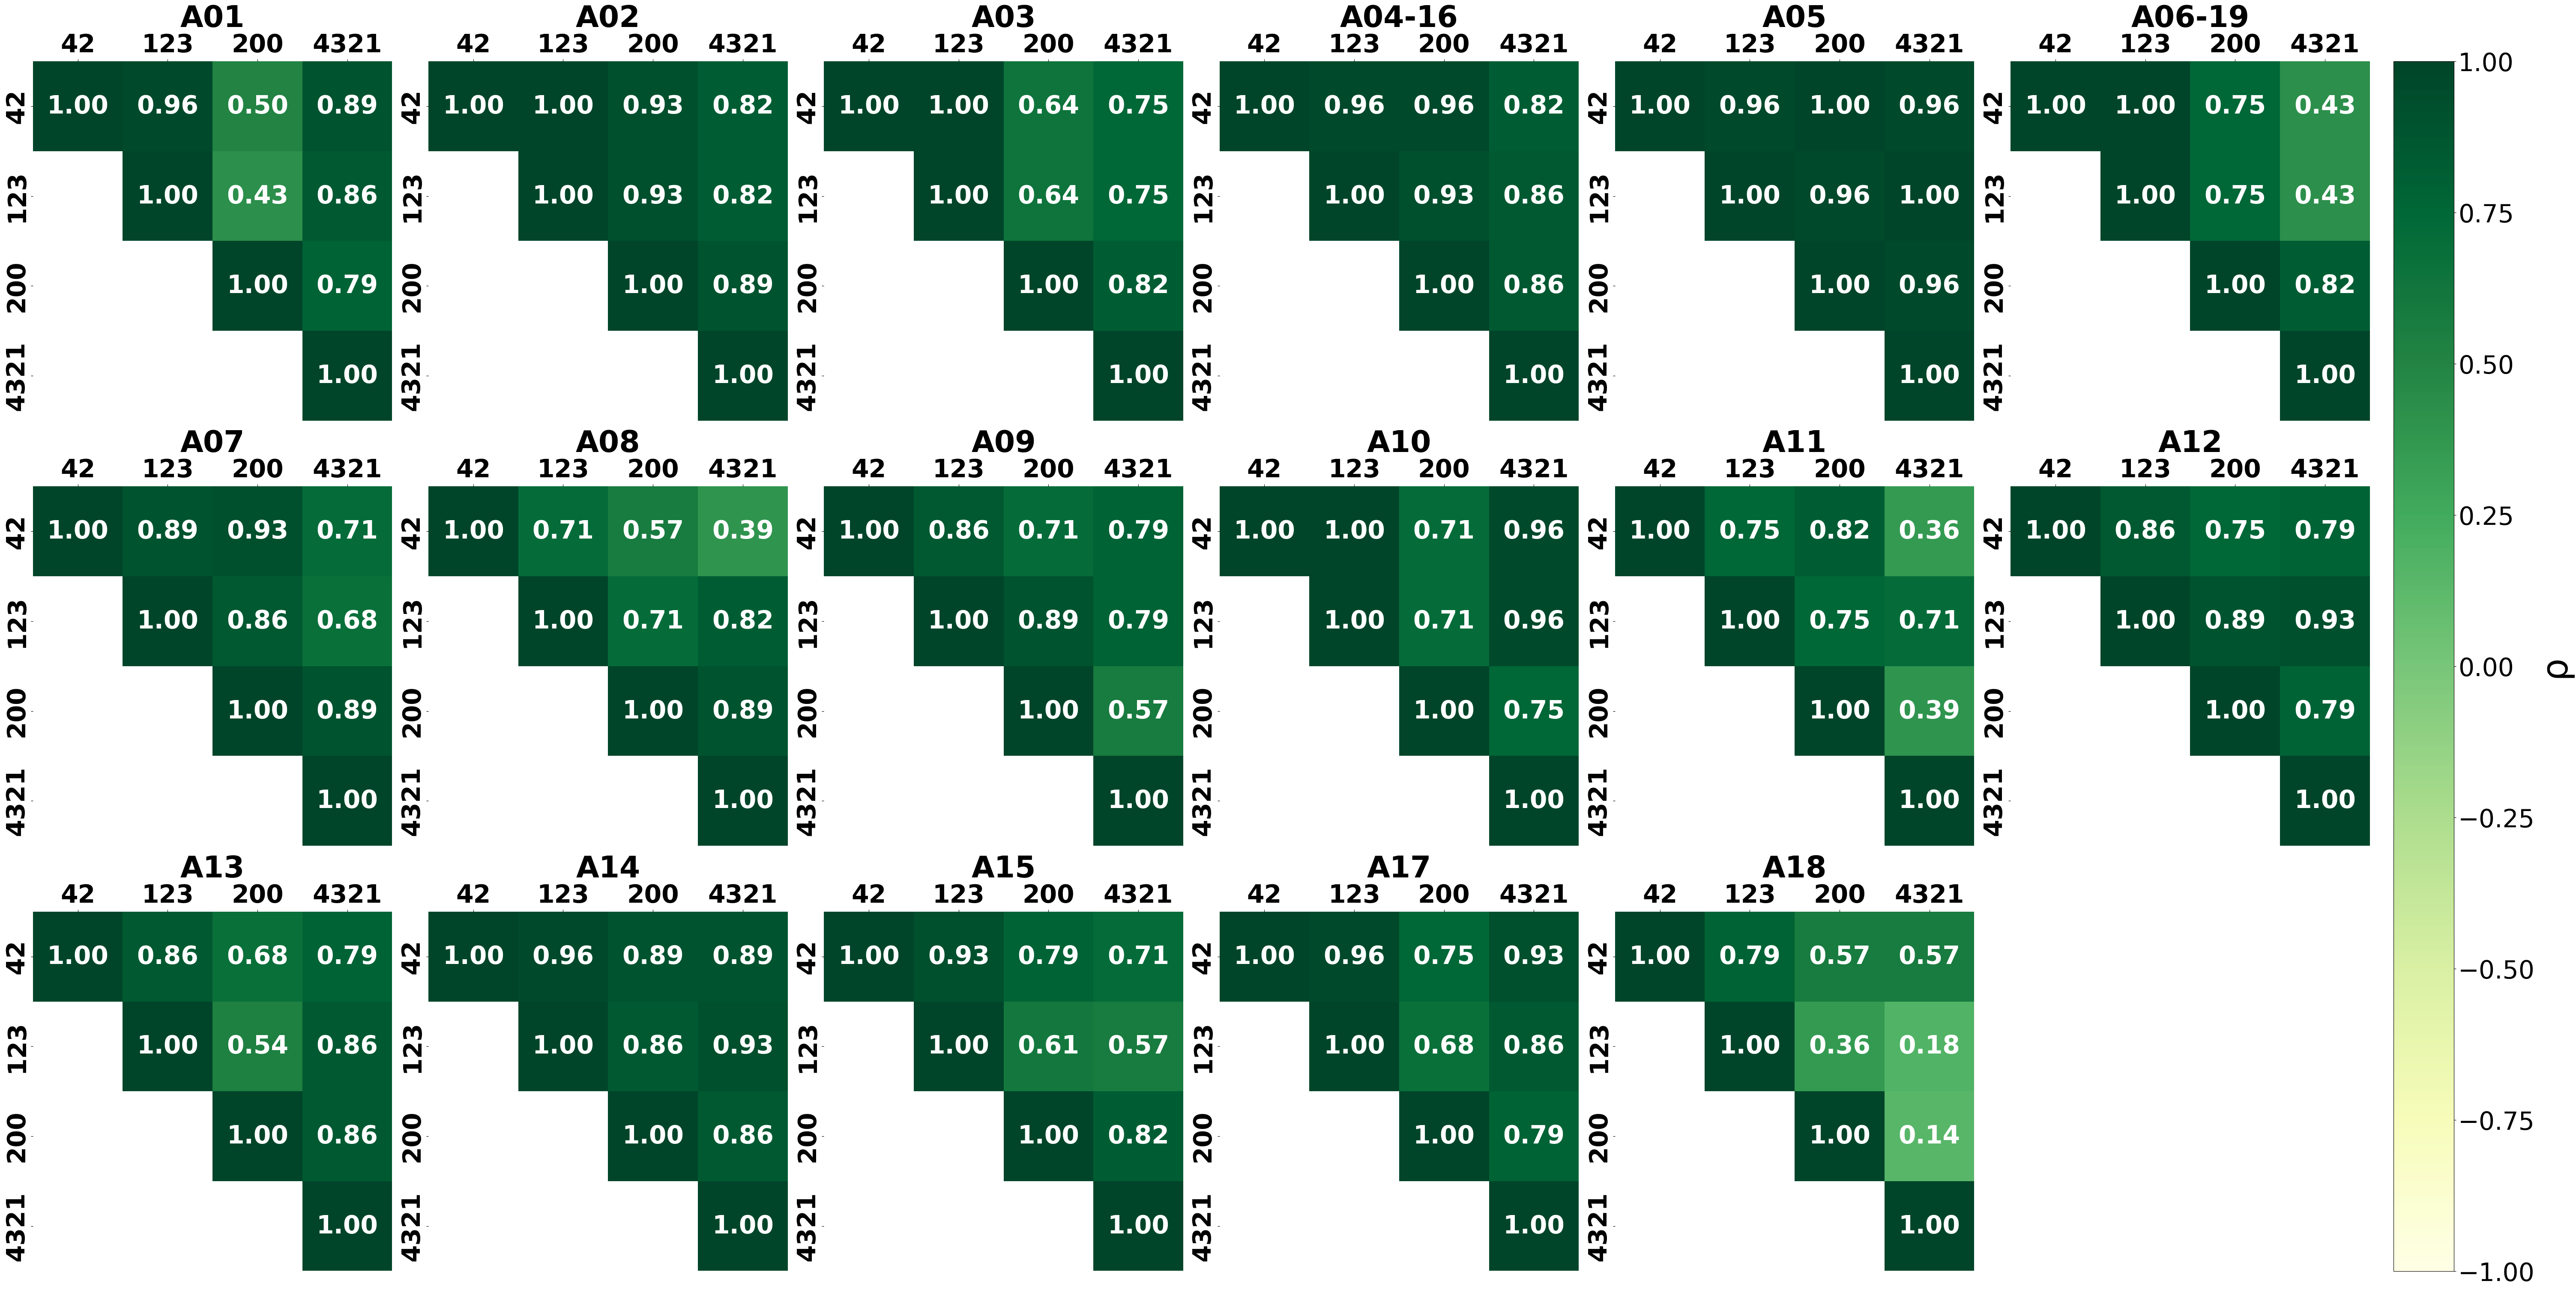

In [93]:
plot_corr_grid(list_M,
               titles=["A01", "A02", "A03", "A04-16", "A05", "A06-19", "A07", "A08", "A09", "A10", "A11", "A12", "A13", "A14", "A15", "A17", "A18"],
               names=["42", "123", "200", "4321"])

### **Scenario 2: Different model weights trained with different values of batch size**

In [1]:
%cd /scratch/project_2006687/hoangph/_thesis/ppm_v4/source_tracing

/scratch/project_2006687/hoangph/_thesis/ppm_v4/source_tracing


In [2]:
!ls

AttackAttr_embds  evaluate_deepfake_detection.py
AttackCls_embds   evaluate.py
backbones	  extracted_embds
config		  feature_extraction.py
core.1803143	  FI_utils.py
core.1804538	  get_shap_FIscores.py
core.1820090	  ID_OOD_distribution.png
core.1834255	  kan_figures
core.1834274	  kan_simplify
core.1842687	  logs
core.1853508	  model.py
core.1856550	  plots
core.1862306	  __pycache__
core.1862325	  RawBoost.py
core.1872401	  shap_values
core.1877436	  train.py
core.1878995	  train.sh
core.1886469	  TSNE_df_ID_OOD.png
core.1886491	  TSNE_features_visualization.py
data		  utils.py
data_utils.py	  weights


In [3]:
import os
import math
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.cm import ScalarMappable

from tqdm.auto import tqdm

import torch
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from data_utils import fetch_protocol, Dataset_ASVspoof2019_attr17, ASVSpoof2019_Attr17_attack_attribute_structure
from model import CMMTLKAN
from FI_utils import *

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import balanced_accuracy_score

from itertools import combinations

**Utils**

In [4]:
in_vars=["Text (inputs)", "Speech_human (inputs)", "Speech_TTS (inputs)",
         "NLP (processor)", "WORLD (processor)", "LPCC/MFCC (processor)", "CNN+bi-RNN (processor)", "ASR (processor)", "MFCC/i-vector (processor)",
         "HMM (duration)", "FF (duration)", "RNN (duration)", "Attention (duration)", "DTW (duration)", "None (duration)", 
         "AR-RNN (conversion)", "FF (conversion)", "CART (conversion)", "VAE (conversion)", "GMM-UBM (conversion)", "RNN (conversion)", "AR-RNN+CNN (conversion)", "Moment-match (conversion)", "linear (conversion)",
         "VAE (speaker)", "one-hot (speaker)", "d-vector_RNN (speaker)", "PLDA (speaker)", "None (speaker)", 
         "MCC-F0 (outputs)", "MCC-F0-BAP (outputs)", "MFCC-F0 (outputs)", "MCC-F0-AP (outputs)", "LPC (outputs)", "MCC-F0-BA (outputs)", "mel-spec (outputs)", "F0+ling (outputs)", "MCC (outputs)", "MFCC (outputs)",
         "WaveNet (waveform)", "WORLD (waveform)", "Concat (waveform)", "SpecFiltOLA (waveform)", "NeuralFilt (waveform)", "Vocaine (waveform)", "WaveRNN (waveform)", "GriffinLim (waveform)", "WaveFilt (waveform)", "STRAIGHT (waveform)", "MFCCvoc (waveform)"
        ]
out_vars=['A01', 'A02', 'A03', 'A04-16', 'A05', 'A06-19', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A17', 'A18']

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


**Evaluating**

In [66]:
embds_folder = "./extracted_embds"
exp_name = "ST_RB_AASIST_MTL_KANaux_trainingScratch_seed42_bs64"
exp_folder = os.path.join(embds_folder, exp_name)

eval_attackAttr_embeddings_file = "ASVspoof2019_attr17_eval_attackAttr_embeddings.npy"

In [67]:
eval_attackAttr_embeddings_path = os.path.join(exp_folder, eval_attackAttr_embeddings_file)

In [68]:
eval_attackAttr_embeddings = np.load(eval_attackAttr_embeddings_path)
eval_attackAttr_embeddings.shape

(47880, 50)

In [69]:
eval_protocols_path = './data/ASVspoof2019_attr17_cm_protocols/Eval_ASVspoof19_attr17.txt'
eval_attack_labels = load_attack_labels(eval_protocols_path)

In [70]:
eval_dataset = AttClsDataset(eval_attackAttr_embeddings, eval_attack_labels)

In [71]:
eval_loader = DataLoader(eval_dataset,
                             batch_size=len(eval_dataset),
                             shuffle=False,
                             drop_last=False,
                             pin_memory=True,
                             collate_fn=None)
print("Number of batches in eval loader: ", len(eval_loader))

Number of batches in eval loader:  1


In [72]:
pretrained_path = "./weights/best_ST_RB_AASIST_MTL_KANaux_trainingScratch_seed42_bs64.pt"
    
model = CMMTLKAN(
                backbone="AASIST",
                use_pretrained_backbone=False,
                freeze_backbone=False,
                device=device, 
                kan_auxiliary_structure=ASVSpoof2019_Attr17_attack_attribute_structure,
                seed=42
            ).to(device)
model.load_state_dict(torch.load(pretrained_path, map_location=device))
# model.kan_module.module_inFeatures(structure)

nb_params = sum([param.view(-1).size()[0] for param in model.parameters()])
print("no. model params:{}".format(nb_params))

Adding modular structure for KAN
no. model params:492444


In [73]:
kan_module = model.kan_module
# kan_module.module_inFeatures(structure)
kan_module.to(device)

MultKAN(
  (act_fun): ModuleList(
    (0): KANLayer(
      (base_fun): SiLU()
    )
  )
  (base_fun): SiLU()
)

In [74]:
eval_avg_acc, eval_avg_balanced_acc, attCls_cfsMatrix, attCls_clsReport = eval_AttackCls(eval_loader, kan_module, device)

  0%|          | 0/1 [00:00<?, ?it/s]

In [75]:
print("\nEvaluation Results:")
print("Average Accuracy:", eval_avg_acc)
print("Average Balanced Accuracy:", eval_avg_balanced_acc)
# print("\nAttack Classification Confusion Matrix:")
# plot_cfm(attCls_cfsMatrix, out_vars)
# print("\nAttack Classification Report:")
# print(attCls_clsReport)


Evaluation Results:
Average Accuracy: 0.995342522974102
Average Balanced Accuracy: 0.9947281396939731


#### Whole model's FI

In [40]:
feature_scores = kan_module.feature_score.detach().cpu().numpy()
feature_scores

array([0.23529978, 0.04155416, 0.0537554 , 0.04484247, 0.02923093,
       0.01160986, 0.02505994, 0.04010738, 0.0151801 , 0.04406211,
       0.01229886, 0.03452374, 0.01418981, 0.01839625, 0.03558631,
       0.0281763 , 0.02061979, 0.01037083, 0.02771552, 0.00982827,
       0.05406925, 0.01246074, 0.01134874, 0.01021362, 0.04829556,
       0.06097243, 0.0160869 , 0.02323977, 0.05632228, 0.06727294,
       0.04953805, 0.01413076, 0.01944949, 0.01640442, 0.01919111,
       0.01458014, 0.01416838, 0.01438359, 0.01456166, 0.04400059,
       0.05792749, 0.01465277, 0.01598229, 0.02247619, 0.01735082,
       0.01014906, 0.01947434, 0.03468499, 0.0198007 , 0.00794627],
      dtype=float32)

In [17]:
rank_FI_bs16= rank_feature_scores(feature_scores)
rank_FI_bs16

array([ 1, 17, 10, 14, 27, 47, 28, 15, 45, 12, 44, 26, 50, 38, 13, 24, 23,
       46, 19, 41,  4, 42, 39, 43,  7,  9, 49, 34,  8,  2,  5, 37, 21, 36,
       25, 29, 32, 30, 31,  6,  3, 35, 33, 16, 18, 40, 20, 11, 22, 48])

In [29]:
rank_FI_bs32= rank_feature_scores(feature_scores)
rank_FI_bs32

array([ 1, 15,  7, 10, 20, 41, 22, 12, 35, 14, 43, 19, 49, 29, 11, 21, 23,
       45, 18, 47,  4, 42, 40, 46,  8,  9, 50, 30, 13,  2,  5, 39, 25, 31,
       28, 36, 32, 33, 38,  6,  3, 34, 37, 17, 27, 44, 26, 16, 24, 48])

In [41]:
rank_FI_bs64 = rank_feature_scores(feature_scores)
rank_FI_bs64

array([ 1, 13,  7, 10, 18, 44, 21, 14, 34, 11, 43, 17, 39, 29, 15, 19, 24,
       46, 20, 49,  6, 42, 45, 47,  9,  3, 32, 22,  5,  2,  8, 41, 27, 31,
       28, 36, 40, 38, 37, 12,  4, 35, 33, 23, 30, 48, 26, 16, 25, 50])

In [42]:
list_ranks = np.array([rank_FI_bs16, rank_FI_bs32, rank_FI_bs64])
M = spearman_pairwise(list_ranks)
M

array([[1.        , 0.95966387, 0.90895558],
       [0.95966387, 1.        , 0.95620648],
       [0.90895558, 0.95620648, 1.        ]])

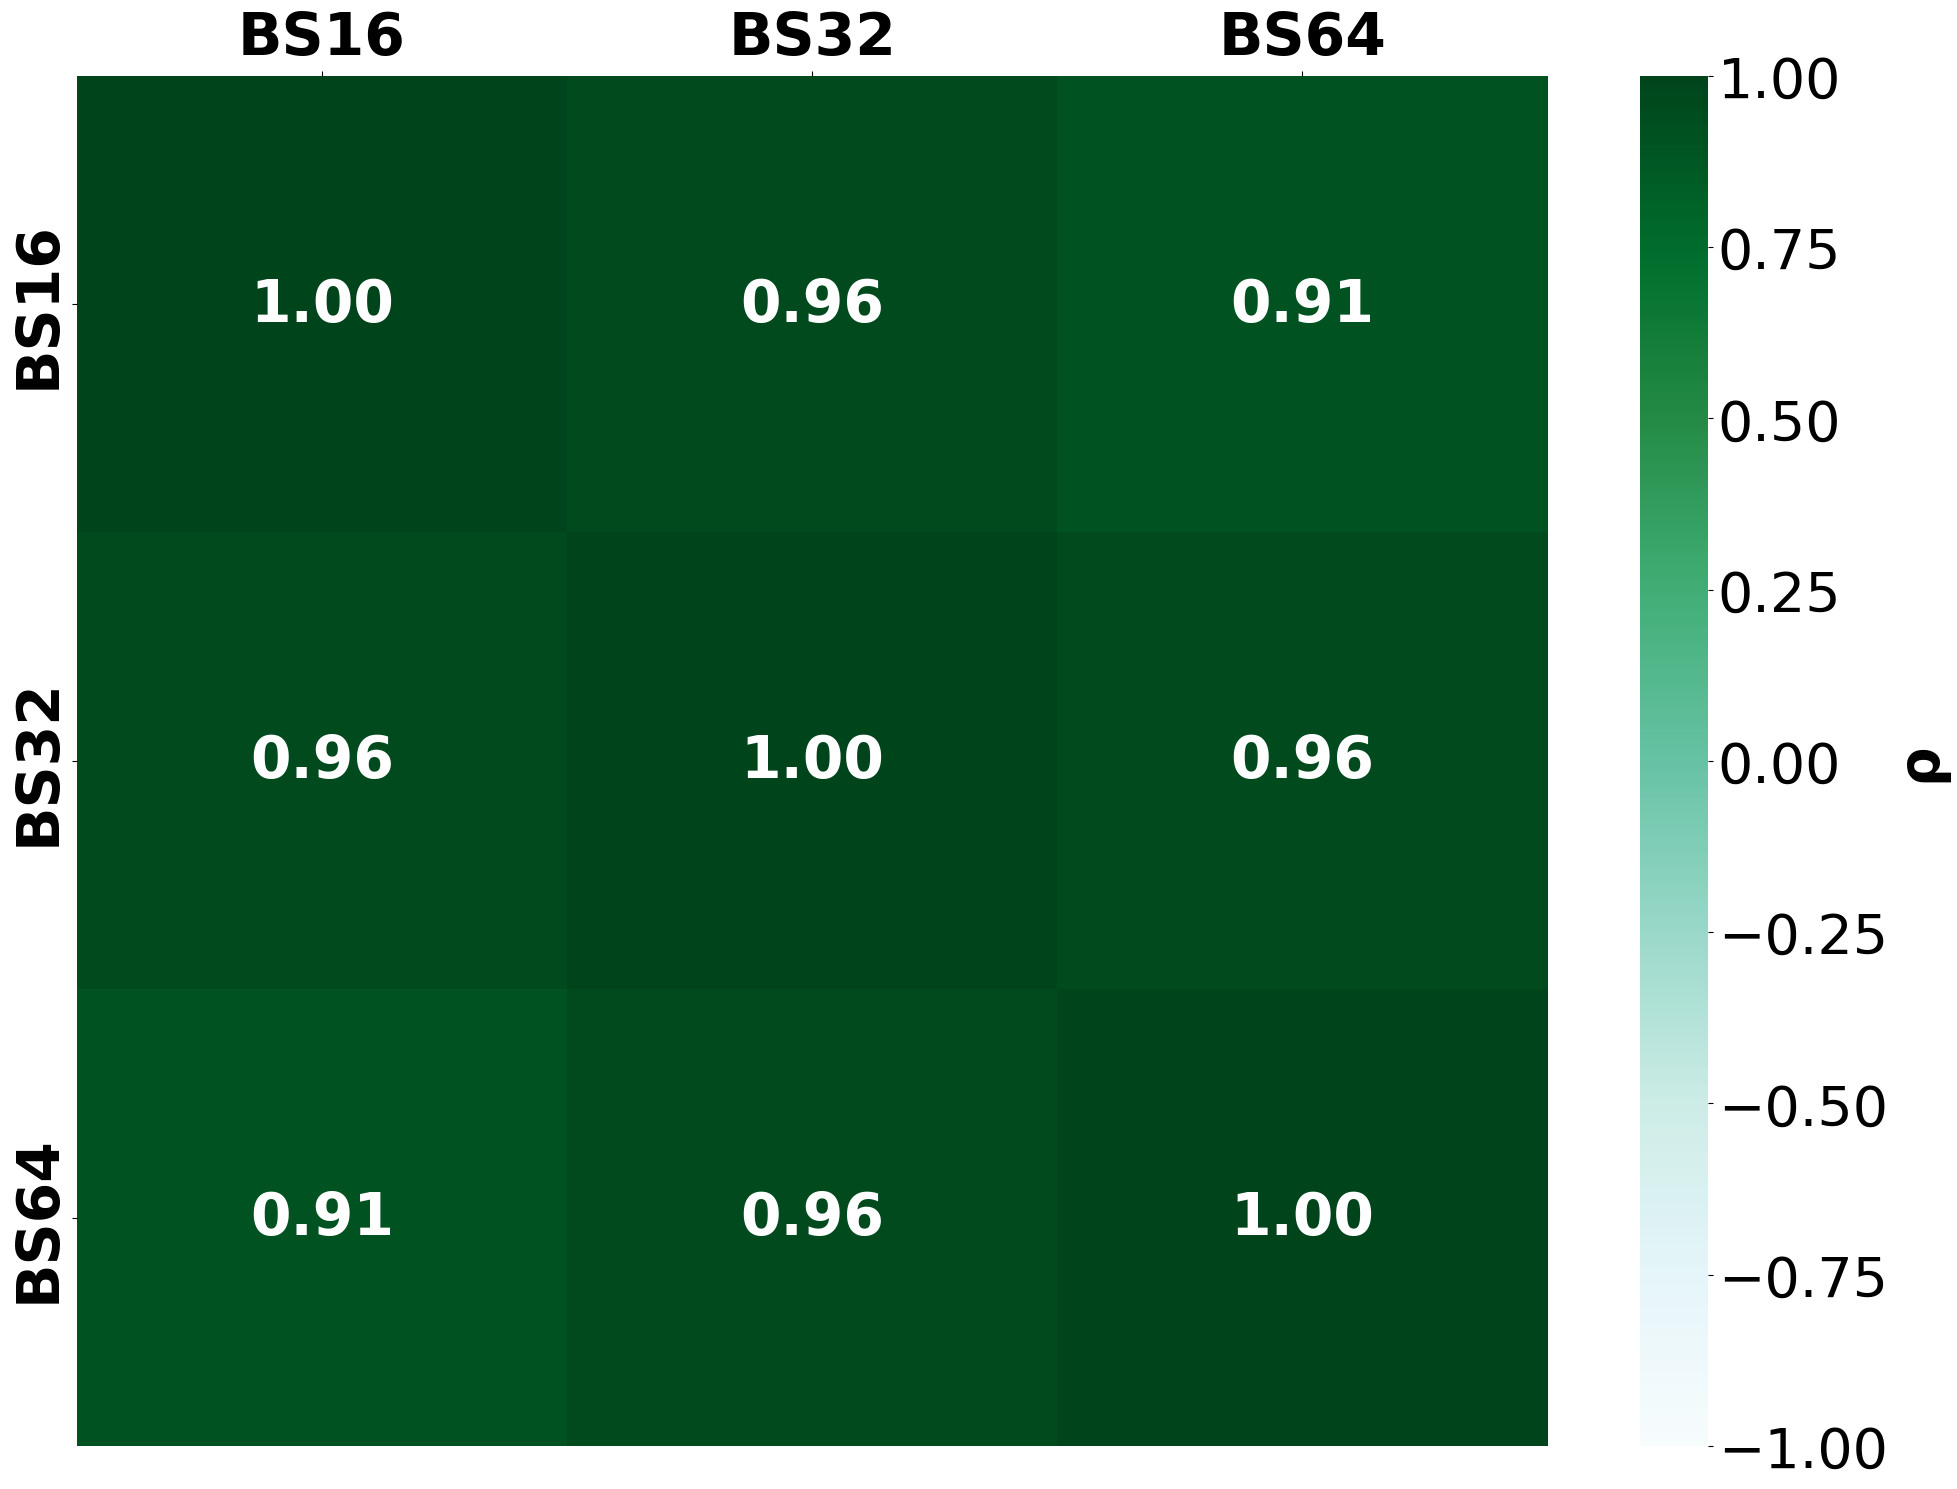

In [43]:
plot_corr_matrix(M, names=["BS16", "BS32", "BS64"], title="")

#### Per attack's FI

In [54]:
FI_perAtk_bs16 = get_FI_per_attack(kan_module)

In [65]:
FI_perAtk_bs32 = get_FI_per_attack(kan_module)

In [76]:
FI_perAtk_bs64 = get_FI_per_attack(kan_module)

In [77]:
list_runs = [FI_perAtk_bs16, FI_perAtk_bs32, FI_perAtk_bs64]

In [78]:
list_M = []
for i in range(17):
    list_M.append(get_rank_perAtk_multi_runs(attack=i, list_runs=list_runs))
list_M = np.array(list_M)

In [79]:
list_M.shape

(17, 3, 3)

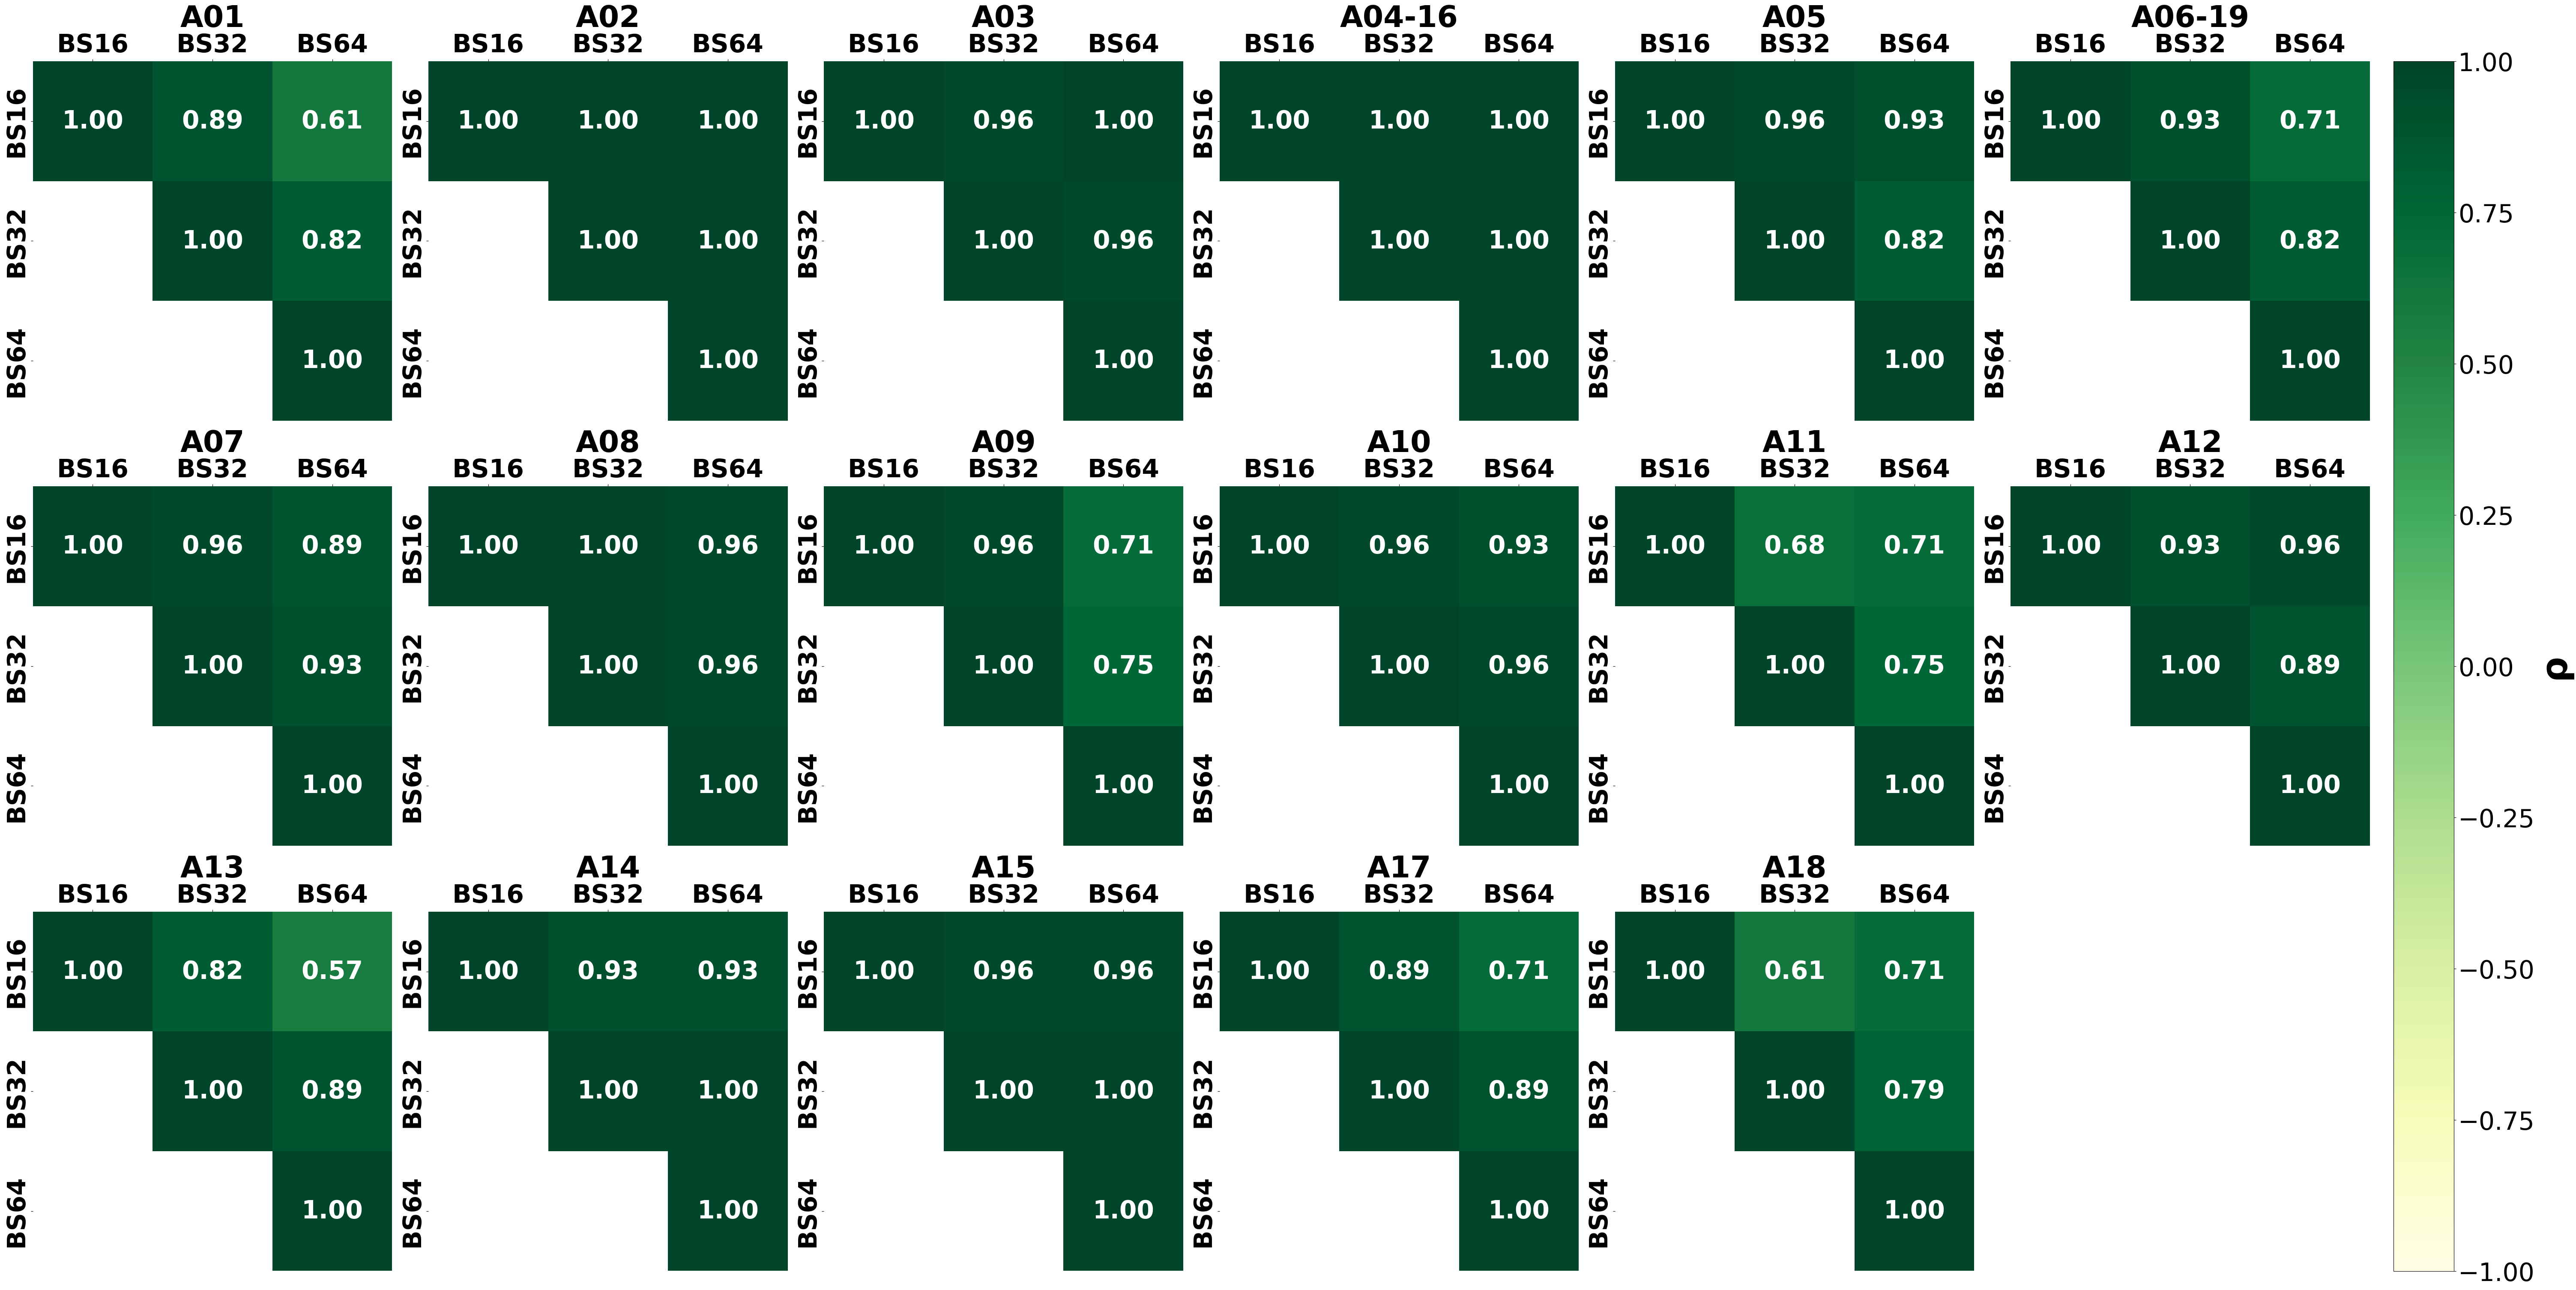

In [81]:
plot_corr_grid(list_M,
               titles=["A01", "A02", "A03", "A04-16", "A05", "A06-19", "A07", "A08", "A09", "A10", "A11", "A12", "A13", "A14", "A15", "A17", "A18"],
               names=["BS16", "BS32", "BS64"])

### **Scenario 3: Different model weights trained with different architecture and training scenario**

In [1]:
%cd /scratch/project_2006687/hoangph/_thesis/ppm_v4/source_tracing

/scratch/project_2006687/hoangph/_thesis/ppm_v4/source_tracing


/scratch/project_2006687/hoangph/.venv39_2/lib/python3.9/site-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
!ls

AttackAttr_embds  evaluate_deepfake_detection.py
AttackCls_embds   evaluate.py
backbones	  extracted_embds
config		  feature_extraction.py
core.1803143	  FI_utils.py
core.1804538	  get_shap_FIscores.py
core.1820090	  ID_OOD_distribution.png
core.1834255	  kan_figures
core.1834274	  kan_simplify
core.1842687	  logs
core.1853508	  model.py
core.1856550	  plots
core.1862306	  __pycache__
core.1862325	  RawBoost.py
core.1872401	  shap_values
core.1877436	  train.py
core.1878995	  train.sh
core.1886469	  TSNE_df_ID_OOD.png
core.1886491	  TSNE_features_visualization.py
core.2212903	  utils.py
data		  weights
data_utils.py


In [3]:
import os
import math
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from data_utils import fetch_protocol, Dataset_ASVspoof2019_attr17, ASVSpoof2019_Attr17_attack_attribute_structure
from model import CMMTLKAN
from FI_utils import *


/scratch/project_2006687/hoangph/.venv39_2/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


**Utils**

In [4]:
!which python

/CSC_CONTAINER/miniconda/envs/env1/bin/python


In [5]:
import sys
{sys.executable}

{'/scratch/project_2006687/hoangph/.venv39_2/bin/python'}

In [4]:
in_vars=["Text (inputs)", "Speech_human (inputs)", "Speech_TTS (inputs)",
         "NLP (processor)", "WORLD (processor)", "LPCC/MFCC (processor)", "CNN+bi-RNN (processor)", "ASR (processor)", "MFCC/i-vector (processor)",
         "HMM (duration)", "FF (duration)", "RNN (duration)", "Attention (duration)", "DTW (duration)", "None (duration)", 
         "AR-RNN (conversion)", "FF (conversion)", "CART (conversion)", "VAE (conversion)", "GMM-UBM (conversion)", "RNN (conversion)", "AR-RNN+CNN (conversion)", "Moment-match (conversion)", "linear (conversion)",
         "VAE (speaker)", "one-hot (speaker)", "d-vector_RNN (speaker)", "PLDA (speaker)", "None (speaker)", 
         "MCC-F0 (outputs)", "MCC-F0-BAP (outputs)", "MFCC-F0 (outputs)", "MCC-F0-AP (outputs)", "LPC (outputs)", "MCC-F0-BA (outputs)", "mel-spec (outputs)", "F0+ling (outputs)", "MCC (outputs)", "MFCC (outputs)",
         "WaveNet (waveform)", "WORLD (waveform)", "Concat (waveform)", "SpecFiltOLA (waveform)", "NeuralFilt (waveform)", "Vocaine (waveform)", "WaveRNN (waveform)", "GriffinLim (waveform)", "WaveFilt (waveform)", "STRAIGHT (waveform)", "MFCCvoc (waveform)"
        ]
out_vars=['A01', 'A02', 'A03', 'A04-16', 'A05', 'A06-19', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A17', 'A18']

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


**Evaluating**

In [50]:
embds_folder = "./extracted_embds"
exp_name = "ST_RB_SSLAASIST_MTL_KANaux_partialFinetuning"
exp_folder = os.path.join(embds_folder, exp_name)

eval_attackAttr_embeddings_file = "ASVspoof2019_attr17_eval_attackAttr_embeddings.npy"

In [51]:
eval_attackAttr_embeddings_path = os.path.join(exp_folder, eval_attackAttr_embeddings_file)

In [52]:
eval_attackAttr_embeddings = np.load(eval_attackAttr_embeddings_path)
eval_attackAttr_embeddings.shape

(47880, 50)

In [53]:
eval_protocols_path = './data/ASVspoof2019_attr17_cm_protocols/Eval_ASVspoof19_attr17.txt'
eval_attack_labels = load_attack_labels(eval_protocols_path)

In [54]:
eval_dataset = AttClsDataset(eval_attackAttr_embeddings, eval_attack_labels)

In [55]:
eval_loader = DataLoader(eval_dataset,
                             batch_size=len(eval_dataset),
                             shuffle=False,
                             drop_last=False,
                             pin_memory=True,
                             collate_fn=None)
print("Number of batches in eval loader: ", len(eval_loader))

Number of batches in eval loader:  1


In [56]:
pretrained_path = "./weights/best_ST_RB_SSLAASIST_MTL_KANaux_partialFinetuning.pt"
    
model = CMMTLKAN(
                backbone="SSLAASIST",
                use_pretrained_backbone=False,
                freeze_backbone=False,
                device=device, 
                kan_auxiliary_structure=ASVSpoof2019_Attr17_attack_attribute_structure,
                seed=42
            ).to(device)
model.load_state_dict(torch.load(pretrained_path, map_location=device))
# model.kan_module.module_inFeatures(structure)

nb_params = sum([param.view(-1).size()[0] for param in model.parameters()])
print("no. model params:{}".format(nb_params))

/scratch/project_2006687/hoangph/.venv39_2/lib/python3.9/site-packages/torch/nn/utils/weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)


Adding modular structure for KAN
no. model params:318032412


In [57]:
kan_module = model.kan_module
# kan_module.module_inFeatures(structure)
kan_module.to(device)

MultKAN(
  (act_fun): ModuleList(
    (0): KANLayer(
      (base_fun): SiLU()
    )
  )
  (base_fun): SiLU()
)

In [58]:
eval_avg_acc, eval_avg_balanced_acc, attCls_cfsMatrix, attCls_clsReport = eval_AttackCls(eval_loader, kan_module, device)

100%|██████████| 1/1 [00:00<00:00,  1.12it/s]


In [59]:
print("\nEvaluation Results:")
print("Average Accuracy:", eval_avg_acc)
print("Average Balanced Accuracy:", eval_avg_balanced_acc)
# print("\nAttack Classification Confusion Matrix:")
# plot_cfm(attCls_cfsMatrix, out_vars)
# print("\nAttack Classification Report:")
# print(attCls_clsReport)


Evaluation Results:
Average Accuracy: 0.6480367585630743
Average Balanced Accuracy: 0.6170888718050037


#### Whole model's FI

In [69]:
feature_scores = kan_module.feature_score.detach().cpu().numpy()
feature_scores

array([0.20559174, 0.03333924, 0.0694007 , 0.04032075, 0.03985241,
       0.01100434, 0.01555329, 0.03287096, 0.01296801, 0.02456916,
       0.00741046, 0.01856872, 0.00371038, 0.00424045, 0.07969607,
       0.03872905, 0.01937231, 0.01073023, 0.03489199, 0.01066062,
       0.06222684, 0.01243418, 0.02240028, 0.01238005, 0.03358821,
       0.0470534 , 0.02944141, 0.02473691, 0.04747988, 0.05429054,
       0.05028911, 0.02026997, 0.01392965, 0.01335857, 0.02247027,
       0.00854613, 0.01895254, 0.01932155, 0.00903739, 0.03418657,
       0.03699064, 0.01628956, 0.01231978, 0.02638753, 0.01582701,
       0.01909723, 0.03055846, 0.02142275, 0.01746708, 0.00738861],
      dtype=float32)

In [45]:
rank_FI_AASIST_ts= rank_feature_scores(feature_scores)
rank_FI_AASIST_ts

array([ 1, 17, 10, 14, 27, 47, 28, 15, 45, 12, 44, 26, 50, 38, 13, 24, 23,
       46, 19, 41,  4, 42, 39, 43,  7,  9, 49, 34,  8,  2,  5, 37, 21, 36,
       25, 29, 32, 30, 31,  6,  3, 35, 33, 16, 18, 40, 20, 11, 22, 48])

In [57]:
rank_FI_AASIST_ff= rank_feature_scores(feature_scores)
rank_FI_AASIST_ff

array([ 1, 24, 10,  9, 26, 47, 27, 12, 32, 14, 39, 16, 45, 36,  6, 25, 28,
       44, 15, 46,  4, 48, 40, 43,  7, 18, 50, 37, 11,  2,  5, 33, 22, 29,
       20, 34, 41, 31, 35,  8,  3, 38, 30, 17, 19, 42, 23, 13, 21, 49])

In [70]:
rank_FI_AASIST_pf= rank_feature_scores(feature_scores)
rank_FI_AASIST_pf

array([ 1, 16,  3,  9, 10, 42, 35, 17, 38, 22, 47, 31, 50, 49,  2, 11, 27,
       43, 13, 44,  4, 39, 24, 40, 15,  8, 19, 21,  7,  5,  6, 26, 36, 37,
       23, 46, 30, 28, 45, 14, 12, 33, 41, 20, 34, 29, 18, 25, 32, 48])

In [20]:
rank_FI_SSLAASIST_ff= rank_feature_scores(feature_scores)
rank_FI_SSLAASIST_ff

array([ 1,  5, 17, 11, 12, 42, 40, 22, 27,  9, 50, 21, 37, 41,  7, 23, 20,
       44, 24, 46, 15, 39, 31, 43, 16, 10, 49, 47,  8,  2,  4, 38, 29, 35,
       19, 36, 28, 32, 45,  6,  3, 30, 33, 14, 13, 34, 26, 18, 25, 48])

In [33]:
rank_FI_SSLAASIST_pf= rank_feature_scores(feature_scores)
rank_FI_SSLAASIST_pf

array([ 1,  3, 33, 14, 19, 40, 23,  9, 42, 20, 44, 24, 37, 36, 13, 10, 34,
       32, 11, 46,  4, 16, 31, 43,  8,  2, 48, 41, 15,  6,  5, 28, 25, 45,
       22, 21, 26, 30, 38,  7, 12, 27, 49, 17, 18, 35, 39, 47, 29, 50])

In [71]:
list_ranks = np.array([rank_FI_AASIST_ts, rank_FI_AASIST_ff, rank_FI_AASIST_pf, rank_FI_SSLAASIST_ff, rank_FI_SSLAASIST_pf])
M = spearman_pairwise(list_ranks)
M

array([[1.        , 0.95553421, 0.79620648, 0.88888355, 0.75366146],
       [0.95553421, 1.        , 0.77478992, 0.87995198, 0.70804322],
       [0.79620648, 0.77478992, 1.        , 0.79159664, 0.69488595],
       [0.88888355, 0.87995198, 0.79159664, 1.        , 0.77382953],
       [0.75366146, 0.70804322, 0.69488595, 0.77382953, 1.        ]])

In [77]:
def plot_corr_matrix(M, names=None, title=""):
    plt.figure(figsize=(20, 15))
    m = len(M)
    if names is None: names = [f"V{i+1}" for i in range(m)]
    df = pd.DataFrame(M, index=names, columns=names)
    ax = sns.heatmap(
        df,
        vmin=-1, vmax=1,
        annot=True, fmt=".2f",
        cmap='BuGn',
        annot_kws={"size": 42, "weight": "bold"},
        cbar_kws={'label': 'ρ'}
    )
    
    ax.set_title(title, fontsize=48, fontweight='bold')
    ax.tick_params(
        top=True, bottom=False,
        labeltop=True, labelbottom=False,
        labelsize=42
    )
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight('bold')
    
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    
    # 🔹 Get the colorbar and set label font size
    cbar = ax.collections[0].colorbar
    cbar.set_label('ρ', fontsize=40, fontweight='bold')
    cbar.ax.tick_params(labelsize=40)
    
    plt.tight_layout()
    plt.show()

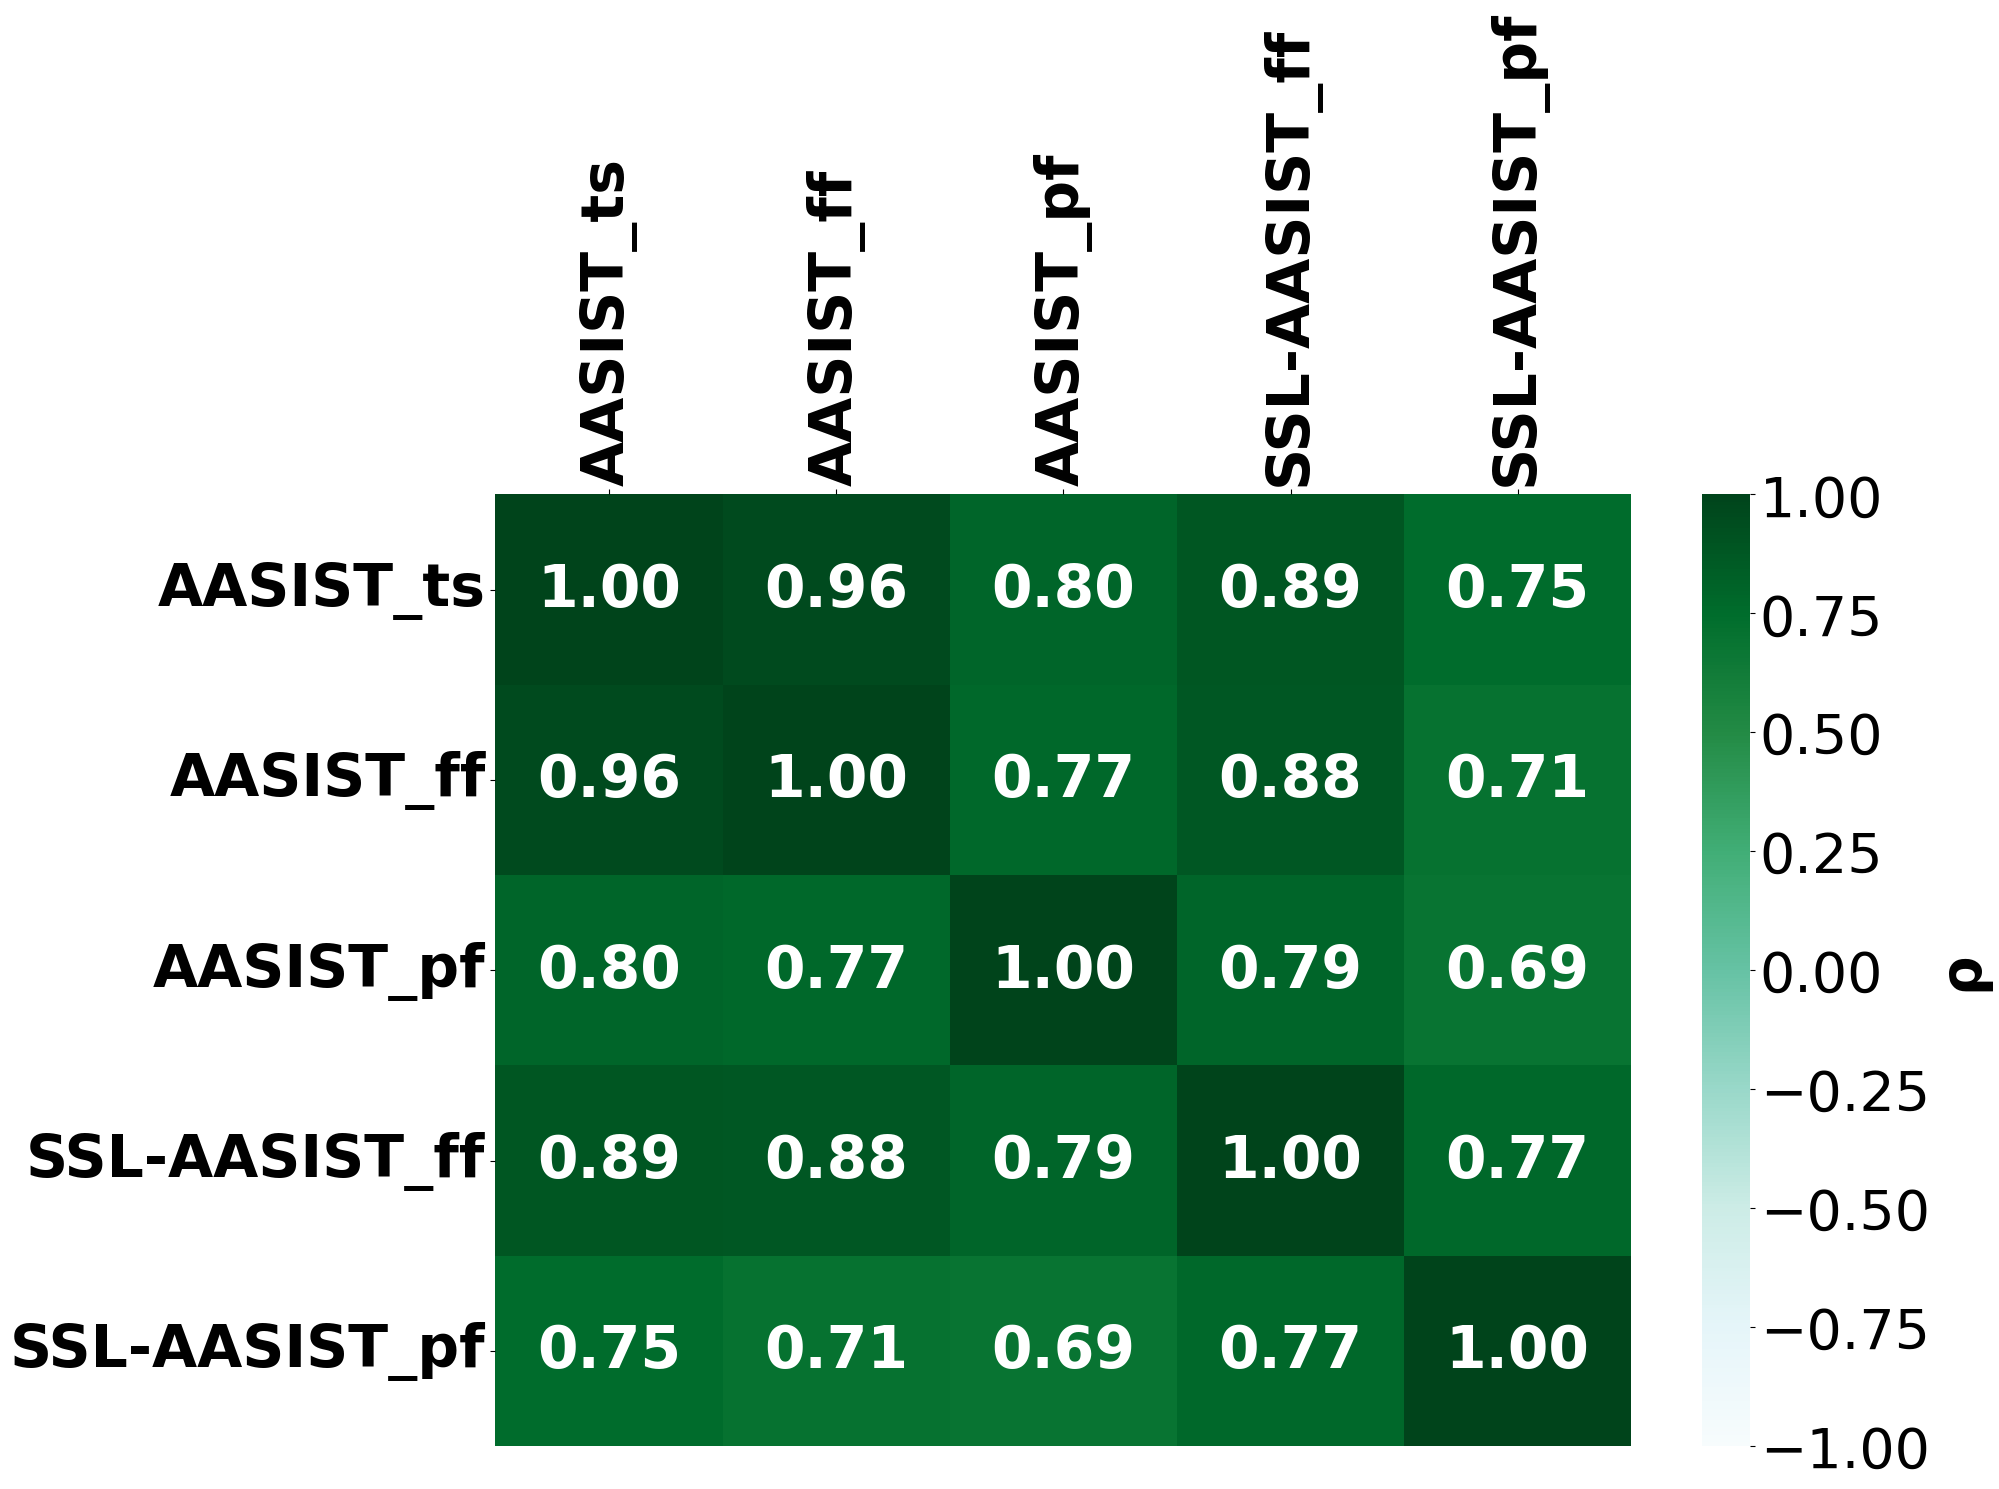

In [78]:
plot_corr_matrix(M, names=["AASIST_ts", "AASIST_ff", "AASIST_pf", "SSL-AASIST_ff", "SSL-AASIST_pf"], title="")

#### Per attack's FI

In [16]:
FI_perAtk_AASIST_ts = get_FI_per_attack(kan_module)

In [27]:
FI_perAtk_AASIST_ff = get_FI_per_attack(kan_module)

In [38]:
FI_perAtk_AASIST_pf = get_FI_per_attack(kan_module)

In [49]:
FI_perAtk_SSLAASIST_ff = get_FI_per_attack(kan_module)

In [60]:
FI_perAtk_SSLAASIST_pf = get_FI_per_attack(kan_module)

In [61]:
list_runs = [FI_perAtk_AASIST_ts, FI_perAtk_AASIST_ff, FI_perAtk_AASIST_pf, FI_perAtk_SSLAASIST_ff, FI_perAtk_SSLAASIST_pf]

In [62]:
list_M = []
for i in range(17):
    list_M.append(get_rank_perAtk_multi_runs(attack=i, list_runs=list_runs))
list_M = np.array(list_M)

In [63]:
list_M.shape

(17, 5, 5)

In [68]:
def plot_corr_grid(M_list, titles=None, names=None, upper_only=True,
                   cmap="YlGn", annot=True, fmt=".2f"):
    
    k = len(M_list)
    N = M_list[0].shape[0]
    assert all(M.shape == (N, N) for M in M_list), "All matrices must be same size."

    if titles is None:
        titles = [f"A{i+1:02d}" for i in range(k)]
    if names is None:
        names = [str(i+1) for i in range(N)]

    # choose a compact grid
    cols = min(6, k)                    # up to 5 across; adjust if you prefer
    rows = math.ceil(k / cols)

    fig, axes = plt.subplots(rows, cols,
                             figsize=(cols*3.2, rows*3.2),
                             constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    vmin, vmax = -1.0, 1.0
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    for ax, M, title in zip(axes, M_list, titles):
        df = pd.DataFrame(M, index=names, columns=names)
        mask = np.tril(np.ones_like(df, dtype=bool), k=-1) if upper_only else None
        sns.heatmap(df, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
                    square=True, mask=mask, annot=annot, fmt=fmt,
                    cbar=False)
        ax.set_title(title, pad=6, fontsize=10)
        ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, labelsize=8)
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90)

    # hide any unused axes
    for ax in axes[len(M_list):]:
        ax.axis("off")

    # one shared colorbar
    sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes[:len(M_list)], fraction=0.03, pad=0.01)
    cbar.set_label("ρ")

    plt.show()

In [68]:
def plot_corr_grid(M_list, titles=None, names=None, upper_only=True,
                   cmap="YlGn", annot=True, fmt=".2f"):
    
    k = len(M_list)
    N = M_list[0].shape[0]
    assert all(M.shape == (N, N) for M in M_list), "All matrices must be same size."

    if titles is None:
        titles = [f"A{i+1:02d}" for i in range(k)]
    if names is None:
        names = [str(i+1) for i in range(N)]

    # choose a compact grid
    cols = min(6, k)                    # up to 5 across; adjust if you prefer
    rows = math.ceil(k / cols)

    fig, axes = plt.subplots(rows, cols,
                             figsize=(cols*15, rows*15),
                             constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    vmin, vmax = -1.0, 1.0
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    for ax, M, title in zip(axes, M_list, titles):
        df = pd.DataFrame(M, index=names, columns=names)
        mask = np.tril(np.ones_like(df, dtype=bool), k=-1) if upper_only else None
        sns.heatmap(df, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
                    square=True, mask=mask, annot=annot, fmt=fmt,
                    cbar=False,
                    annot_kws={"size": 42, "weight": "bold"},)
        ax.set_title(title, pad=6, fontsize=50, fontweight='bold')
        ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, labelsize=42)

        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight('bold')
            
        ax.set_xticklabels(ax.get_xticklabels(), rotation=90)
        ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

    # hide any unused axes
    for ax in axes[len(M_list):]:
        ax.axis("off")

    # one shared colorbar
    sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes[:len(M_list)], fraction=0.03, pad=0.01)
    cbar.ax.tick_params(labelsize=42)
    cbar.set_label("ρ", fontsize=60, fontweight='bold')
    plt.savefig("abc.png")
    plt.show()

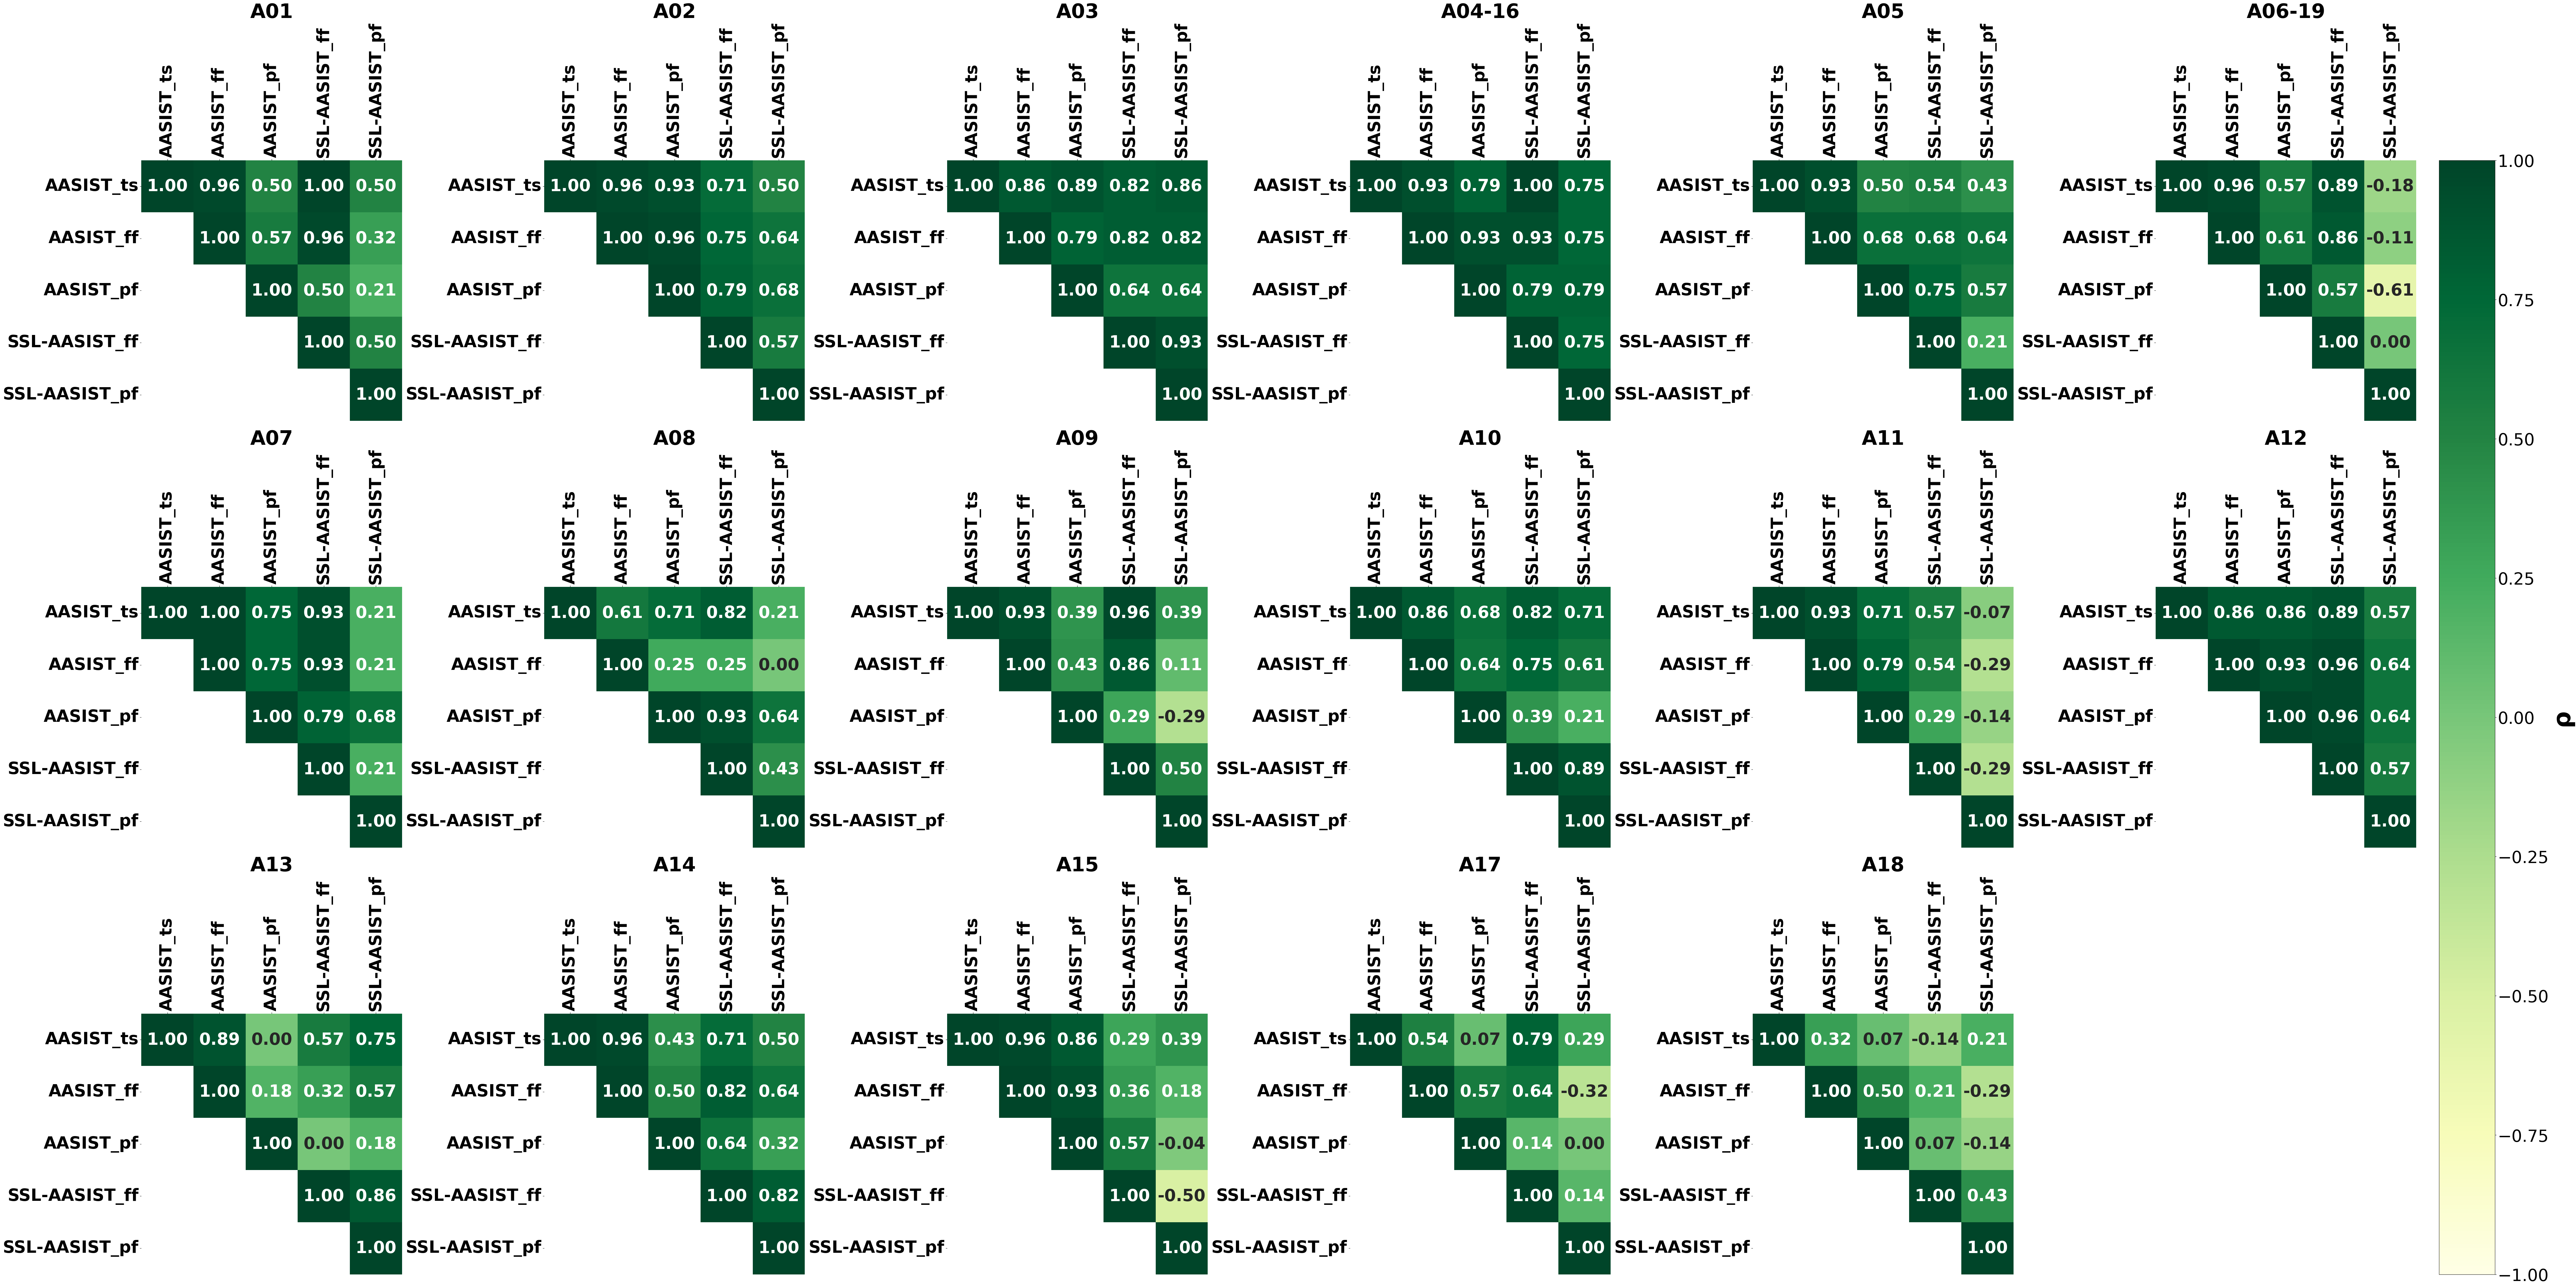

In [69]:
plot_corr_grid(list_M,
               titles=["A01", "A02", "A03", "A04-16", "A05", "A06-19", "A07", "A08", "A09", "A10", "A11", "A12", "A13", "A14", "A15", "A17", "A18"],
               names=["AASIST_ts", "AASIST_ff", "AASIST_pf", "SSL-AASIST_ff", "SSL-AASIST_pf"])

### **Scenario 4: Different FI methods**

In [1]:
%cd /scratch/project_2006687/hoangph/_thesis/ppm_v4/source_tracing

/scratch/project_2006687/hoangph/_thesis/ppm_v4/source_tracing


In [2]:
!ls

AttackAttr_embds  evaluate_deepfake_detection.py
AttackCls_embds   evaluate.py
backbones	  extracted_embds
config		  feature_extraction.py
core.1803143	  FI_utils.py
core.1804538	  get_shap_FIscores.py
core.1820090	  ID_OOD_distribution.png
core.1834255	  kan_figures
core.1834274	  kan_simplify
core.1842687	  logs
core.1853508	  model.py
core.1856550	  plots
core.1862306	  __pycache__
core.1862325	  RawBoost.py
core.1872401	  shap_values
core.1877436	  train.py
core.1878995	  train.sh
core.1886469	  TSNE_df_ID_OOD.png
core.1886491	  TSNE_features_visualization.py
data		  utils.py
data_utils.py	  weights


In [3]:
import os
import math
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.cm import ScalarMappable

from tqdm.auto import tqdm

import torch
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from data_utils import fetch_protocol, Dataset_ASVspoof2019_attr17, ASVSpoof2019_Attr17_attack_attribute_structure
from model import CMMTLKAN
from FI_utils import *

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import balanced_accuracy_score

from itertools import combinations


**Utils**

In [4]:
in_vars=["Text (inputs)", "Speech_human (inputs)", "Speech_TTS (inputs)",
         "NLP (processor)", "WORLD (processor)", "LPCC/MFCC (processor)", "CNN+bi-RNN (processor)", "ASR (processor)", "MFCC/i-vector (processor)",
         "HMM (duration)", "FF (duration)", "RNN (duration)", "Attention (duration)", "DTW (duration)", "None (duration)", 
         "AR-RNN (conversion)", "FF (conversion)", "CART (conversion)", "VAE (conversion)", "GMM-UBM (conversion)", "RNN (conversion)", "AR-RNN+CNN (conversion)", "Moment-match (conversion)", "linear (conversion)",
         "VAE (speaker)", "one-hot (speaker)", "d-vector_RNN (speaker)", "PLDA (speaker)", "None (speaker)", 
         "MCC-F0 (outputs)", "MCC-F0-BAP (outputs)", "MFCC-F0 (outputs)", "MCC-F0-AP (outputs)", "LPC (outputs)", "MCC-F0-BA (outputs)", "mel-spec (outputs)", "F0+ling (outputs)", "MCC (outputs)", "MFCC (outputs)",
         "WaveNet (waveform)", "WORLD (waveform)", "Concat (waveform)", "SpecFiltOLA (waveform)", "NeuralFilt (waveform)", "Vocaine (waveform)", "WaveRNN (waveform)", "GriffinLim (waveform)", "WaveFilt (waveform)", "STRAIGHT (waveform)", "MFCCvoc (waveform)"
        ]
out_vars=['A01', 'A02', 'A03', 'A04-16', 'A05', 'A06-19', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A17', 'A18']

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### **Built-in KAN FI**

In [6]:
embds_folder = "./extracted_embds"
exp_name = "ST_RB_AASIST_MTL_KANaux_trainingScratch"
exp_folder = os.path.join(embds_folder, exp_name)

eval_attackAttr_embeddings_file = "ASVspoof2019_attr17_eval_attackAttr_embeddings.npy"

In [7]:
eval_attackAttr_embeddings_path = os.path.join(exp_folder, eval_attackAttr_embeddings_file)

In [8]:
eval_attackAttr_embeddings = np.load(eval_attackAttr_embeddings_path)
eval_attackAttr_embeddings.shape

(47880, 50)

In [9]:
eval_protocols_path = './data/ASVspoof2019_attr17_cm_protocols/Eval_ASVspoof19_attr17.txt'
eval_attack_labels = load_attack_labels(eval_protocols_path)

In [10]:
eval_dataset = AttClsDataset(eval_attackAttr_embeddings, eval_attack_labels)

In [11]:
eval_loader = DataLoader(eval_dataset,
                             batch_size=len(eval_dataset),
                             shuffle=False,
                             drop_last=False,
                             pin_memory=True,
                             collate_fn=None)
print("Number of batches in eval loader: ", len(eval_loader))

Number of batches in eval loader:  1


In [12]:
pretrained_path = "./weights/best_ST_RB_AASIST_MTL_KANaux_trainingScratch.pt"
    
model = CMMTLKAN(
                backbone="AASIST",
                use_pretrained_backbone=False,
                freeze_backbone=False,
                device=device, 
                kan_auxiliary_structure=ASVSpoof2019_Attr17_attack_attribute_structure,
                seed=42
            ).to(device)
model.load_state_dict(torch.load(pretrained_path, map_location=device))
# model.kan_module.module_inFeatures(structure)

nb_params = sum([param.view(-1).size()[0] for param in model.parameters()])
print("no. model params:{}".format(nb_params))

Adding modular structure for KAN
no. model params:492444


In [13]:
kan_module = model.kan_module
# kan_module.module_inFeatures(structure)
kan_module.to(device)

MultKAN(
  (act_fun): ModuleList(
    (0): KANLayer(
      (base_fun): SiLU()
    )
  )
  (base_fun): SiLU()
)

In [14]:
eval_avg_acc, eval_avg_balanced_acc, attCls_cfsMatrix, attCls_clsReport = eval_AttackCls(eval_loader, kan_module, device)

  0%|          | 0/1 [00:00<?, ?it/s]

In [15]:
print("\nEvaluation Results:")
print("Average Accuracy:", eval_avg_acc)
print("Average Balanced Accuracy:", eval_avg_balanced_acc)
# print("\nAttack Classification Confusion Matrix:")
# plot_cfm(attCls_cfsMatrix, out_vars)
# print("\nAttack Classification Report:")
# print(attCls_clsReport)


Evaluation Results:
Average Accuracy: 0.9959899749373433
Average Balanced Accuracy: 0.9952779692968117


In [16]:
kan_module.cache_data.shape

torch.Size([47880, 50])

In [17]:
feature_scores = kan_module.feature_score
feature_scores

tensor([0.2056, 0.0341, 0.0425, 0.0362, 0.0223, 0.0103, 0.0208, 0.0351, 0.0116,
        0.0390, 0.0116, 0.0236, 0.0063, 0.0140, 0.0370, 0.0247, 0.0250, 0.0115,
        0.0292, 0.0123, 0.0513, 0.0118, 0.0136, 0.0117, 0.0485, 0.0438, 0.0086,
        0.0159, 0.0455, 0.0599, 0.0512, 0.0153, 0.0266, 0.0155, 0.0246, 0.0179,
        0.0160, 0.0176, 0.0174, 0.0495, 0.0563, 0.0156, 0.0160, 0.0342, 0.0300,
        0.0127, 0.0272, 0.0408, 0.0257, 0.0101], device='cuda:0',
       grad_fn=<MeanBackward1>)

### **evaluating whole data's FI**

In [18]:
KAN_builtin_FI = kan_module.feature_score.detach().cpu().numpy()
KAN_builtin_FI

array([0.20562686, 0.03405593, 0.04245324, 0.03617182, 0.02231999,
       0.0103405 , 0.02076587, 0.03514146, 0.01164321, 0.03897751,
       0.01164634, 0.02355151, 0.00633507, 0.01404929, 0.03701304,
       0.02465292, 0.0250267 , 0.01152082, 0.0292038 , 0.01229984,
       0.05129093, 0.01184083, 0.01361861, 0.01171748, 0.04847642,
       0.04377294, 0.00864215, 0.01590724, 0.04545281, 0.05985686,
       0.0512073 , 0.01531271, 0.02655103, 0.01547225, 0.02456337,
       0.01789828, 0.0160277 , 0.01757327, 0.01736732, 0.0495399 ,
       0.05634766, 0.01560541, 0.01595636, 0.03417489, 0.02999453,
       0.01270396, 0.02717767, 0.04080744, 0.0257196 , 0.01014895],
      dtype=float32)

#### **KAN + SHAP FI**

In [3]:
# !python get_shap_FIscores.py

get Shap FI scores for GWMTL-KAN aux: seed = 4321, bg_data with 5000 samples
Using device: cuda
Adding modular structure for KAN
Loaded pretrained model from: ./weights/best_ST_RB_AASIST_MTL_KANaux_trainingScratch.pt
no. model params:492444
  0%|                                                 | 0/47880 [00:00<?, ?it/s]/scratch/project_2006687/hoangph/.venv/lib64/python3.12/site-packages/shap/explainers/_deep/deep_pytorch.py:255: UserWarning: unrecognized nn.Module: SiLU
  warnings.warn(f"unrecognized nn.Module: {module_type}")
100%|███████████████████████████████████| 47880/47880 [1:10:43<00:00, 11.28it/s]
DONE


In [19]:
import pickle

shap_FI_file = "./shap_values/shap_values_AASIST_MTL_KANaux.pkl"

shap_FI = pickle.load(open(shap_FI_file, 'rb'))

In [20]:
shap_FI.shape

(47880, 50, 17)

In [21]:
# S: (N, F, C)
gfi = np.abs(shap_FI).mean(axis=(0, 2))          # (F,)
# (tuỳ chọn) chuẩn hoá để tổng = 1
gfi_norm = gfi / (gfi.sum() + 1e-12)

In [22]:
gfi_norm.shape

(50,)

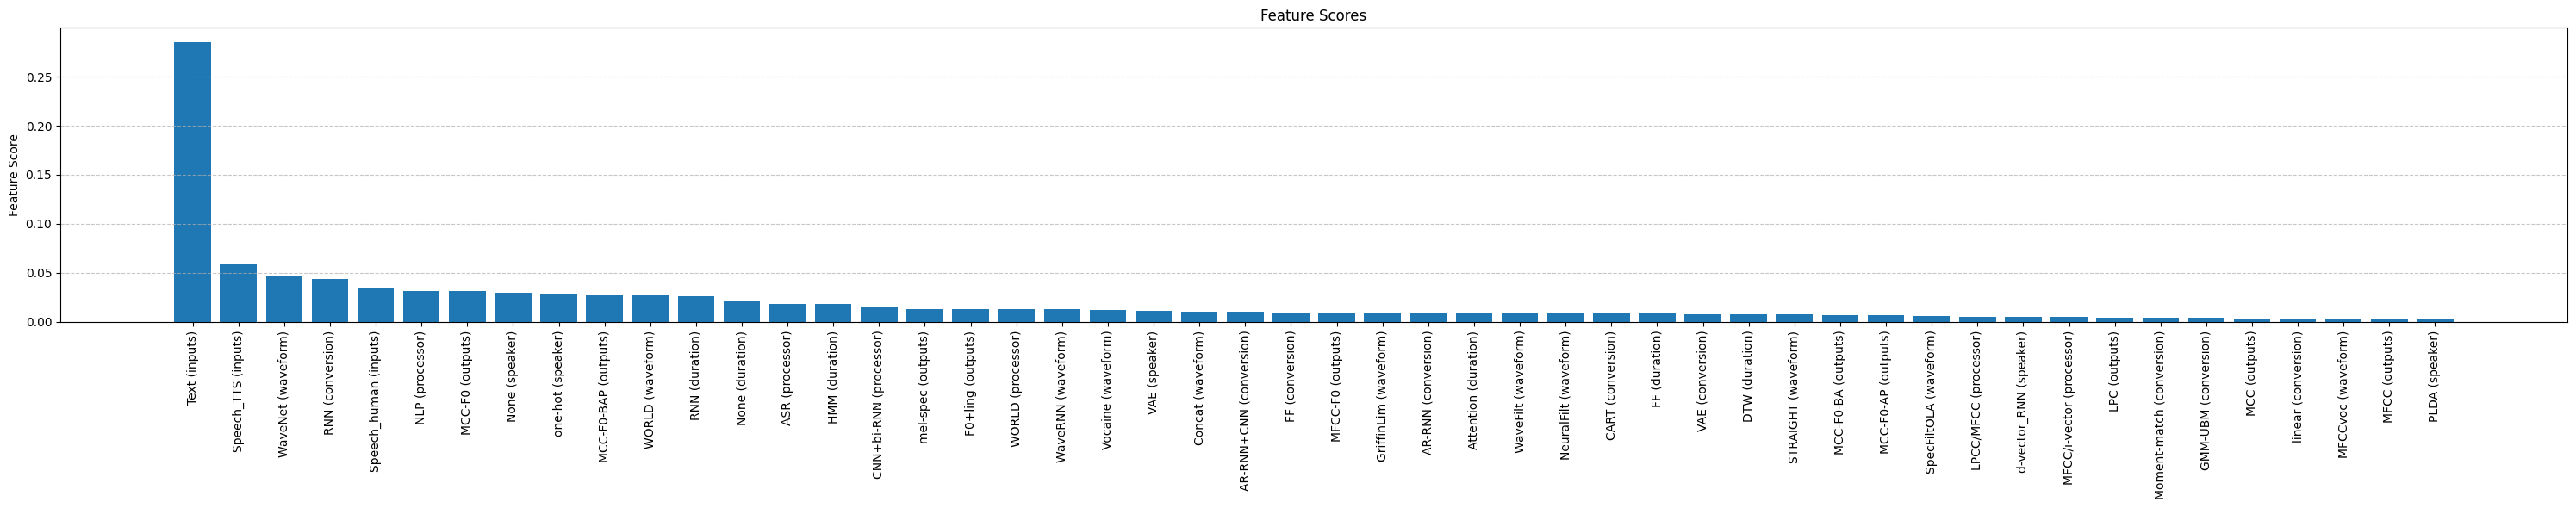

In [23]:
df = pd.DataFrame({'Feature': np.array(in_vars), 'Score': gfi_norm})
df_sorted = df.sort_values(by='Score', ascending=False)

# Plot
plt.figure(figsize=(30, 6))
plt.bar(df_sorted['Feature'], df_sorted['Score'])
plt.xticks(rotation=90)
plt.ylabel('Feature Score')
plt.title('Feature Scores')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [24]:
gfi_by_class = np.abs(shap_FI).mean(axis=0).T    # (F, C) -> transpose -> (C, F) = (17, 50)
# (tuỳ chọn) chuẩn hoá theo hàng (mỗi lớp tổng = 1)
gfi_by_class_norm = gfi_by_class / (gfi_by_class.sum(axis=1, keepdims=True) + 1e-12)

In [25]:
gfi_by_class_norm.shape

(17, 50)

In [26]:
def plot_inFeature_importance(shap_scores, outNode_id):
    scores = shap_scores[outNode_id]

    # Create a DataFrame for sorting
    df = pd.DataFrame({'Feature': np.array(in_vars), 'Score': scores})
    df_sorted = df.sort_values(by='Score', ascending=False)
    
    # Plot
    plt.figure(figsize=(30, 6))
    plt.bar(df_sorted['Feature'], df_sorted['Score'])
    plt.xticks(rotation=90)
    plt.ylabel('Feature Score')
    plt.title('Input feature importance for A0{}'.format(outNode_id+1))
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

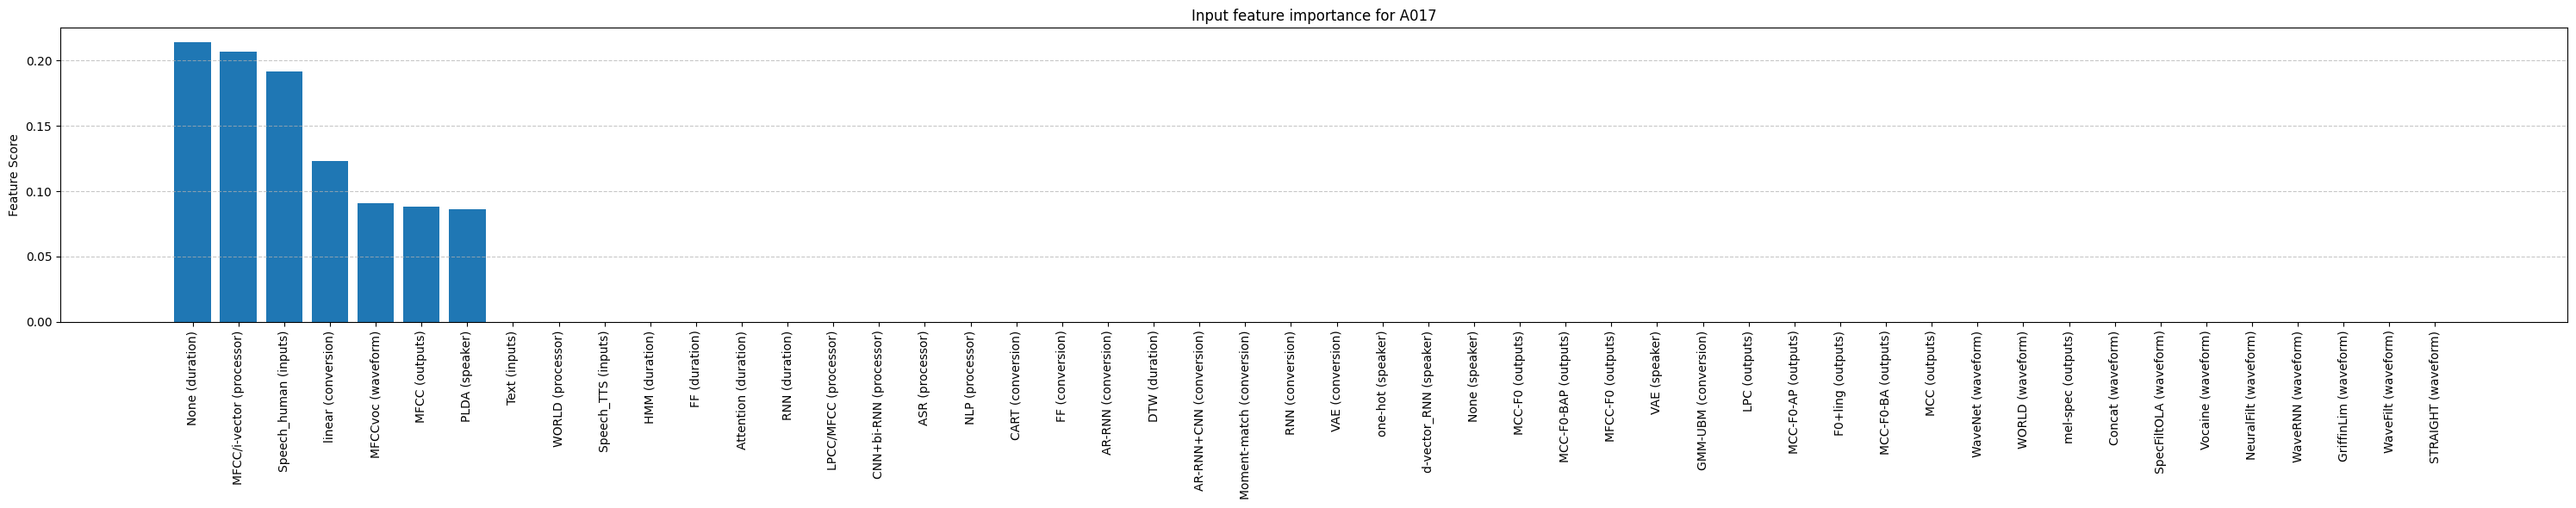

In [27]:
plot_inFeature_importance(gfi_by_class_norm, 16)

#### **Comparing built-in KAN's FI and SHAP's FI**

In [28]:
rank_KAN_builtin_FI= rank_feature_scores(KAN_builtin_FI)
rank_KAN_builtin_FI

array([ 1, 17, 10, 14, 27, 47, 28, 15, 45, 12, 44, 26, 50, 38, 13, 24, 23,
       46, 19, 41,  4, 42, 39, 43,  7,  9, 49, 34,  8,  2,  5, 37, 21, 36,
       25, 29, 32, 30, 31,  6,  3, 35, 33, 16, 18, 40, 20, 11, 22, 48])

In [29]:
rank_SHAP_FI = rank_feature_scores(gfi_norm)
rank_SHAP_FI

array([ 1,  5,  2,  6, 19, 40, 16, 14, 42, 15, 33, 12, 29, 35, 13, 28, 25,
       32, 34, 45,  4, 24, 44, 47, 22,  9, 41, 50,  8,  7, 10, 26, 38, 43,
       37, 17, 18, 46, 49,  3, 11, 23, 39, 31, 21, 20, 27, 30, 36, 48])

In [30]:
list_ranks = np.array([rank_KAN_builtin_FI, rank_SHAP_FI])
M = spearman_pairwise(list_ranks)
M

array([[1.        , 0.72398559],
       [0.72398559, 1.        ]])

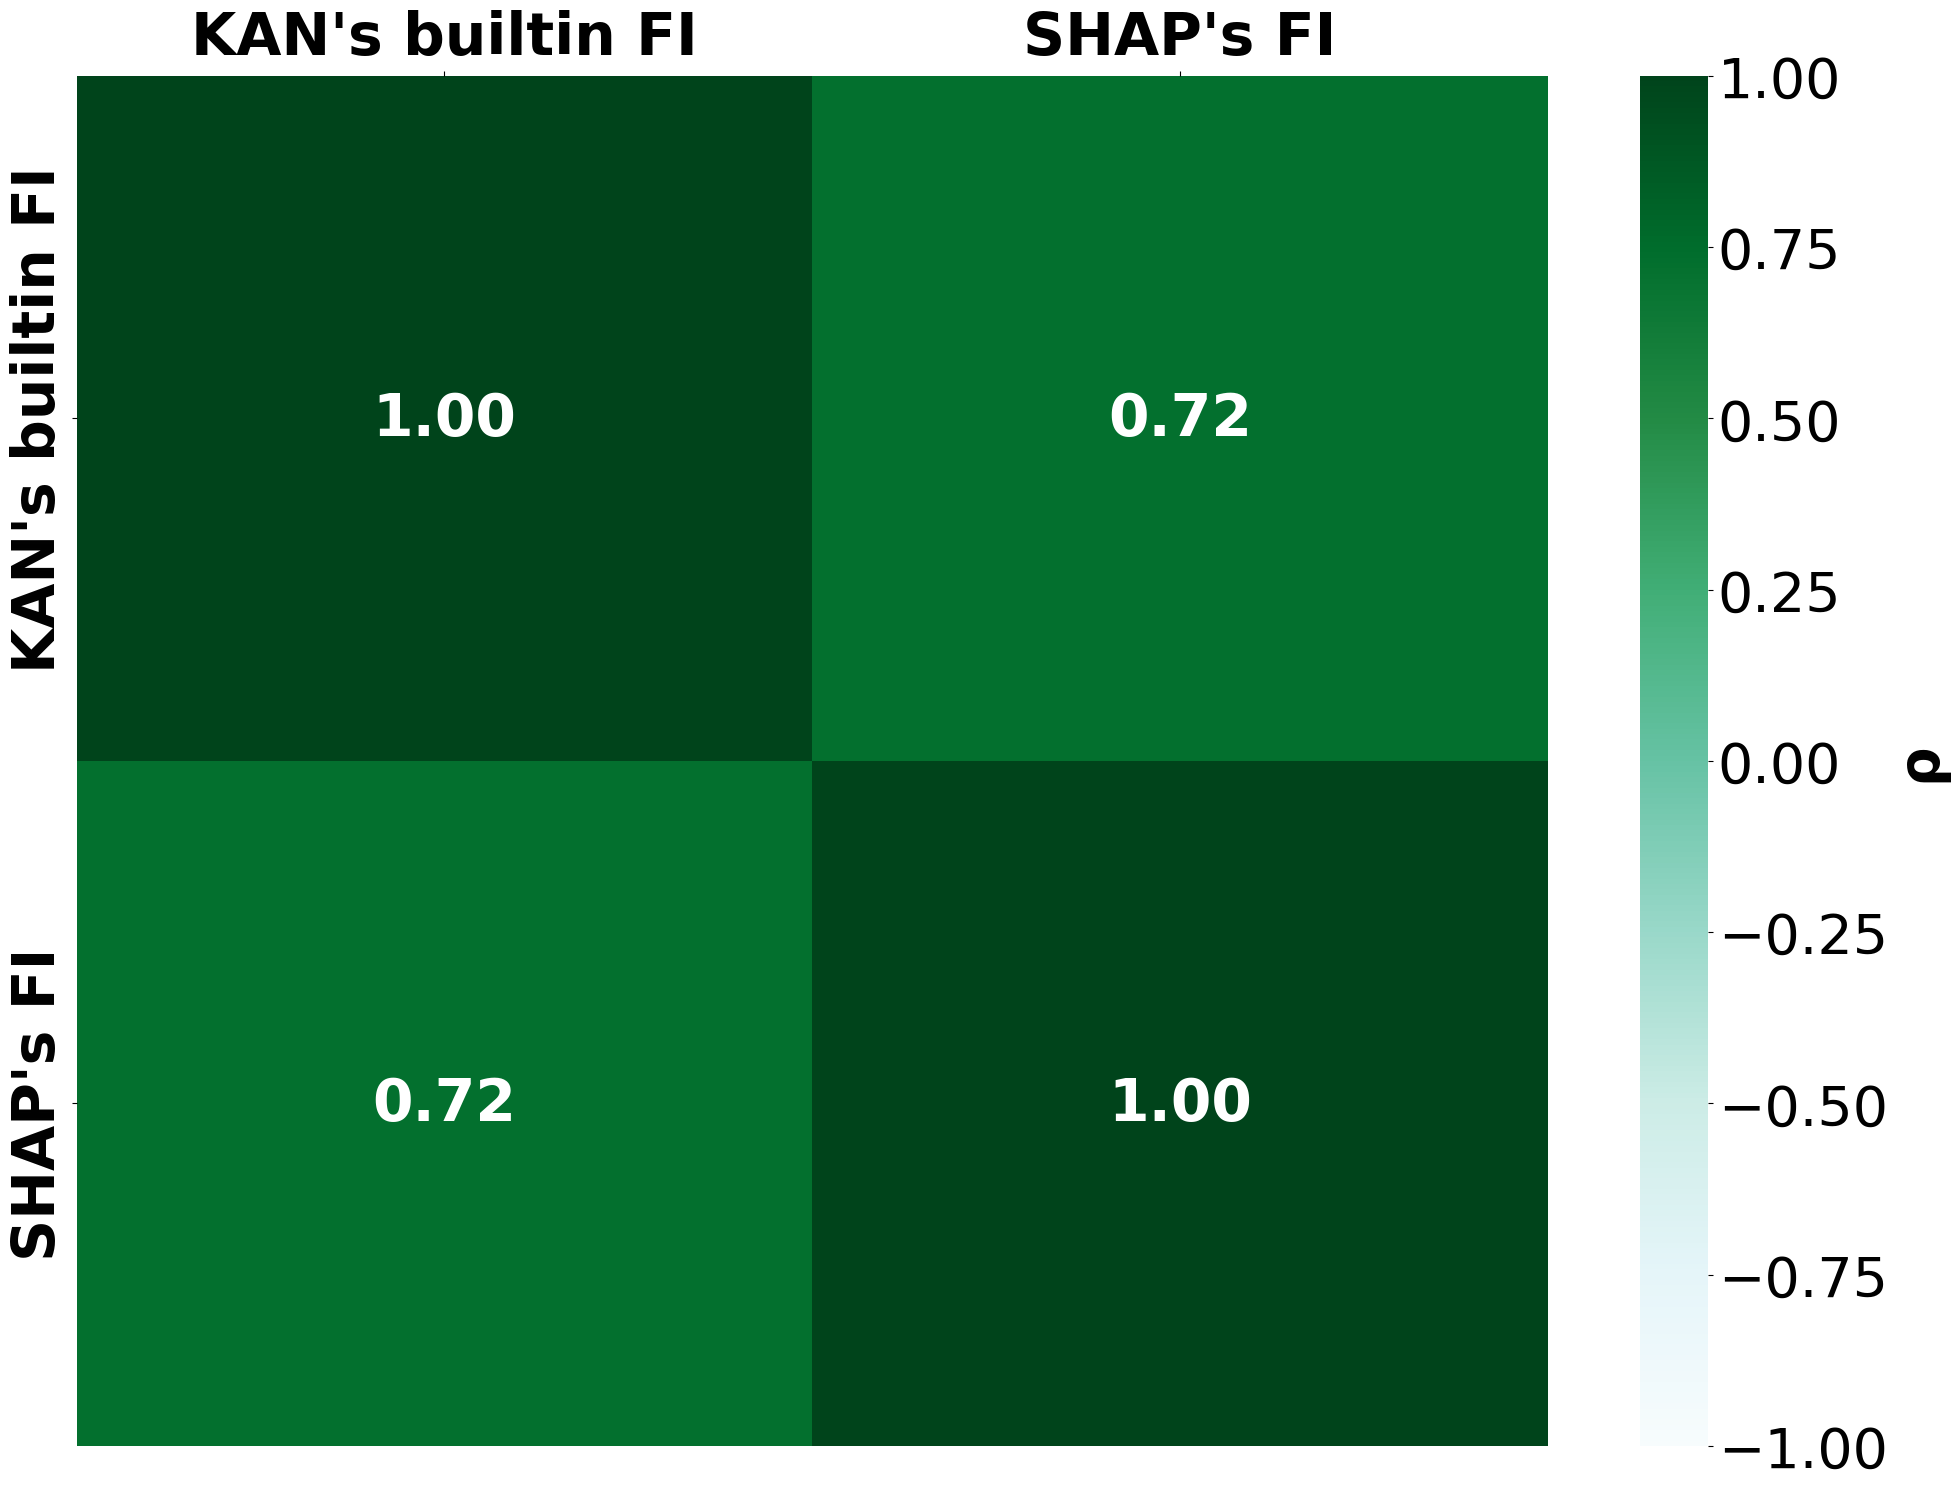

In [31]:
plot_corr_matrix(M, names=["KAN's builtin FI", "SHAP's FI"], title="")

#### **Per attack's FI**

In [32]:
KAN_builtin_FI_perAtk = get_FI_per_attack(kan_module)

In [33]:
KAN_builtin_FI_perAtk.shape

(17, 50)

In [34]:
list_runs = [KAN_builtin_FI_perAtk, gfi_by_class_norm]

In [36]:
def get_rank_perAtk_multi_runs(attack=0, list_runs=list_runs):
    
    runs_scores = np.array([rank_feature_scores(x[attack]) for x in list_runs]) 

    M = spearman_pairwise(runs_scores, task='per_attack')

    return M

In [37]:
list_M = []
for i in range(17):
    list_M.append(get_rank_perAtk_multi_runs(attack=i))
list_M = np.array(list_M)

In [38]:
list_M.shape

(17, 2, 2)

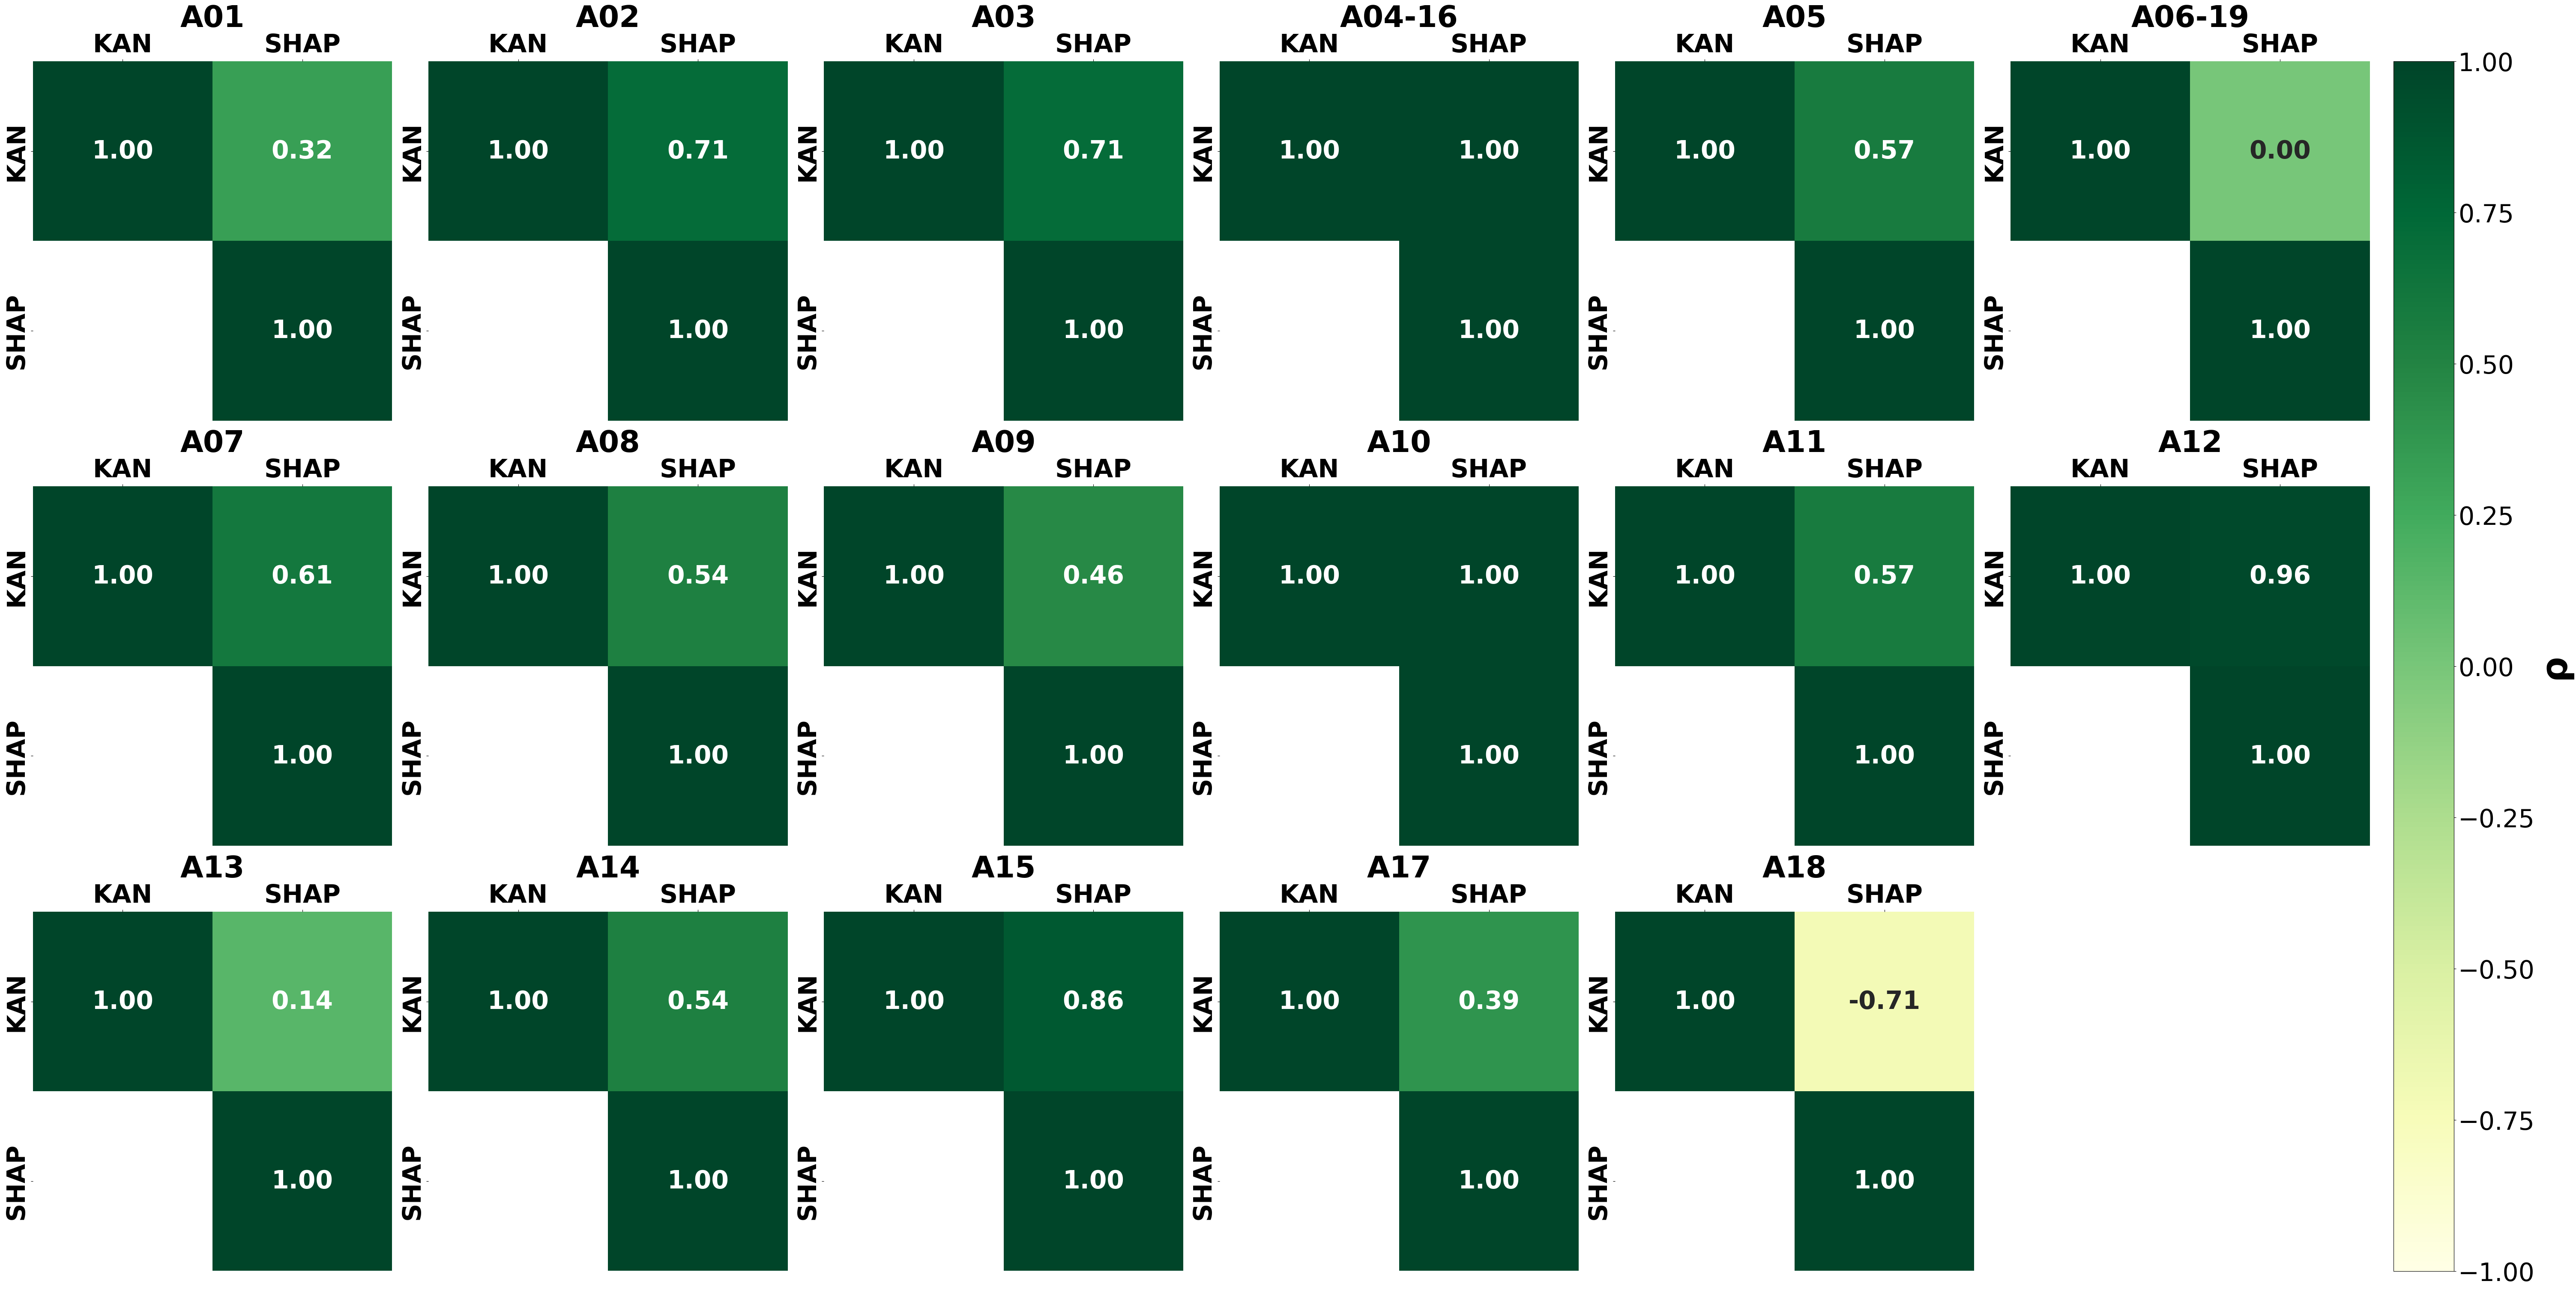

In [39]:
plot_corr_grid(list_M,
               titles=["A01", "A02", "A03", "A04-16", "A05", "A06-19", "A07", "A08", "A09", "A10", "A11", "A12", "A13", "A14", "A15", "A17", "A18"],
               names=["KAN", "SHAP"])

## **Criteria 2: Stability**

In [1]:
%cd /scratch/project_2006687/hoangph/_thesis/ppm_v4/source_tracing

/scratch/project_2006687/hoangph/_thesis/ppm_v4/source_tracing


In [2]:
!ls

AttackAttr_embds  evaluate_deepfake_detection.py
AttackCls_embds   evaluate.py
backbones	  extracted_embds
config		  feature_extraction.py
core.1803143	  FI_utils.py
core.1804538	  get_shap_FIscores.py
core.1820090	  ID_OOD_distribution.png
core.1834255	  kan_figures
core.1834274	  kan_simplify
core.1842687	  logs
core.1853508	  model.py
core.1856550	  plots
core.1862306	  __pycache__
core.1862325	  RawBoost.py
core.1872401	  shap_values
core.1877436	  train.py
core.1878995	  train.sh
core.1886469	  TSNE_df_ID_OOD.png
core.1886491	  TSNE_features_visualization.py
data		  utils.py
data_utils.py	  weights


In [3]:
import os
import math
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.cm import ScalarMappable

from tqdm.auto import tqdm

import torch
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from data_utils import fetch_protocol, Dataset_ASVspoof2019_attr17, ASVSpoof2019_Attr17_attack_attribute_structure
from model import CMMTLKAN
from FI_utils import *

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import balanced_accuracy_score

from itertools import combinations


#### utils

In [4]:
in_vars=["Text (inputs)", "Speech_human (inputs)", "Speech_TTS (inputs)",
         "NLP (processor)", "WORLD (processor)", "LPCC/MFCC (processor)", "CNN+bi-RNN (processor)", "ASR (processor)", "MFCC/i-vector (processor)",
         "HMM (duration)", "FF (duration)", "RNN (duration)", "Attention (duration)", "DTW (duration)", "None (duration)", 
         "AR-RNN (conversion)", "FF (conversion)", "CART (conversion)", "VAE (conversion)", "GMM-UBM (conversion)", "RNN (conversion)", "AR-RNN+CNN (conversion)", "Moment-match (conversion)", "linear (conversion)",
         "VAE (speaker)", "one-hot (speaker)", "d-vector_RNN (speaker)", "PLDA (speaker)", "None (speaker)", 
         "MCC-F0 (outputs)", "MCC-F0-BAP (outputs)", "MFCC-F0 (outputs)", "MCC-F0-AP (outputs)", "LPC (outputs)", "MCC-F0-BA (outputs)", "mel-spec (outputs)", "F0+ling (outputs)", "MCC (outputs)", "MFCC (outputs)",
         "WaveNet (waveform)", "WORLD (waveform)", "Concat (waveform)", "SpecFiltOLA (waveform)", "NeuralFilt (waveform)", "Vocaine (waveform)", "WaveRNN (waveform)", "GriffinLim (waveform)", "WaveFilt (waveform)", "STRAIGHT (waveform)", "MFCCvoc (waveform)"
        ]
out_vars=['A01', 'A02', 'A03', 'A04-16', 'A05', 'A06-19', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A17', 'A18']

In [5]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


### **evaluating whole data's FI**

In [68]:
embds_folder = "./extracted_embds"
exp_name = "ST_RB_AASIST_MTL_KANaux_trainingScratch"
exp_folder = os.path.join(embds_folder, exp_name)

eval_attackAttr_embeddings_file = "ASVspoof2019_attr17_eval_attackAttr_embeddings.npy"

In [69]:
eval_attackAttr_embeddings_path = os.path.join(exp_folder, eval_attackAttr_embeddings_file)

In [70]:
eval_attackAttr_embeddings = np.load(eval_attackAttr_embeddings_path)
eval_attackAttr_embeddings.shape

(47880, 50)

In [71]:
eval_protocols_path = './data/ASVspoof2019_attr17_cm_protocols/Eval_ASVspoof19_attr17.txt'
eval_attack_labels = load_attack_labels(eval_protocols_path)

In [72]:
eval_dataset = AttClsDataset(eval_attackAttr_embeddings, eval_attack_labels)

In [73]:
eval_loader = DataLoader(eval_dataset,
                             batch_size=len(eval_dataset),
                             shuffle=False,
                             drop_last=False,
                             pin_memory=True,
                             collate_fn=None)
print("Number of batches in eval loader: ", len(eval_loader))

Number of batches in eval loader:  1


In [74]:
pretrained_path = "./weights/best_ST_RB_AASIST_MTL_KANaux_trainingScratch.pt"
    
model = CMMTLKAN(
                backbone="AASIST",
                use_pretrained_backbone=False,
                freeze_backbone=False,
                device=device, 
                kan_auxiliary_structure=ASVSpoof2019_Attr17_attack_attribute_structure,
                seed=42
            ).to(device)
model.load_state_dict(torch.load(pretrained_path, map_location=device))
# model.kan_module.module_inFeatures(structure)

nb_params = sum([param.view(-1).size()[0] for param in model.parameters()])
print("no. model params:{}".format(nb_params))

Adding modular structure for KAN
no. model params:492444


In [75]:
kan_module = model.kan_module
# kan_module.module_inFeatures(structure)
kan_module.to(device)

MultKAN(
  (act_fun): ModuleList(
    (0): KANLayer(
      (base_fun): SiLU()
    )
  )
  (base_fun): SiLU()
)

In [26]:
FI_bs1 = get_fi_per_bs(eval_loader, kan_module, device)
rank_FI_bs1 = rank_feature_scores(FI_bs1)
print(rank_FI_bs1)

  0%|          | 0/47880 [00:00<?, ?it/s]

[ 1  2  9  8 12 41  7 37 43 28 32  5 16 48  6 30 18 50 23 40  4 31 46 44
 27  3 10 42 11 26 22 49 15 38 29 19 14 47 39 20 17 45 33 24 21 36 13 35
 25 34]


In [36]:
FI_bs8 = get_fi_per_bs(eval_loader, kan_module, device)
rank_FI_bs8 = rank_feature_scores(FI_bs8)
print(rank_FI_bs8)

  0%|          | 0/5985 [00:00<?, ?it/s]

[ 1  2  4  8 18 44 32 14 42 15 34 17 50 43  7 27 20 48 24 41  9 46 37 47
 13  5 45 38  3  6 11 35 28 29 22 33 19 23 30 10 12 36 40 31 21 39 25 16
 26 49]


In [46]:
FI_bs32 = get_fi_per_bs(eval_loader, kan_module, device)
rank_FI_bs32 = rank_feature_scores(FI_bs32)
print(rank_FI_bs32)

  0%|          | 0/1497 [00:00<?, ?it/s]

[ 1  2  5  9 16 42 30 14 43 15 33 17 48 37  7 27 20 50 19 39  8 46 41 49
 13  6 44 38  3  4 12 35 32 31 26 34 18 25 29 10 11 36 40 28 22 45 24 21
 23 47]


In [57]:
FI_bs64 = get_fi_per_bs(eval_loader, kan_module, device)
rank_FI_bs64 = rank_feature_scores(FI_bs64)
print(rank_FI_bs64)

  0%|          | 0/749 [00:00<?, ?it/s]

[ 1  2  7  9 16 41 30 14 44 15 32 17 48 37  6 27 20 50 18 39  8 46 42 49
 13  5 43 38  3  4 12 35 33 31 26 34 19 25 29 10 11 36 40 28 22 45 24 21
 23 47]


In [67]:
FI_bs256 = get_fi_per_bs(eval_loader, kan_module, device)
rank_FI_bs256 = rank_feature_scores(FI_bs256)
print(rank_FI_bs256)

  0%|          | 0/188 [00:00<?, ?it/s]

[ 1  2  8  9 14 42 31 15 40 13 23 17 47 27  7 28 21 50 18 39  5 48 45 49
 16  6 44 36  4  3 12 37 33 34 30 35 20 26 32 10 11 38 41 24 25 46 29 22
 19 43]


In [76]:
eval_avg_acc, eval_avg_balanced_acc, attCls_cfsMatrix, attCls_clsReport = eval_AttackCls(eval_loader, kan_module, device)

  0%|          | 0/1 [00:00<?, ?it/s]

In [77]:
global_FI = kan_module.feature_score.detach().cpu().numpy()
global_FI

array([0.20562686, 0.03405593, 0.04245324, 0.03617182, 0.02231999,
       0.0103405 , 0.02076587, 0.03514146, 0.01164321, 0.03897751,
       0.01164634, 0.02355151, 0.00633507, 0.01404929, 0.03701304,
       0.02465292, 0.0250267 , 0.01152082, 0.0292038 , 0.01229984,
       0.05129093, 0.01184083, 0.01361861, 0.01171748, 0.04847642,
       0.04377294, 0.00864215, 0.01590724, 0.04545281, 0.05985686,
       0.0512073 , 0.01531271, 0.02655103, 0.01547225, 0.02456337,
       0.01789828, 0.0160277 , 0.01757327, 0.01736732, 0.0495399 ,
       0.05634766, 0.01560541, 0.01595636, 0.03417489, 0.02999453,
       0.01270396, 0.02717767, 0.04080744, 0.0257196 , 0.01014895],
      dtype=float32)

In [78]:
rank_global_FI = rank_feature_scores(global_FI)
rank_global_FI

array([ 1, 17, 10, 14, 27, 47, 28, 15, 45, 12, 44, 26, 50, 38, 13, 24, 23,
       46, 19, 41,  4, 42, 39, 43,  7,  9, 49, 34,  8,  2,  5, 37, 21, 36,
       25, 29, 32, 30, 31,  6,  3, 35, 33, 16, 18, 40, 20, 11, 22, 48])

In [79]:
list_ranks = np.array([rank_global_FI, rank_FI_bs1, rank_FI_bs8, rank_FI_bs32, rank_FI_bs64, rank_FI_bs256])
M = spearman_pairwise(list_ranks)
M

array([[1.        , 0.56081633, 0.91702281, 0.91404562, 0.9117407 ,
        0.88408163],
       [0.56081633, 1.        , 0.63860744, 0.65810324, 0.66012005,
        0.64187275],
       [0.91702281, 0.63860744, 1.        , 0.98818727, 0.98578631,
        0.95265306],
       [0.91404562, 0.65810324, 0.98818727, 1.        , 0.99932773,
        0.98031212],
       [0.9117407 , 0.66012005, 0.98578631, 0.99932773, 1.        ,
        0.98165666],
       [0.88408163, 0.64187275, 0.95265306, 0.98031212, 0.98165666,
        1.        ]])

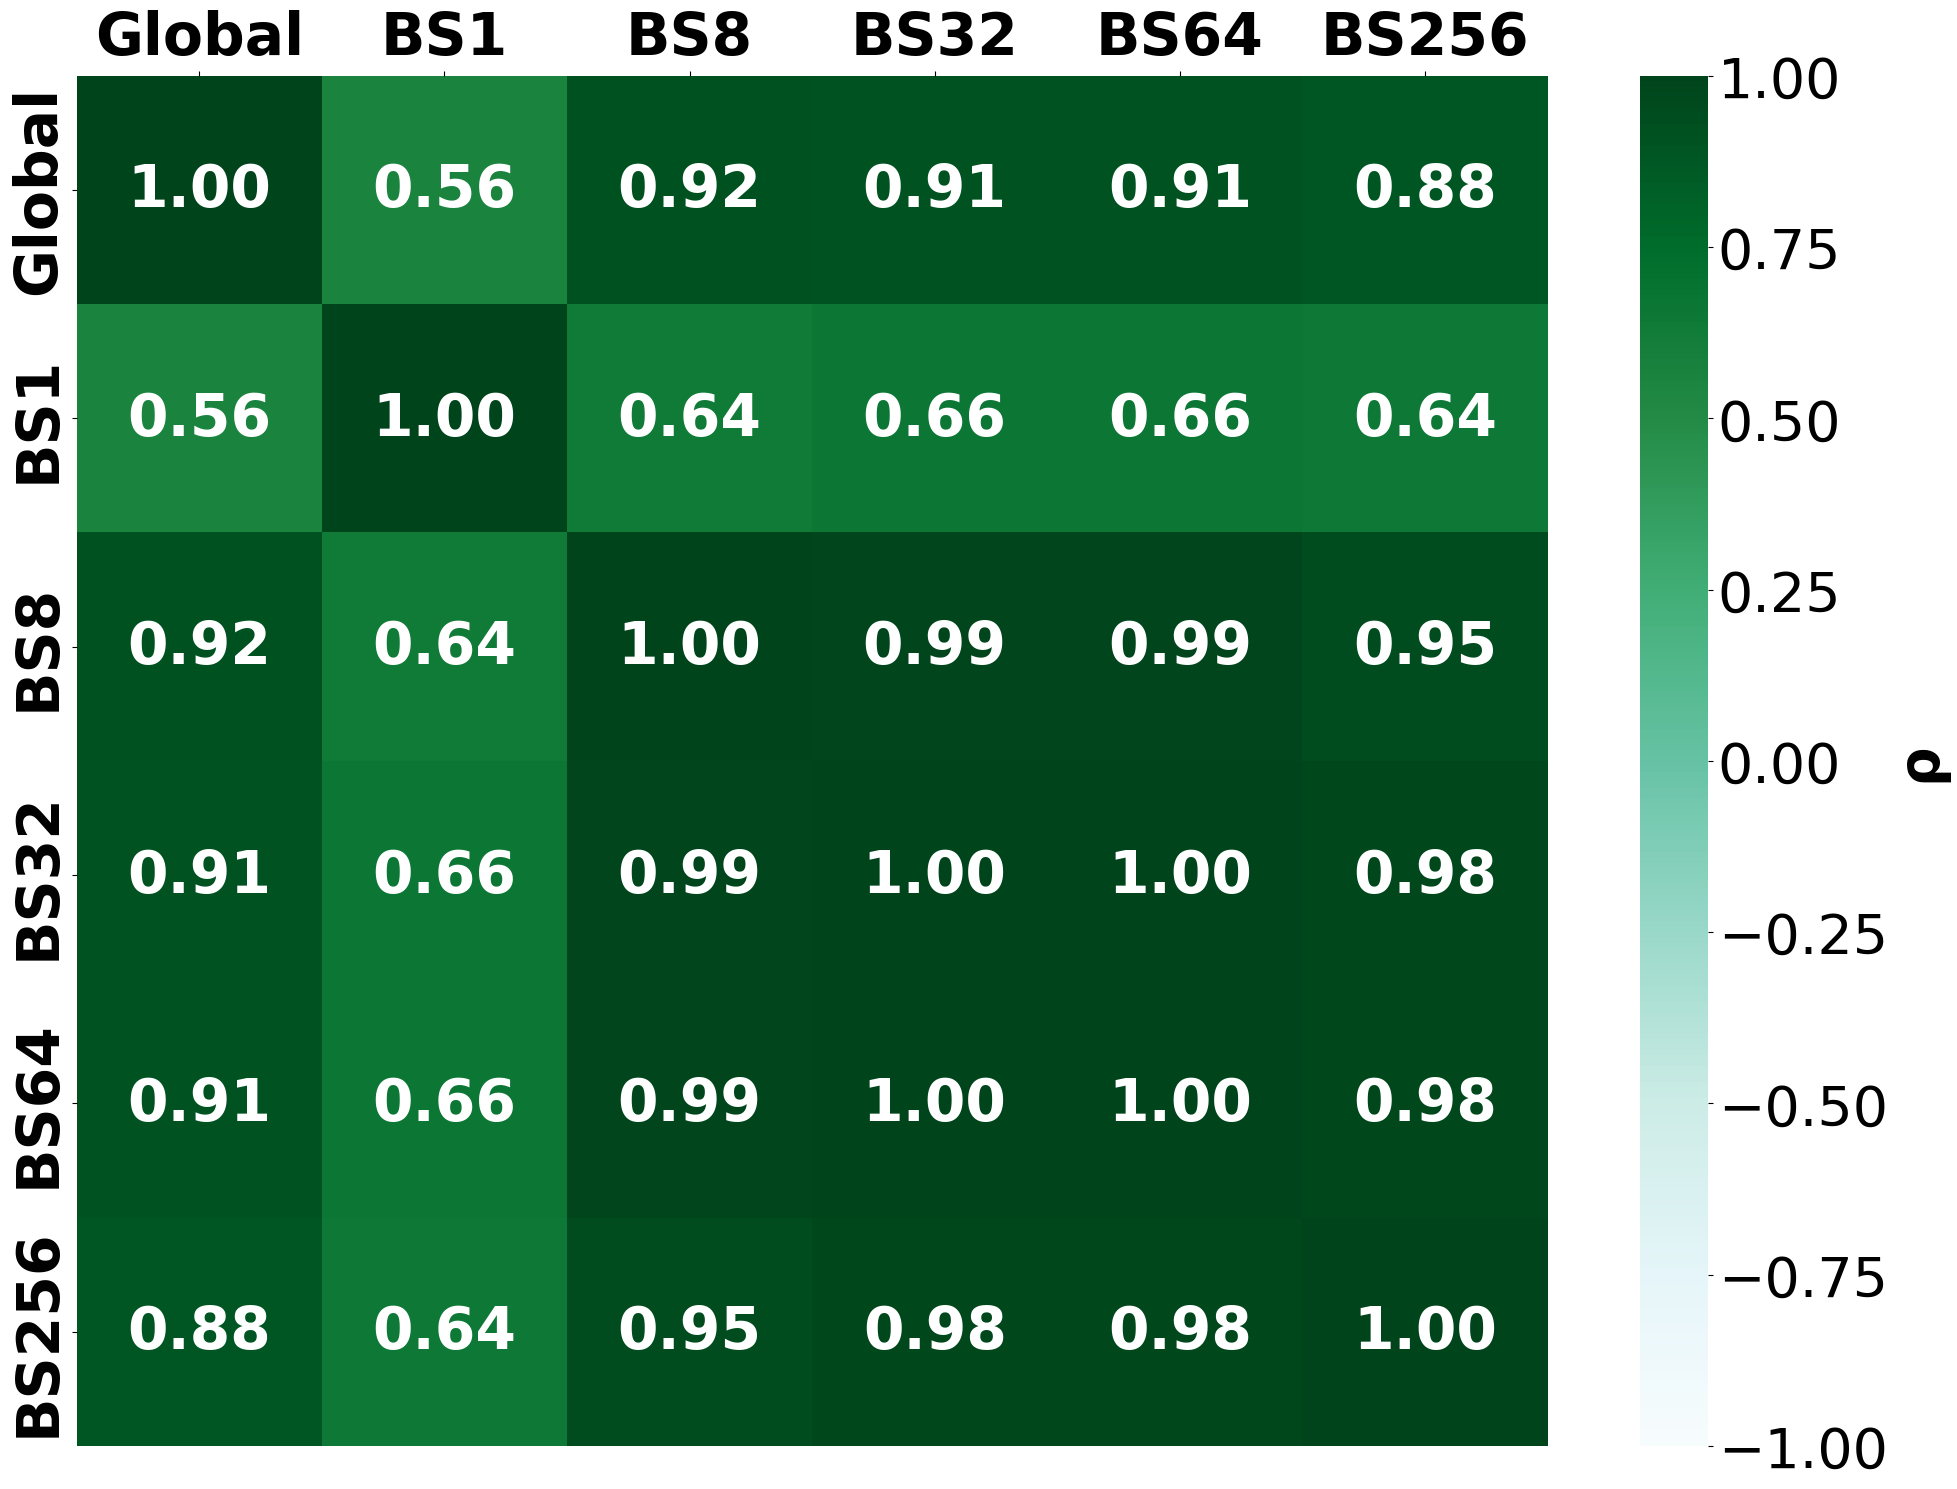

In [81]:
plot_corr_matrix(M, names=["Global", "BS1", "BS8", "BS32", "BS64", "BS256"], title="")

#### per attack's FI

In [132]:
embds_folder = "./extracted_embds"
exp_name = "ST_RB_AASIST_MTL_KANaux_trainingScratch"
exp_folder = os.path.join(embds_folder, exp_name)

eval_attackAttr_embeddings_file = "ASVspoof2019_attr17_eval_attackAttr_embeddings.npy"

In [133]:
eval_attackAttr_embeddings_path = os.path.join(exp_folder, eval_attackAttr_embeddings_file)

In [134]:
eval_attackAttr_embeddings = np.load(eval_attackAttr_embeddings_path)
eval_attackAttr_embeddings.shape

(47880, 50)

In [135]:
eval_protocols_path = './data/ASVspoof2019_attr17_cm_protocols/Eval_ASVspoof19_attr17.txt'
eval_attack_labels = load_attack_labels(eval_protocols_path)

In [136]:
eval_dataset = AttClsDataset(eval_attackAttr_embeddings, eval_attack_labels)

In [137]:
eval_loader = DataLoader(eval_dataset,
                             batch_size=len(eval_dataset),
                             shuffle=False,
                             drop_last=False,
                             pin_memory=True,
                             collate_fn=None)
print("Number of batches in eval loader: ", len(eval_loader))

Number of batches in eval loader:  1


In [138]:
pretrained_path = "./weights/best_ST_RB_AASIST_MTL_KANaux_trainingScratch.pt"
    
model = CMMTLKAN(
                backbone="AASIST",
                use_pretrained_backbone=False,
                freeze_backbone=False,
                device=device, 
                kan_auxiliary_structure=ASVSpoof2019_Attr17_attack_attribute_structure,
                seed=42
            ).to(device)
model.load_state_dict(torch.load(pretrained_path, map_location=device))
# model.kan_module.module_inFeatures(structure)

nb_params = sum([param.view(-1).size()[0] for param in model.parameters()])
print("no. model params:{}".format(nb_params))

Adding modular structure for KAN
no. model params:492444


In [139]:
kan_module = model.kan_module
# kan_module.module_inFeatures(structure)
kan_module.to(device)

MultKAN(
  (act_fun): ModuleList(
    (0): KANLayer(
      (base_fun): SiLU()
    )
  )
  (base_fun): SiLU()
)

In [141]:
global_perAtk_FI = get_fi_per_bs_by_attack(eval_loader, kan_module, device)
global_perAtk_FI.shape

  0%|          | 0/1 [00:00<?, ?it/s]

(17, 50)

In [91]:
FI_perAtk_bs1 = get_fi_per_bs_by_attack(eval_loader, kan_module, device)
FI_perAtk_bs1.shape

  0%|          | 0/47880 [00:00<?, ?it/s]

(17, 50)

In [101]:
FI_perAtk_bs8 = get_fi_per_bs_by_attack(eval_loader, kan_module, device)
FI_perAtk_bs8.shape

  0%|          | 0/5985 [00:00<?, ?it/s]

(17, 50)

In [111]:
FI_perAtk_bs32 = get_fi_per_bs_by_attack(eval_loader, kan_module, device)
FI_perAtk_bs32.shape

  0%|          | 0/1497 [00:00<?, ?it/s]

(17, 50)

In [121]:
FI_perAtk_bs64 = get_fi_per_bs_by_attack(eval_loader, kan_module, device)
FI_perAtk_bs64.shape

  0%|          | 0/749 [00:00<?, ?it/s]

(17, 50)

In [131]:
FI_perAtk_bs256 = get_fi_per_bs_by_attack(eval_loader, kan_module, device)
FI_perAtk_bs256.shape

  0%|          | 0/188 [00:00<?, ?it/s]

(17, 50)

In [142]:
list_runs = [global_perAtk_FI, FI_perAtk_bs1, FI_perAtk_bs8, FI_perAtk_bs32, FI_perAtk_bs64, FI_perAtk_bs256]

In [144]:
list_M = []
for i in range(17):
    list_M.append(get_rank_perAtk_multi_runs(attack=i, list_runs=list_runs))
list_M = np.array(list_M)
list_M.shape

(17, 6, 6)

In [149]:
def plot_corr_grid(M_list, titles=None, names=None, upper_only=True,
                   cmap="YlGn", annot=True, fmt=".2f"):
    
    k = len(M_list)
    N = M_list[0].shape[0]
    assert all(M.shape == (N, N) for M in M_list), "All matrices must be same size."

    if titles is None:
        titles = [f"A{i+1:02d}" for i in range(k)]
    if names is None:
        names = [str(i+1) for i in range(N)]

    # choose a compact grid
    cols = min(6, k)                    # up to 5 across; adjust if you prefer
    rows = math.ceil(k / cols)

    fig, axes = plt.subplots(rows, cols,
                             figsize=(cols*13, rows*13),
                             constrained_layout=True)
    axes = np.atleast_1d(axes).ravel()

    vmin, vmax = -1.0, 1.0
    norm = plt.Normalize(vmin=vmin, vmax=vmax)

    for ax, M, title in zip(axes, M_list, titles):
        df = pd.DataFrame(M, index=names, columns=names)
        mask = np.tril(np.ones_like(df, dtype=bool), k=-1) if upper_only else None
        sns.heatmap(df, ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
                    square=True, mask=mask, annot=annot, fmt=fmt,
                    cbar=False,
                    annot_kws={"size": 42, "weight": "bold"},)
        ax.set_title(title, pad=6, fontsize=50, fontweight='bold')
        ax.tick_params(top=True, bottom=False, labeltop=True, labelbottom=False, labelsize=42)

        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontweight('bold')

    # hide any unused axes
    for ax in axes[len(M_list):]:
        ax.axis("off")

    # one shared colorbar
    sm = ScalarMappable(norm=norm, cmap=cmap); sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes[:len(M_list)], fraction=0.03, pad=0.01)
    cbar.ax.tick_params(labelsize=42)
    cbar.set_label("ρ", fontsize=60, fontweight='bold')

    plt.show()

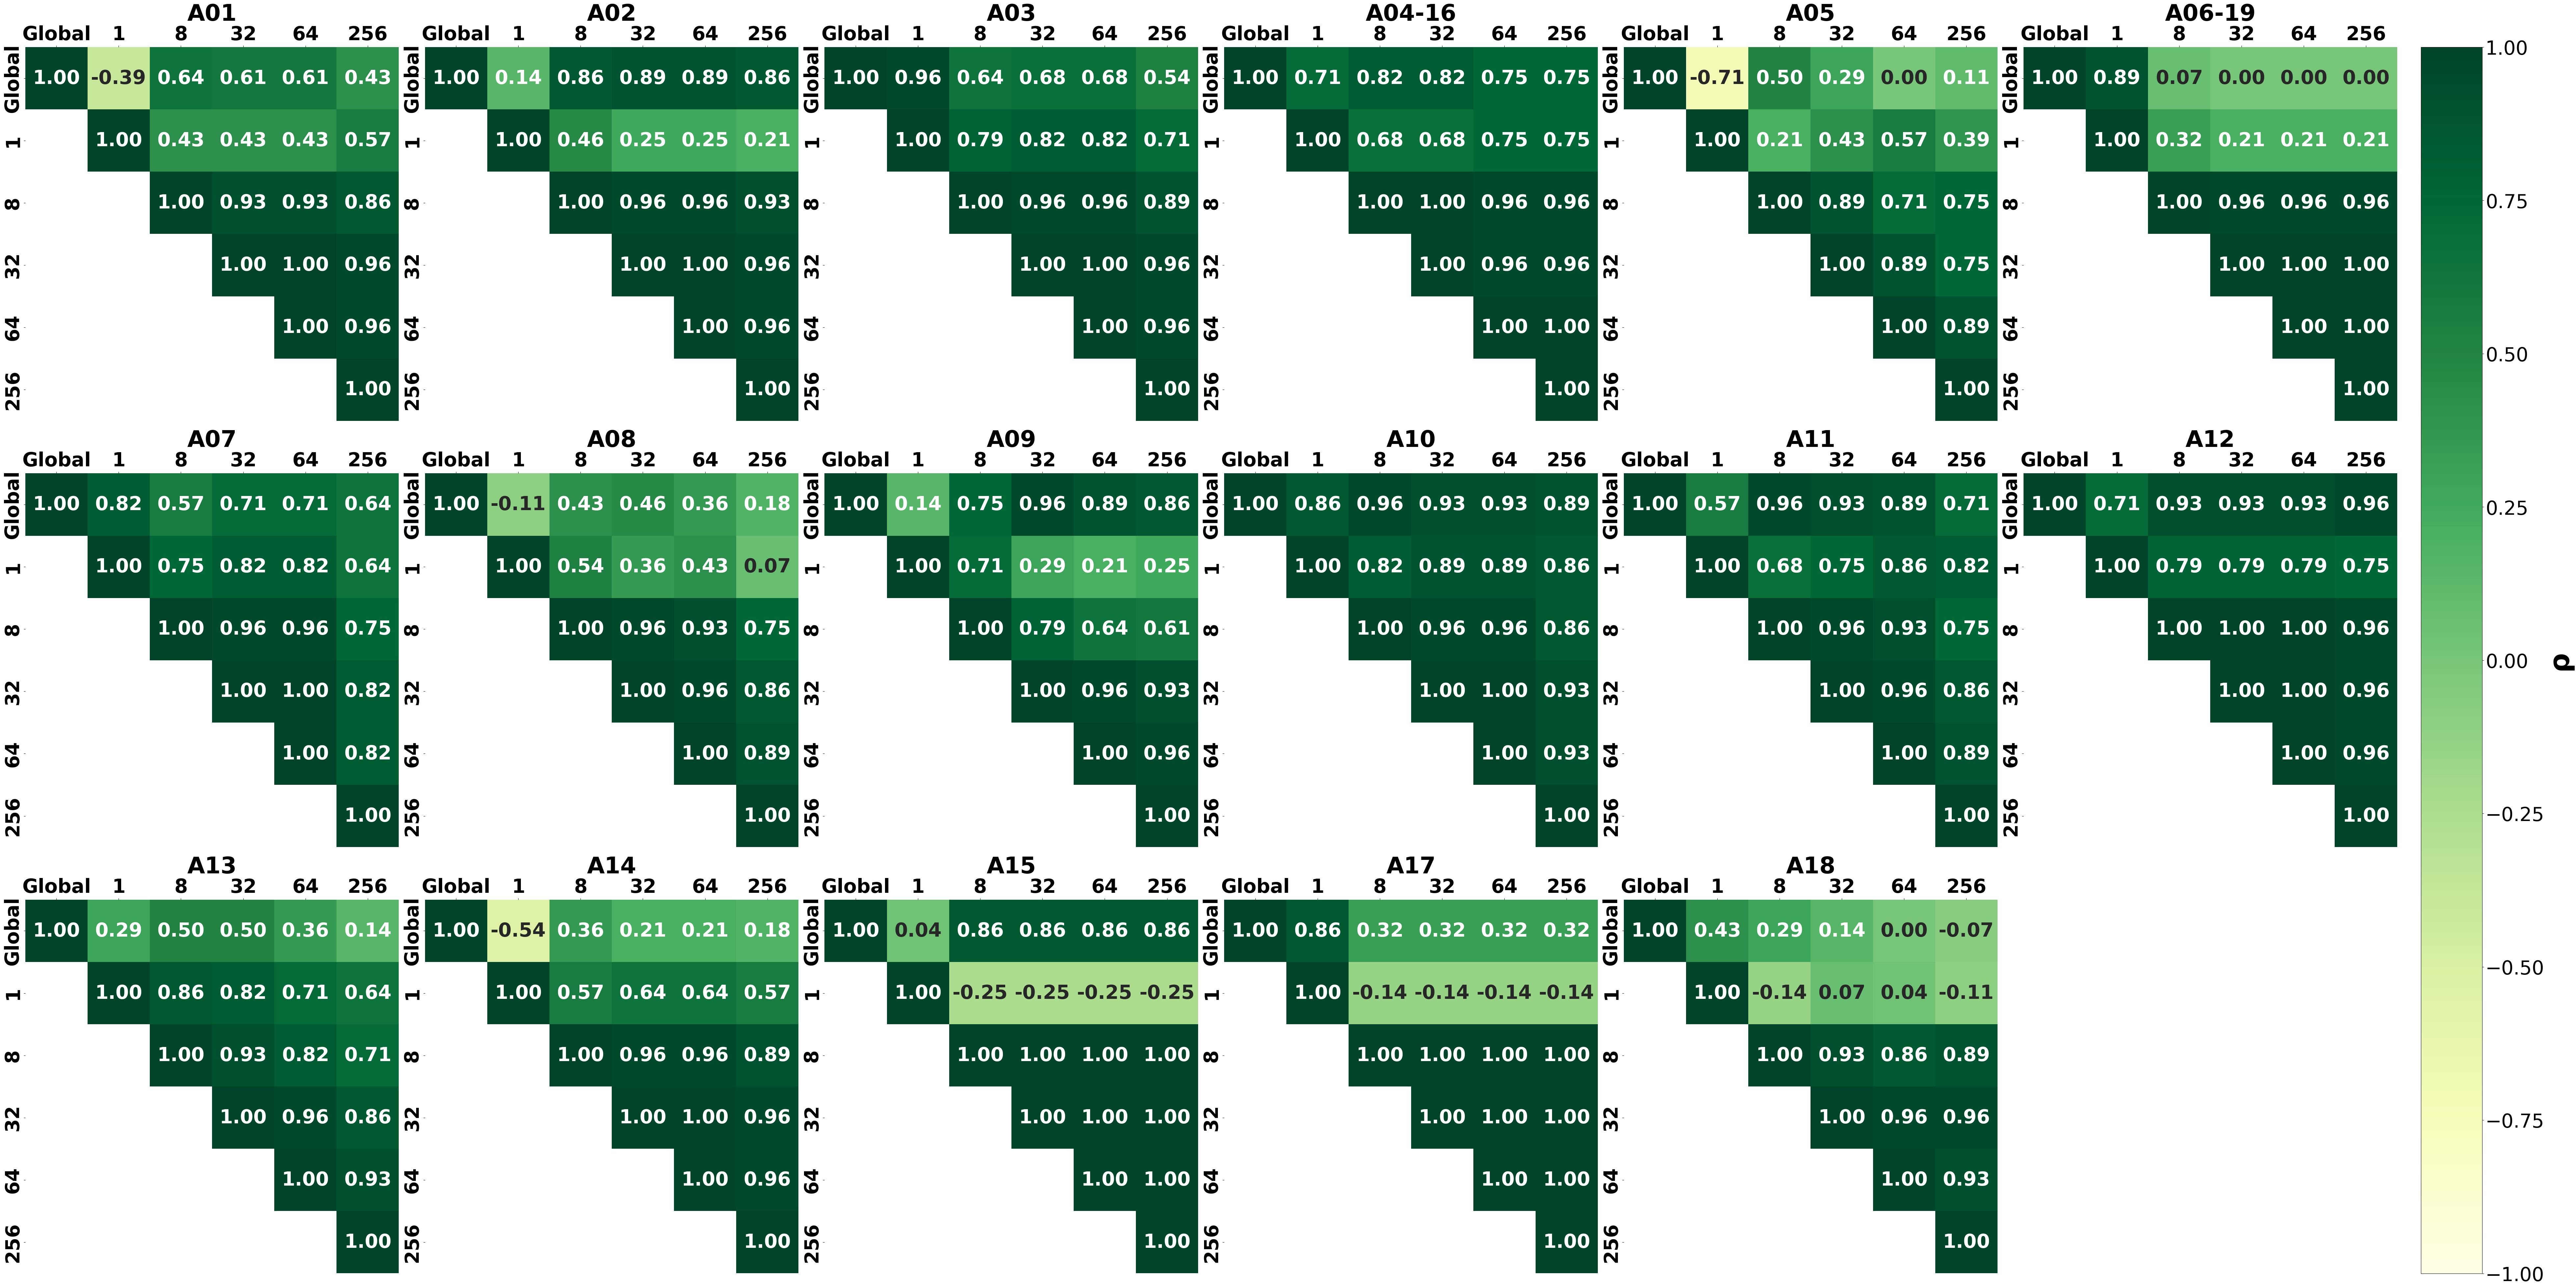

In [150]:
plot_corr_grid(list_M,
               titles=["A01", "A02", "A03", "A04-16", "A05", "A06-19", "A07", "A08", "A09", "A10", "A11", "A12", "A13", "A14", "A15", "A17", "A18"],
               names=["Global", "1", "8", "32", "64", "256"])

## **Criteria 3: Faithfulness**

In [2]:
%cd /scratch/project_2006687/hoangph/_thesis/ppm_v4/source_tracing

/scratch/project_2006687/hoangph/_thesis/ppm_v4/source_tracing


In [3]:
!ls

AttackAttr_embds  evaluate_deepfake_detection.py
AttackCls_embds   evaluate.py
backbones	  extracted_embds
config		  feature_extraction.py
core.1803143	  FI_utils.py
core.1804538	  get_shap_FIscores.py
core.1820090	  ID_OOD_distribution.png
core.1834255	  kan_figures
core.1834274	  kan_simplify
core.1842687	  logs
core.1853508	  model.py
core.1856550	  plots
core.1862306	  __pycache__
core.1862325	  RawBoost.py
core.1872401	  shap_values
core.1877436	  train.py
core.1878995	  train.sh
core.1886469	  TSNE_df_ID_OOD.png
core.1886491	  TSNE_features_visualization.py
core.2212903	  utils.py
data		  weights
data_utils.py


In [4]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from tqdm.auto import tqdm

import torch
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from data_utils import fetch_protocol, Dataset_ASVspoof2019_attr17, ASVSpoof2019_Attr17_attack_attribute_structure
from model import CMMTLKAN
from FI_utils import *

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import balanced_accuracy_score


#### **eval_phase function**

In [5]:
def plot_cfm(cm, class_names):
    # Normalize per row (percentage)
    cm_normalized = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis] * 100

    plt.figure(figsize=(32, 28))
    
    ax = sns.heatmap(
        cm_normalized,
        annot=True,
        fmt=".2f",
        cmap="BuPu",
        xticklabels=class_names,
        yticklabels=class_names,
        annot_kws={"size": 28, "weight": "bold"} 
    )

    # Axis labels
    ax.set_xlabel("Predicted Label", fontsize=40, fontweight="bold")
    ax.set_ylabel("True Label", fontsize=40, fontweight="bold")

    # Tick labels (class names)
    ax.tick_params(axis="x", labelsize=30)
    ax.tick_params(axis="y", labelsize=30)

    # Make tick labels bold
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontweight("bold")

    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=30)

    # Optional title
    # ax.set_title("Normalized Confusion Matrix (%)", fontsize=30, fontweight="bold")

    plt.tight_layout()
    plt.show()

In [6]:
in_vars=["Text (inputs)", "Speech_human (inputs)", "Speech_TTS (inputs)",
         "NLP (processor)", "WORLD (processor)", "LPCC/MFCC (processor)", "CNN+bi-RNN (processor)", "ASR (processor)", "MFCC/i-vector (processor)",
         "HMM (duration)", "FF (duration)", "RNN (duration)", "Attention (duration)", "DTW (duration)", "None (duration)", 
         "AR-RNN (conversion)", "FF (conversion)", "CART (conversion)", "VAE (conversion)", "GMM-UBM (conversion)", "RNN (conversion)", "AR-RNN+CNN (conversion)", "Moment-match (conversion)", "linear (conversion)",
         "VAE (speaker)", "one-hot (speaker)", "d-vector_RNN (speaker)", "PLDA (speaker)", "None (speaker)", 
         "MCC-F0 (outputs)", "MCC-F0-BAP (outputs)", "MFCC-F0 (outputs)", "MCC-F0-AP (outputs)", "LPC (outputs)", "MCC-F0-BA (outputs)", "mel-spec (outputs)", "F0+ling (outputs)", "MCC (outputs)", "MFCC (outputs)",
         "WaveNet (waveform)", "WORLD (waveform)", "Concat (waveform)", "SpecFiltOLA (waveform)", "NeuralFilt (waveform)", "Vocaine (waveform)", "WaveRNN (waveform)", "GriffinLim (waveform)", "WaveFilt (waveform)", "STRAIGHT (waveform)", "MFCCvoc (waveform)"
        ]
out_vars=['A01', 'A02', 'A03', 'A04-16', 'A05', 'A06-19', 'A07', 'A08', 'A09', 'A10', 'A11', 'A12', 'A13', 'A14', 'A15', 'A17', 'A18']

In [7]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


#### **Evaluating (Necessity + Sufficiency)**

In [53]:
structure = [
    ([0], [1, 3, 9, 11]),
    ([7], [14]),
    ([14], [3]),
    ([16], [2]),
    ([24], [0]),
    ([32], [4]),
    ([37], [12]),
    ([38], [16]),
    ([40], [6]),
    ([42], [5]),
    ([43], [7]),
    ([44], [8]),
    ([46], [10]),
    ([47], [15]),
    ([48], [13]),
]

In [54]:
embds_folder = "./extracted_embds"
exp_name = "ST_RB_AASIST_MTL_KANaux_trainingScratch"
exp_folder = os.path.join(embds_folder, exp_name)

eval_attackAttr_embeddings_file = "ASVspoof2019_attr17_eval_attackAttr_embeddings.npy"

In [55]:
eval_attackAttr_embeddings_path = os.path.join(exp_folder, eval_attackAttr_embeddings_file)

In [56]:
eval_attackAttr_embeddings = np.load(eval_attackAttr_embeddings_path)
eval_attackAttr_embeddings.shape

(47880, 50)

In [57]:
eval_protocols_path = './data/ASVspoof2019_attr17_cm_protocols/Eval_ASVspoof19_attr17.txt'

eval_attack_labels = load_attack_labels(eval_protocols_path)

The history saving thread hit an unexpected error (OperationalError('disk I/O error')).History will not be written to the database.


In [58]:
eval_dataset = AttClsDataset(eval_attackAttr_embeddings, eval_attack_labels)

In [59]:
eval_loader = DataLoader(eval_dataset,
                             batch_size=len(eval_dataset),
                             shuffle=False,
                             drop_last=False,
                             pin_memory=True,
                             collate_fn=None)
print("Number of batches in eval loader: ", len(eval_loader))

Number of batches in eval loader:  1


In [60]:
pretrained_path = "./weights/best_ST_RB_AASIST_MTL_KANaux_trainingScratch.pt"
    
model = CMMTLKAN(
                backbone="AASIST",
                use_pretrained_backbone=False,
                freeze_backbone=False,
                device=device, 
                kan_auxiliary_structure=ASVSpoof2019_Attr17_attack_attribute_structure,
                seed=42
            ).to(device)
model.load_state_dict(torch.load(pretrained_path, map_location=device))
# model.kan_module.module_inFeatures(structure)

nb_params = sum([param.view(-1).size()[0] for param in model.parameters()])
print("no. model params:{}".format(nb_params))

Adding modular structure for KAN
no. model params:492444


In [61]:
kan_module = model.kan_module
kan_module.module_inFeatures(structure)
kan_module.to(device)

Adding modular structure for KAN


MultKAN(
  (act_fun): ModuleList(
    (0): KANLayer(
      (base_fun): SiLU()
    )
  )
  (base_fun): SiLU()
)

In [62]:
eval_avg_acc, eval_avg_balanced_acc, attCls_cfsMatrix, attCls_clsReport = eval_AttackCls(eval_loader, kan_module, device)

  0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib64/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib64/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib64/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Evaluation Results:
Average Accuracy: 0.6992481203007519
Average Balanced Accuracy: 0.73290601580956

Attack Classification Confusion Matrix:


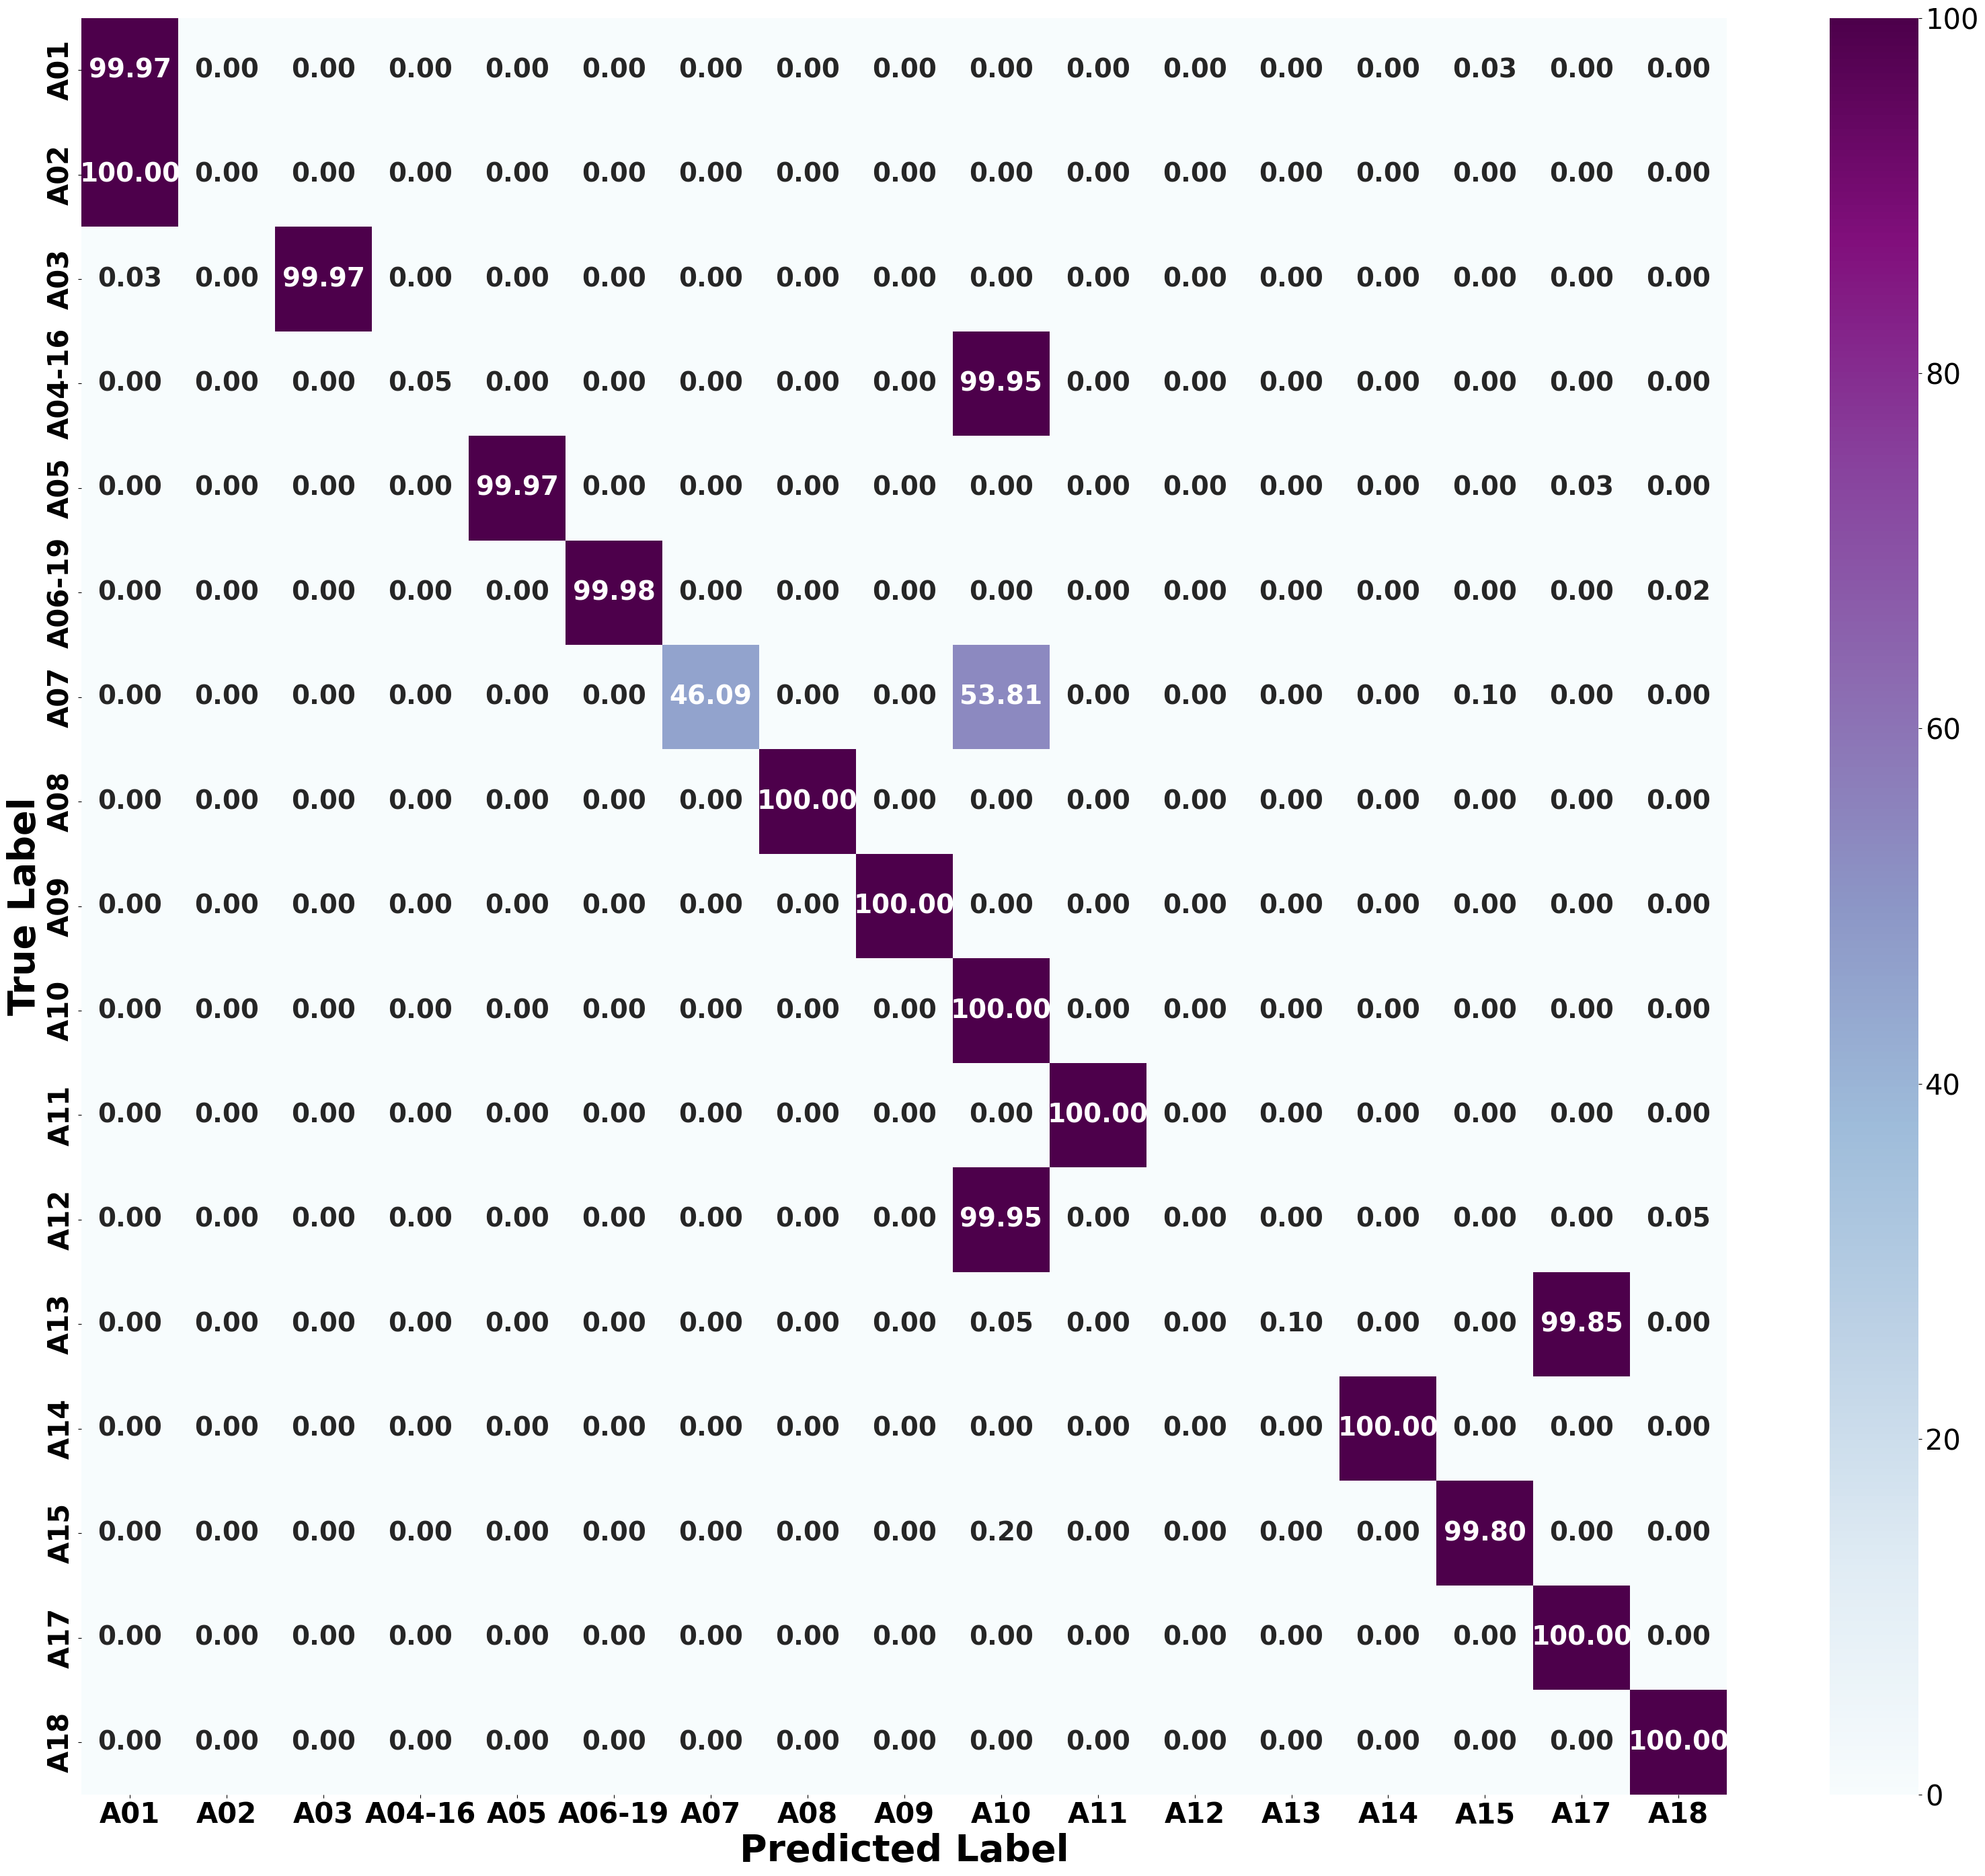


Attack Classification Report:
              precision    recall  f1-score   support

           0      0.500     1.000     0.666      3716
           1      0.000     0.000     0.000      3716
           2      1.000     1.000     1.000      3716
           3      1.000     0.001     0.001      5684
           4      1.000     1.000     1.000      3716
           5      1.000     1.000     1.000      5684
           6      1.000     0.461     0.631      1968
           7      1.000     1.000     1.000      1968
           8      1.000     1.000     1.000      1968
           9      0.184     1.000     0.311      1968
          10      1.000     1.000     1.000      1968
          11      0.000     0.000     0.000      1968
          12      1.000     0.001     0.002      1968
          13      1.000     1.000     1.000      1968
          14      0.998     0.998     0.998      1968
          15      0.500     1.000     0.667      1968
          16      0.999     1.000     0.999      1

In [63]:
print("\nEvaluation Results:")
print("Average Accuracy:", eval_avg_acc)
print("Average Balanced Accuracy:", eval_avg_balanced_acc)
print("\nAttack Classification Confusion Matrix:")
plot_cfm(attCls_cfsMatrix, out_vars)
print("\nAttack Classification Report:")
print(attCls_clsReport)

In [18]:
kan_module.cache_data.shape

torch.Size([47880, 50])

In [19]:
feature_scores = kan_module.feature_score
feature_scores

tensor([0.2056, 0.0341, 0.0425, 0.0362, 0.0223, 0.0103, 0.0208, 0.0351, 0.0116,
        0.0390, 0.0116, 0.0236, 0.0063, 0.0140, 0.0370, 0.0247, 0.0250, 0.0115,
        0.0292, 0.0123, 0.0513, 0.0118, 0.0136, 0.0117, 0.0485, 0.0438, 0.0086,
        0.0159, 0.0455, 0.0599, 0.0512, 0.0153, 0.0266, 0.0155, 0.0246, 0.0179,
        0.0160, 0.0176, 0.0174, 0.0495, 0.0563, 0.0156, 0.0160, 0.0342, 0.0300,
        0.0127, 0.0272, 0.0408, 0.0257, 0.0101], device='cuda:0',
       grad_fn=<MeanBackward1>)

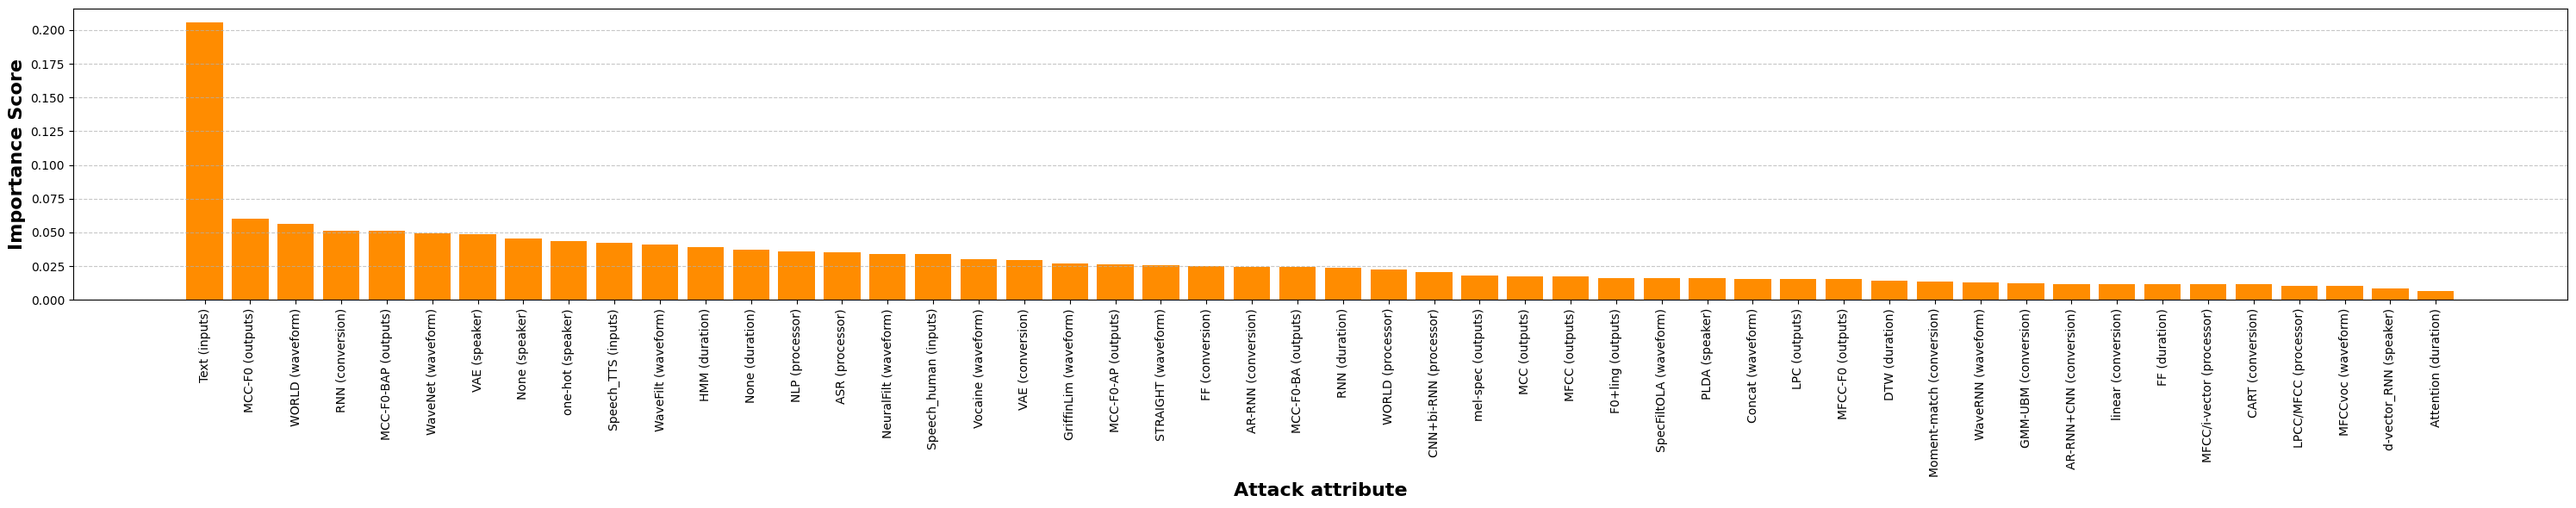

In [27]:
# Create a DataFrame for sorting
df = pd.DataFrame({'Feature': np.array(in_vars), 'Score': feature_scores.detach().cpu().numpy()})
df_sorted = df.sort_values(by='Score', ascending=False)

# Plot
plt.figure(figsize=(30, 6))
plt.bar(df_sorted['Feature'], df_sorted['Score'], color='darkorange')
plt.xticks(rotation=90)
plt.ylabel('Importance Score', fontsize=16, fontweight='bold')
plt.xlabel('Attack attribute', fontsize=16, fontweight='bold')
# plt.title('Feature Scores')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

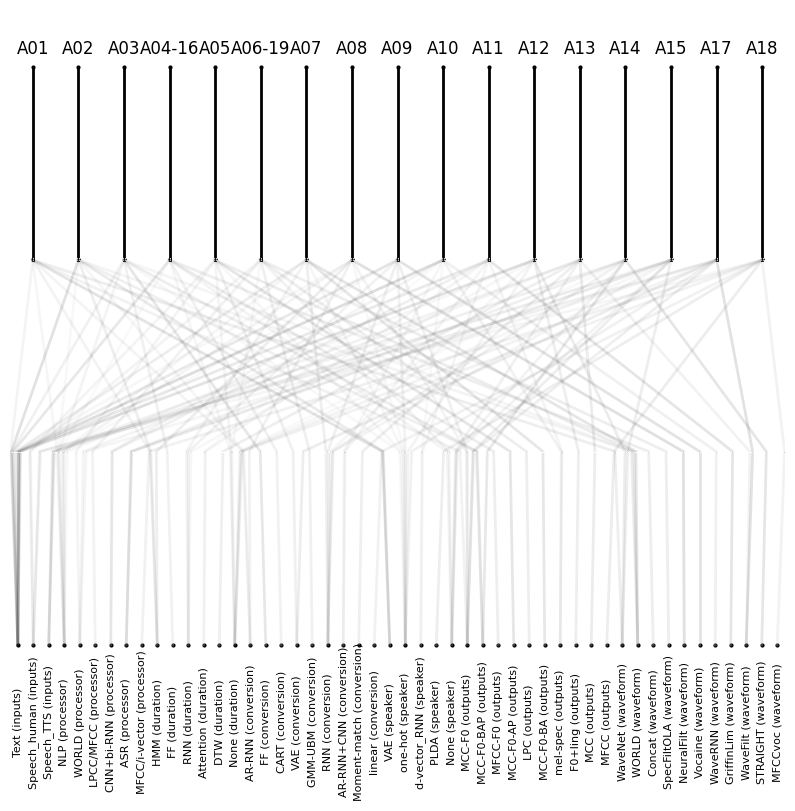

In [49]:
kan_module.plot(beta=3, scale=1, varscale=0.2, in_vars=in_vars, out_vars=out_vars)

In [28]:
def plot_inFeature_importance(kan_model, outNode_id):
    scores = kan_model.attribute(1, outNode_id)

    # Create a DataFrame for sorting
    df = pd.DataFrame({'Feature': np.array(in_vars), 'Score': scores.detach().cpu().numpy()})
    df_sorted = df.sort_values(by='Score', ascending=False)
    
    # Plot
    plt.figure(figsize=(30, 6))
    plt.bar(df_sorted['Feature'], df_sorted['Score'])
    plt.xticks(rotation=90)
    plt.ylabel('Feature Score')
    plt.title('Input feature importance for A0{}'.format(outNode_id+1))
    plt.tight_layout()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

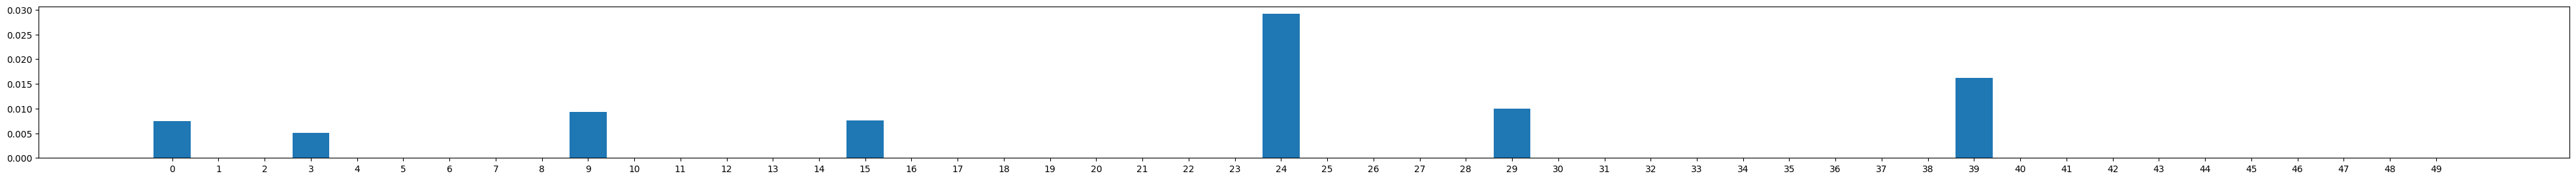

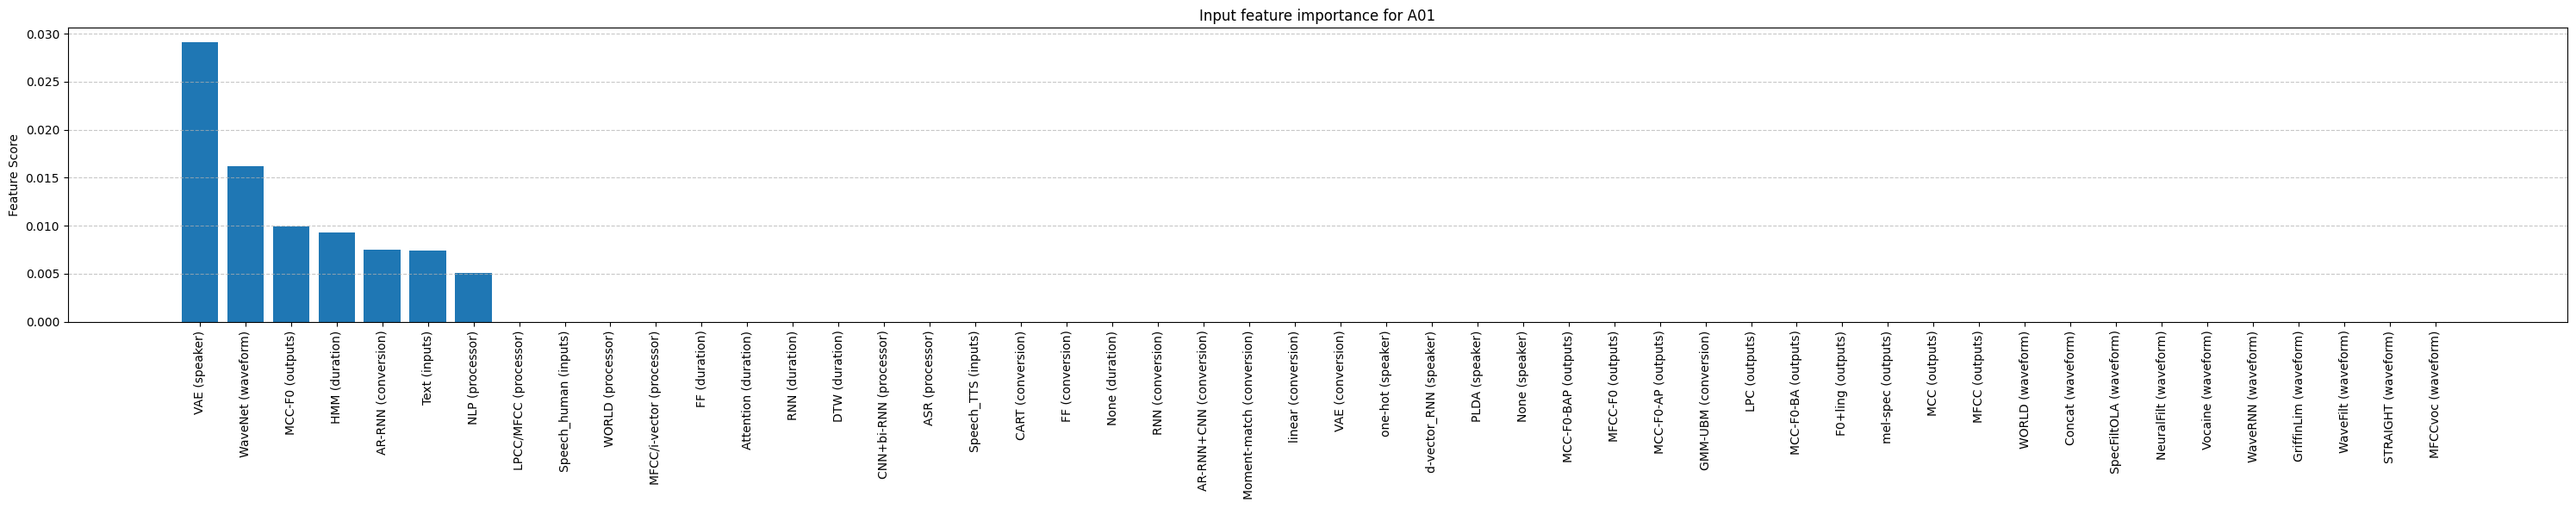

In [31]:
plot_inFeature_importance(kan_module, 0)

In [32]:
most_important_features = []
for i in range(len(out_vars)):
    scores = kan_module.attribute(1, i, plot=False)
    
    # Create a DataFrame for sorting
    df = pd.DataFrame({'Feature': np.array(in_vars), 'Score': scores.detach().cpu().numpy()})
    df_sorted = df.sort_values(by='Score', ascending=False)
    # print()
    # print()
    most_important_features.append(df_sorted['Feature'].values[:7])

df_attack_fi = pd.DataFrame(most_important_features, index=out_vars)

In [33]:
df_attack_fi

,0,1,2,3,4,5,6
A01,VAE (speaker),WaveNet (waveform),MCC-F0 (outputs),HMM (duration),AR-RNN (conversion),Text (inputs),NLP (processor)
A02,Text (inputs),VAE (speaker),HMM (duration),MCC-F0-BAP (outputs),WORLD (waveform),AR-RNN (conversion),NLP (processor)
A03,FF (conversion),MCC-F0-BAP (outputs),Text (inputs),FF (duration),NLP (processor),WORLD (waveform),one-hot (speaker)
A04-16,Text (inputs),Concat (waveform),MFCC-F0 (outputs),CART (conversion),None (speaker),None (duration),NLP (processor)
A05,MCC-F0-AP (outputs),WORLD (waveform),VAE (conversion),WORLD (processor),Speech_human (inputs),None (duration),one-hot (speaker)
A06-19,SpecFiltOLA (waveform),LPC (outputs),GMM-UBM (conversion),LPCC/MFCC (processor),None (speaker),Speech_human (inputs),None (duration)
A07,WORLD (waveform),MCC-F0-BA (outputs),Text (inputs),RNN (conversion),RNN (duration),NLP (processor),one-hot (speaker)
A08,NeuralFilt (waveform),HMM (duration),AR-RNN (conversion),NLP (processor),MCC-F0 (outputs),Text (inputs),one-hot (speaker)
A09,Vocaine (waveform),Text (inputs),MCC-F0 (outputs),RNN (conversion),one-hot (speaker),RNN (duration),NLP (processor)
A10,Text (inputs),WaveRNN (waveform),mel-spec (outputs),CNN+bi-RNN (processor),AR-RNN+CNN (conversion),d-vector_RNN (speaker),Attention (duration)
